# 01 · pNEUMA Data Preparation and Traffic Analysis
*Chuẩn bị dữ liệu và phân tích giao thông pNEUMA*

This project uses drone-recorded vehicle trajectories from Athens, Greece, to examine traffic patterns and evaluate short-term speed forecasting and low-speed warnings.

(Dự án sử dụng dữ liệu quỹ đạo phương tiện được drone ghi nhận tại Athens, Hy Lạp, để nghiên cứu đặc điểm giao thông và đánh giá khả năng dự báo tốc độ ngắn hạn, cảnh báo trạng thái tốc độ thấp.)

**Notebook 01 establishes the data foundation and answers RQ1:** how observed speed varies across locations and recording intervals, and how it relates to vehicle count and vehicle composition. The analysis combines SQL summaries, maps and supporting charts, with observation coverage reported alongside the findings.

(**Notebook 01 xây dựng nền tảng dữ liệu và trả lời RQ1:** tốc độ quan sát thay đổi theo vị trí và khoảng ghi hình như thế nào, đồng thời liên hệ ra sao với số lượng xe và thành phần xe. Phân tích kết hợp bảng tổng hợp SQL, bản đồ và biểu đồ hỗ trợ, kèm thông tin về độ phủ quan sát để diễn giải các phát hiện.)

The outputs are documented traffic data, evidence supporting the RQ1 answer, and verified features and prediction targets for Notebook 02. Notebook 02 uses this handover to compare five forecasting methods and conduct the extended experiments for RQ2 and RQ3.

(Đầu ra gồm dữ liệu giao thông có mô tả rõ ràng, bằng chứng trả lời RQ1, cùng đặc trưng và nhãn dự báo đã kiểm chứng để bàn giao sang Notebook 02. Notebook 02 sử dụng bộ dữ liệu này để so sánh năm phương pháp dự báo và thực hiện các thí nghiệm mở rộng cho RQ2, RQ3.)

## Contents (Mục lục)

1. [Research questions and study design — Câu hỏi và thiết kế nghiên cứu](#research)
2. [Study area and source data — Khu vực nghiên cứu và dữ liệu nguồn](#data)
3. [Data preparation and verification — Chuẩn bị và kiểm chứng dữ liệu](#preparation)
4. [Traffic analysis and RQ1 findings — Phân tích giao thông và kết quả RQ1](#rq1)
5. [Feature and target construction — Tạo đặc trưng và nhãn dự báo](#features)
6. [Verified handover to Notebook 02 — Bàn giao dữ liệu đã kiểm chứng sang Notebook 02](#handover)

<a id="research"></a>

## Part I · Research design
*Phần I · Thiết kế nghiên cứu*

### 1. Research problem and objective
*Bài toán và mục tiêu nghiên cứu*

**Research title:** Drone-based Traffic Monitoring with the pNEUMA Trajectory Data for Short-term Speed and Congestion-onset Prediction in Intelligent Transportation Systems.

(**Tên đề tài:** Giám sát giao thông bằng drone với dữ liệu quỹ đạo pNEUMA để dự báo tốc độ ngắn hạn và khởi phát ùn tắc trong hệ thống giao thông thông minh.)

A traffic description shows where and when vehicles move slowly. A forecasting study asks whether recent observations can anticipate those conditions. This project connects these two questions: it first characterises observed traffic, then evaluates whether historical speed, vehicle count and vehicle composition provide useful predictive information.

(Mô tả giao thông cho biết phương tiện di chuyển chậm ở đâu và khi nào. Nghiên cứu dự báo xem xét liệu những quan sát gần đây có giúp nhận biết trước tình trạng đó hay không. Dự án kết nối hai vấn đề này: trước hết phân tích đặc điểm giao thông quan sát được, sau đó đánh giá giá trị dự báo của tốc độ lịch sử, số lượng xe và thành phần xe.)

**The objective is to establish how accurately traffic conditions can be predicted from the selected pNEUMA recordings, what vehicle composition contributes, and how performance changes at locations excluded from training.**

(**Mục tiêu là xác định mức độ chính xác khi dự báo tình trạng giao thông từ các recording pNEUMA được chọn, đóng góp của thành phần xe và sự thay đổi hiệu quả tại các vị trí không dùng để huấn luyện.**)

The study uses existing trajectories and evaluates predictions offline. In the warning task, “congestion onset” is represented by the appearance of a low-speed interval under a specified rule. This indicator does not independently identify the cause of slow traffic or confirm a sustained queue.

(Nghiên cứu sử dụng quỹ đạo có sẵn và đánh giá dự báo trên dữ liệu đã ghi nhận. Trong bài toán cảnh báo, “khởi phát ùn tắc” được biểu diễn bằng sự xuất hiện của một khoảng tốc độ thấp theo quy tắc xác định. Chỉ báo này chưa tự xác định nguyên nhân giao thông chậm hoặc xác nhận hàng chờ kéo dài.)

<a id="data"></a>

## Part II · Study area and source data
*Khu vực nghiên cứu và dữ liệu nguồn*

### 1. Study area and recording scope
*Khu vực và phạm vi ghi hình*

The study uses pNEUMA vehicle trajectories recorded in Athens, Greece. The selected collection contains **199 CSV files** from drones **d1–d10**, covering four recording dates.

(Nghiên cứu sử dụng quỹ đạo phương tiện pNEUMA được ghi nhận tại Athens, Hy Lạp. Bộ dữ liệu được chọn gồm **199 file CSV** của các drone **d1–d10**, thuộc bốn ngày ghi hình.)

| Recording date / Ngày ghi hình | Collected CSV files / Số file đã thu thập |
|---|---:|
| 24 October 2018 / 24-10-2018 | 50 |
| 29 October 2018 / 29-10-2018 | 50 |
| 30 October 2018 / 30-10-2018 | 49 |
| 1 November 2018 / 01-11-2018 | 50 |
| **Total / Tổng** | **199** |

The file `20181030_d2_0930_1000.csv` is absent from the collection. Its reported download response was “Empty set”; the cause has not been independently verified. The inventory step checks the collected files against this documented scope.

(File `20181030_d2_0930_1000.csv` còn thiếu trong bộ dữ liệu. Phản hồi được ghi nhận khi tải là “Empty set”; nguyên nhân chưa được xác minh độc lập. Bước kiểm kê sẽ đối chiếu các file thực tế với phạm vi đã ghi nhận này.)

For example, `20181024_d1_0830_0900.csv` identifies the recording date, drone and named recording window: **24 October 2018, drone d1, 08:30–09:00**. Actual observation coverage is checked from the timestamps inside each file.

(Ví dụ, `20181024_d1_0830_0900.csv` cho biết ngày ghi hình, drone và khung giờ ghi trong tên file: **24/10/2018, drone d1, 08:30–09:00**. Phạm vi thời gian thực sự có quan sát được kiểm tra từ dữ liệu bên trong mỗi file.)

### 2. Reading a trajectory CSV
*Cách đọc một file CSV quỹ đạo*

**Each data row describes one vehicle trajectory.** The first four fields describe that trajectory; the remaining values repeat in groups of six, recording the vehicle at successive observation times.

(**Mỗi hàng dữ liệu mô tả một quỹ đạo phương tiện.** Bốn trường đầu mô tả quỹ đạo đó; các giá trị còn lại lặp theo nhóm sáu trường, ghi nhận phương tiện tại những thời điểm liên tiếp.)

| Field / Trường | Meaning / Ý nghĩa |
|---|---|
| `track_id` | Trajectory identifier within a recording / Mã quỹ đạo trong một lần ghi hình |
| `type` | Vehicle type, such as car, motorcycle or bus / Loại phương tiện, chẳng hạn ô tô, xe máy hoặc xe buýt |
| `traveled_d` | Distance travelled along the recorded trajectory / Quãng đường di chuyển trên quỹ đạo được ghi nhận |
| `avg_speed` | Average speed over the recorded trajectory / Tốc độ trung bình trên quỹ đạo được ghi nhận |
| `lat`, `lon` | Latitude and longitude at an observation time / Vĩ độ và kinh độ tại thời điểm quan sát |
| `speed` | Speed at that observation time / Tốc độ tại thời điểm quan sát |
| `lon_acc`, `lat_acc` | Longitudinal and lateral acceleration / Gia tốc dọc và gia tốc ngang |
| `time` | Observation time relative to the recording / Thời gian quan sát tính tương đối trong lần ghi hình |

```text
Trajectory information / Thông tin quỹ đạo
track_id; type; traveled_d; avg_speed
    │
    ├── Observation 1 / Quan sát 1: lat; lon; speed; lon_acc; lat_acc; time
    ├── Observation 2 / Quan sát 2: lat; lon; speed; lon_acc; lat_acc; time
    └── ... further observations on the same CSV row
            các quan sát tiếp theo trên cùng hàng CSV
```

The diagram separates the repeated groups for readability; in the source file, they extend horizontally along the same row. A long row therefore contains many observations of one vehicle, rather than many different feature types. Different trajectories can contain different numbers of observations.

(Sơ đồ tách các nhóm lặp để dễ đọc; trong file nguồn, chúng nối tiếp theo chiều ngang trên cùng một hàng. Vì vậy, hàng dài chứa nhiều lần quan sát một xe, không phải nhiều loại đặc trưng khác nhau. Các quỹ đạo có thể có số lần quan sát khác nhau.)

A trajectory is identified using both its recording and `track_id`, because the same identifier may occur in different recording files.

(Một quỹ đạo được xác định bằng cả mã recording và `track_id`, vì cùng một mã có thể xuất hiện trong các file ghi hình khác nhau.)

### 3. Fields used in this study
*Các trường được sử dụng trong nghiên cứu*

The processing pipeline retains the recording identifier, `track_id`, `type`, `lat`, `lon`, `speed` and `time`. These fields support spatial and temporal aggregation, distinct vehicle counts, vehicle-composition summaries and historical forecasting features.

(Quy trình xử lý giữ mã recording, `track_id`, `type`, `lat`, `lon`, `speed` và `time`. Các trường này phục vụ tổng hợp theo không gian, thời gian, đếm phương tiện phân biệt, tính thành phần xe và tạo đặc trưng lịch sử để dự báo.)

Whole-trajectory summaries (`traveled_d`, `avg_speed`) are not used as forecasting inputs because their final values may depend on movement after the prediction time. Acceleration fields are outside the selected feature set.

(Các thống kê toàn quỹ đạo `traveled_d`, `avg_speed` không được dùng làm đầu vào dự báo vì giá trị cuối cùng có thể phụ thuộc vào chuyển động sau thời điểm dự báo. Các trường gia tốc nằm ngoài bộ đặc trưng được chọn.)

Vehicle count and composition are derived from the same trajectory source. They are additional variables, not an independent external dataset.

(Số xe và thành phần xe được tính từ cùng nguồn quỹ đạo. Đây là các biến bổ sung, không phải một bộ dữ liệu bên ngoài độc lập.)

<a id="preparation"></a>

## Part III · Data preparation and verification
*Chuẩn bị và kiểm chứng dữ liệu*

### 1. Environment setup (Thiết lập môi trường)

This step prepares the Python libraries used in Notebook 01. Run the installation cell in the same Python environment as the notebook.

(Bước này chuẩn bị các thư viện Python dùng trong Notebook 01. Ô cài đặt cần chạy trong cùng môi trường Python với notebook.)

| Library / Thư viện | Purpose / Công dụng |
|---|---|
| NumPy, pandas | Numerical calculations and data tables / Tính toán và xử lý dữ liệu dạng bảng |
| PyArrow | Batch processing and Parquet storage / Xử lý theo lô và lưu dữ liệu Parquet |
| DuckDB | SQL filtering, aggregation and temporal joins / Lọc, tổng hợp và ghép thời gian bằng SQL |
| Matplotlib, Seaborn | Charts and static spatial plots / Biểu đồ và hình không gian tĩnh |
| SciPy | Exploratory statistical analysis / Phân tích thống kê khám phá |
| pyproj | Coordinate transformations for the 100 m grid / Chuyển đổi tọa độ để tạo lưới 100 m |
| IPython | Displaying tables and formatted results / Hiển thị bảng và kết quả có định dạng |

The following cell detects missing packages and installs them through the Python interpreter running this notebook. Downloads require internet access. Existing packages are not explicitly upgraded, although dependency installation may change the environment.

(Ô code tiếp theo phát hiện thư viện còn thiếu và cài bằng chính trình thông dịch Python đang chạy notebook. Việc tải thư viện cần Internet. Các thư viện đã có không được yêu cầu nâng cấp trực tiếp, nhưng quá trình cài thư viện phụ thuộc có thể thay đổi môi trường.)

**Expected output:** the active Python version and executable, the packages requiring installation, and the final package-detection status. If installation fails, resolve the reported error before continuing.

(**Đầu ra cần thấy:** phiên bản và đường dẫn Python đang chạy, các thư viện cần cài và trạng thái kiểm tra sau cùng. Nếu cài đặt thất bại, cần xử lý lỗi trước khi tiếp tục.)

Package detection confirms availability only. Actual imports and version recording are checked in the subsequent setup cells.

(Việc phát hiện thư viện chỉ xác nhận sự hiện diện. Khả năng nhập thư viện thực tế và phiên bản sử dụng được kiểm tra, ghi nhận ở các ô thiết lập tiếp theo.)

In [ ]:
# Prepare dependencies for Notebook 01.
# Chuẩn bị toàn bộ thư viện, bao gồm nền bản đồ.

import importlib
import importlib.util
import inspect
import subprocess
import sys

DEPENDENCIES_READY = False

packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "duckdb": "duckdb",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "pyproj": "pyproj",
    "IPython": "ipython",
    "contextily": "contextily",
}

missing_packages = [
    package
    for module, package in packages.items()
    if importlib.util.find_spec(module) is None
]

if missing_packages:
    print("Đang cài thư viện còn thiếu:", ", ".join(missing_packages))
    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install",
            "--quiet", *missing_packages,
        ])
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "Cài thư viện chưa thành công. "
            "Kiểm tra thông báo phía trên và kết nối mạng, "
            "sau đó chạy lại chính ô này."
        ) from exc

    importlib.invalidate_caches()

# Import thật để phát hiện lỗi môi trường ngay tại bước thiết lập.
import_errors = {}

for module in packages:
    try:
        importlib.import_module(module)
    except Exception as exc:
        import_errors[module] = f"{type(exc).__name__}: {exc}"

if import_errors:
    details = "\n".join(
        f"- {name}: {message}"
        for name, message in import_errors.items()
    )
    raise RuntimeError(
        "Một số thư viện chưa sử dụng được:\n"
        f"{details}\n"
        "Nếu vừa thay đổi phiên bản thư viện trong phiên đang chạy, "
        "hãy khởi động lại phiên và chạy lại ô thiết lập."
    )

import contextily as ctx

# Bản đồ cần giới hạn thời gian chờ tải nền.
# Chỉ nâng cấp contextily nếu phiên bản hiện có thiếu chức năng này.
if "timeout" not in inspect.signature(ctx.bounds2img).parameters:
    print("Đang cập nhật thư viện nền bản đồ.")
    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install",
            "--quiet", "--upgrade", "contextily",
        ])
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "Chưa cập nhật được contextily. "
            "Kiểm tra kết nối mạng và chạy lại ô thiết lập."
        ) from exc

    importlib.invalidate_caches()
    import contextily.tile as contextily_tile
    importlib.reload(contextily_tile)
    ctx = importlib.reload(ctx)

if "timeout" not in inspect.signature(ctx.bounds2img).parameters:
    raise RuntimeError(
        "Phiên bản contextily hiện tại chưa hỗ trợ timeout. "
        "Khởi động lại phiên và chạy lại ô thiết lập "
        "để nạp phiên bản vừa cài."
    )

DEPENDENCIES_READY = True

print("ENVIRONMENT READY / MÔI TRƯỜNG SẴN SÀNG")
print("Python:", sys.version.split()[0])
print(f"Đã kiểm tra {len(packages)} thư viện.")
print("Thư viện nền bản đồ: sẵn sàng.")

Đang cài thư viện còn thiếu: contextily
ENVIRONMENT READY / MÔI TRƯỜNG SẴN SÀNG
Python: 3.13.15
Đã kiểm tra 10 thư viện.
Thư viện nền bản đồ: sẵn sàng.


### 2. Project configuration (Cấu hình dự án)

The following cell sets the project paths, experiment identifier and processing parameters. On Google Colab, it connects Google Drive; locally, it uses a project folder under the current user's home directory.

(Ô code tiếp theo thiết lập đường dẫn dự án, mã thí nghiệm và các tham số xử lý. Trên Google Colab, code kết nối Google Drive; khi chạy cục bộ, code sử dụng thư mục dự án bên trong thư mục cá nhân của người dùng.)

#### Settings to review (Các thiết lập cần kiểm tra)

| Setting / Thiết lập | Meaning and use / Ý nghĩa và cách dùng |
|---|---|
| `PROJECT_ROOT_OVERRIDE` | Leave empty to use the default location, or enter an absolute project path / Để trống để dùng vị trí mặc định, hoặc nhập đường dẫn tuyệt đối đến dự án |
| `PROJECT_ROOT` | Resolved project location / Vị trí dự án sau khi xác định đường dẫn |
| `RUN_ID` | Identifies the experiment outputs; currently `pneuma_4days_100m_v1` / Mã xác định đầu ra thí nghiệm; hiện dùng `pneuma_4days_100m_v1` |
| `NOTEBOOK_ID` | `01` for this notebook; `02` for the modelling notebook / `01` cho notebook này; `02` cho notebook mô hình |

**Both notebooks must use the same project root and `RUN_ID`.** These settings determine which prepared dataset Notebook 02 receives.

(**Hai notebook phải dùng cùng thư mục dự án và `RUN_ID`.** Các thiết lập này xác định bộ dữ liệu đã chuẩn bị mà Notebook 02 sẽ nhận.)

#### Data and output locations (Vị trí dữ liệu và đầu ra)

```text
PROJECT_ROOT/
├── data/raw/pneuma/          Source CSV files / Các file CSV nguồn
└── runs/
    └── RUN_ID/
        ├── data/processed/  Processed data / Dữ liệu đã xử lý
        ├── report/          Tables, figures and checks / Bảng, hình và kiểm tra
        ├── sql/             Saved SQL queries / Các truy vấn SQL
        ├── models/          Model outputs from Notebook 02 / Mô hình từ Notebook 02
        └── project_config.json
```

Missing folders are created automatically. Raw CSV files must be supplied separately. Reusing a `RUN_ID` reuses its output locations; subsequent cells may update reports and figures. Use a new `RUN_ID` when preserving a separate experiment.

(Các thư mục chưa có được tạo tự động. File CSV nguồn cần được cung cấp riêng. Dùng lại `RUN_ID` sẽ dùng lại vị trí đầu ra; các ô sau có thể cập nhật báo cáo và hình. Dùng `RUN_ID` mới khi cần lưu riêng một thí nghiệm.)

#### Processing parameters (Tham số xử lý)

The configuration records the selected dates and expected file counts, the projected 100 m grid and its fixed origin, 10-second intervals, forecast offsets, filtering thresholds and processing resource limits. These settings are saved in `project_config.json` and checked before reusing an existing experiment directory.

(Cấu hình ghi nhận các ngày được chọn và số file dự kiến, lưới 100 m trong hệ tọa độ phẳng cùng gốc lưới cố định, khoảng 10 giây, độ dịch dự báo, ngưỡng lọc và giới hạn tài nguyên xử lý. Các thiết lập được lưu trong `project_config.json` và đối chiếu trước khi dùng lại thư mục thí nghiệm đã có.)

**Expected output:** the detected environment, resolved project and raw-data paths, `RUN_ID`, key processing settings and the saved configuration path. Check these locations before proceeding to source inventory.

(**Đầu ra cần thấy:** môi trường được nhận diện, đường dẫn dự án và dữ liệu thô, `RUN_ID`, các thiết lập xử lý chính và đường dẫn file cấu hình đã lưu. Kiểm tra các vị trí này trước khi chuyển sang kiểm kê nguồn.)

In [ ]:
# Project configuration (Cấu hình dự án)

from pathlib import Path
import hashlib
import importlib.util
import importlib.metadata
import json
import os
import platform
import re
import tempfile

from pyproj import CRS, Transformer

NOTEBOOK_ID = "01"

# Fixed name: repeated runs reuse the same output directory.
RUN_ID = "pneuma_4days_100m_v1"

# Optional absolute path for a different project location.
PROJECT_ROOT_OVERRIDE = ""

# 1. Detect environment and resolve project location
try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except (ModuleNotFoundError, ValueError):
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    default_root = Path(
        "/content/drive/MyDrive/PNEUMA_Nhom9_Research"
    )
else:
    default_root = (
        Path.home() / "Documents" / "PNEUMA_Nhom9_Research"
    )

if PROJECT_ROOT_OVERRIDE.strip():
    PROJECT_ROOT = Path(
        PROJECT_ROOT_OVERRIDE.strip()
    ).expanduser()

    if not PROJECT_ROOT.is_absolute():
        raise ValueError(
            "PROJECT_ROOT_OVERRIDE must be an absolute path."
        )
else:
    PROJECT_ROOT = default_root

PROJECT_ROOT = PROJECT_ROOT.resolve()

if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_-]{0,79}", RUN_ID):
    raise ValueError(
        "RUN_ID must contain 1–80 characters: letters, digits, "
        "underscores or hyphens, starting with a letter or digit."
    )

reserved_names = {
    "CON", "PRN", "AUX", "NUL",
    *{f"COM{i}" for i in range(1, 10)},
    *{f"LPT{i}" for i in range(1, 10)},
}
if RUN_ID.upper() in reserved_names:
    raise ValueError("RUN_ID is a reserved Windows name.")

# 2. Directories
# RAW_DIR is unchanged: no need to upload the CSVs again.
PROJECT_DIR = PROJECT_ROOT / "runs" / RUN_ID
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "pneuma"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REPORT_DIR = PROJECT_DIR / "report"
SQL_DIR = PROJECT_DIR / "sql"
MODEL_DIR = PROJECT_DIR / "models"

# 3. Source scope
DATE_FILTER = [
    "20181024",
    "20181029",
    "20181030",
    "20181101",
]

EXPECTED_FILES_BY_DATE = {
    "20181024": 50,
    "20181029": 50,
    "20181030": 49,
    "20181101": 50,
}
EXPECTED_RAW_FILES = sum(EXPECTED_FILES_BY_DATE.values())

KNOWN_UNAVAILABLE_FILES = {
    "20181030_d2_0930_1000.csv": (
        "Not present in collected data. User reported that the "
        "official download returned 'Empty set'; "
        "cause not independently verified."
    )
}

DATA_MODE = "rebuild_raw"

# 4. Modelling settings
SEED = 42
MODEL_SEEDS = [0, 1, 2, 3, 4]
TEST_FLIGHT_FRACTION = 0.20

FORECAST_HORIZONS = [30, 60]
TARGET_COLS = {
    30: "y_30s",
    60: "y_60s",
}
PRIMARY_HORIZON = 60
TARGET_COL = TARGET_COLS[PRIMARY_HORIZON]

# 5. Spatial and temporal settings
BIN_SECONDS = 10

SOURCE_CRS = "EPSG:4326"
GRID_CRS = "EPSG:32634"  # WGS 84 / UTM zone 34N
GRID_SIZE_M = 100.0

# Fixed origin in projected coordinates, shared across all dates.
GRID_ORIGIN_X_M = 0.0
GRID_ORIGIN_Y_M = 0.0

MIN_CELL_RECORDS = 200
MAX_SPEED_KMH = 130.0  # Valid speeds: 0 <= speed < 130

CONGESTION_SPEED_THRESHOLD = 10.0
WARNING_HORIZON_SECONDS = 60
# Validate settings before constructing time offsets.
if not isinstance(BIN_SECONDS, int) or BIN_SECONDS <= 0:
    raise ValueError("BIN_SECONDS must be a positive integer.")

if (
    not FORECAST_HORIZONS
    or any(
        not isinstance(h, int) or h <= 0 or h % BIN_SECONDS != 0
        for h in FORECAST_HORIZONS
    )
):
    raise ValueError(
        "Forecast horizons must be positive integer multiples "
        "of BIN_SECONDS."
    )

if PRIMARY_HORIZON not in FORECAST_HORIZONS:
    raise ValueError(
        "PRIMARY_HORIZON must be included in FORECAST_HORIZONS."
    )

if set(TARGET_COLS) != set(FORECAST_HORIZONS):
    raise ValueError(
        "TARGET_COLS must define exactly one target "
        "for each forecast horizon."
    )

if (
    not isinstance(WARNING_HORIZON_SECONDS, int)
    or WARNING_HORIZON_SECONDS <= 0
    or WARNING_HORIZON_SECONDS % BIN_SECONDS != 0
):
    raise ValueError(
        "WARNING_HORIZON_SECONDS must be a positive integer "
        "multiple of BIN_SECONDS."
    )

if GRID_SIZE_M <= 0:
    raise ValueError("GRID_SIZE_M must be positive.")

if not 0 < CONGESTION_SPEED_THRESHOLD < MAX_SPEED_KMH:
    raise ValueError(
        "The low-speed threshold must lie between 0 "
        "and MAX_SPEED_KMH."
    )

if not 0 < TEST_FLIGHT_FRACTION < 1:
    raise ValueError("TEST_FLIGHT_FRACTION must lie between 0 and 1.")

WARNING_OFFSETS = list(
    range(
        BIN_SECONDS,
        WARNING_HORIZON_SECONDS + BIN_SECONDS,
        BIN_SECONDS,
    )
)

# Remove a stale variable from a previously executed old cell.
# Later cells must use the metre-based grid configuration.
globals().pop("GRID_DEG", None)

source_crs = CRS.from_user_input(SOURCE_CRS)
grid_crs = CRS.from_user_input(GRID_CRS)

if not grid_crs.is_projected:
    raise ValueError("GRID_CRS must be a projected coordinate system.")

if any(
    abs(axis.unit_conversion_factor - 1.0) > 1e-12
    for axis in grid_crs.axis_info[:2]
):
    raise ValueError("GRID_CRS horizontal units must be metres.")

TO_GRID = Transformer.from_crs(
    source_crs,
    grid_crs,
    always_xy=True,
)
TO_WGS84 = Transformer.from_crs(
    grid_crs,
    source_crs,
    always_xy=True,
)

# 6. Processing resources
BATCH_SIZE = 100_000
DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2

# 7. Output paths
PANEL_FILE = PROCESSED_DIR / "pneuma.parquet"
FEATURE_FILE = PROCESSED_DIR / "feat.parquet"
MANIFEST_FILE = PROCESSED_DIR / "manifest.json"

project_token = hashlib.sha256(
    str(PROJECT_ROOT).encode("utf-8")
).hexdigest()[:12]

LOCAL_LONG_FILE = (
    Path(tempfile.gettempdir())
    / f"pneuma_{project_token}_{RUN_ID}_long.parquet"
)

# Retain the variable name used by later cells.
# Outside Colab, this is still a file in the local project.
DRIVE_LONG_FILE = (
    PROCESSED_DIR / "pneuma_long_colab.parquet"
)


def digest(path, algorithm="sha256"):
    """Compute a file checksum without loading the whole file."""
    result = hashlib.new(algorithm)

    with Path(path).open("rb") as file:
        for block in iter(
            lambda: file.read(8 * 1024 * 1024),
            b"",
        ):
            result.update(block)

    return result.hexdigest()


def save_json(path, value):
    """Write a UTF-8 JSON file."""
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(
        json.dumps(
            value,
            ensure_ascii=False,
            indent=2,
            default=str,
        ),
        encoding="utf-8",
    )


# Save the settings needed to reproduce this revision.
config = {
    "config_version": 2,
    "project_root": str(PROJECT_ROOT),
    "run_id": RUN_ID,
    "dates": DATE_FILTER,
    "expected_files_by_date": EXPECTED_FILES_BY_DATE,
    "expected_raw_files": EXPECTED_RAW_FILES,
    "known_unavailable_files": KNOWN_UNAVAILABLE_FILES,
    "data_mode": DATA_MODE,
    "seed": SEED,
    "model_seeds": MODEL_SEEDS,
    "test_flight_fraction": TEST_FLIGHT_FRACTION,
    "forecast_horizons_seconds": FORECAST_HORIZONS,
    "target_columns": {
        str(horizon): column
        for horizon, column in TARGET_COLS.items()
    },
    "primary_horizon_seconds": PRIMARY_HORIZON,
    "target_column": TARGET_COL,
    "source_crs": SOURCE_CRS,
    "grid_crs": GRID_CRS,
    "grid_size_m": GRID_SIZE_M,
    "grid_origin_x_m": GRID_ORIGIN_X_M,
    "grid_origin_y_m": GRID_ORIGIN_Y_M,
    "bin_seconds": BIN_SECONDS,
    "min_cell_records": MIN_CELL_RECORDS,
    "max_speed_kmh_exclusive": MAX_SPEED_KMH,
    "congestion_speed_threshold_kmh": CONGESTION_SPEED_THRESHOLD,
    "warning_offsets_seconds": WARNING_OFFSETS,
    "batch_size": BATCH_SIZE,
    "duckdb_memory_limit": DUCKDB_MEMORY_LIMIT,
    "duckdb_threads": DUCKDB_THREADS,
}

# Prevent accidentally mixing different configurations in one run.
config_path = PROJECT_DIR / "project_config.json"

if config_path.exists():
    try:
        existing_config = json.loads(
            config_path.read_text(encoding="utf-8")
        )
    except (OSError, json.JSONDecodeError) as exc:
        raise RuntimeError(
            f"Cannot read the saved configuration: {config_path}. "
            "Check this file before continuing."
        ) from exc

    if not isinstance(existing_config, dict):
        raise ValueError(
            f"The saved configuration must be a JSON object: {config_path}"
        )

    changed_keys = sorted(
        key
        for key in set(existing_config) | set(config)
        if (
            key not in existing_config
            or key not in config
            or existing_config[key] != config[key]
        )
    )

    if changed_keys:
        differences = "\n".join(
            f"  - {key}: "
            f"{existing_config.get(key, '<absent>')!r} -> "
            f"{config.get(key, '<absent>')!r}"
            for key in changed_keys
        )

        raise ValueError(
            "The saved and current configurations differ:\n"
            f"{differences}\n"
            "Restore the previous settings to reuse this run, "
            "or choose a new RUN_ID for a separate run."
        )

for folder in (
    RAW_DIR,
    PROCESSED_DIR,
    REPORT_DIR,
    SQL_DIR,
    MODEL_DIR,
):
    folder.mkdir(parents=True, exist_ok=True)

save_json(config_path, config)
os.chdir(PROJECT_DIR)

print("PROJECT CONFIGURATION READY / CẤU HÌNH DỰ ÁN SẴN SÀNG")

summary = [
    ("Environment", "Google Colab" if IN_COLAB else "Local Python"),
    ("Run ID", RUN_ID),
    ("Project root", str(PROJECT_ROOT)),
    ("Raw CSV folder", str(RAW_DIR)),
    ("Output folder", str(PROJECT_DIR)),
    ("Recording dates", ", ".join(DATE_FILTER)),
    ("Expected CSV count", f"{EXPECTED_RAW_FILES} — not yet verified"),
    ("Spatial grid", f"{GRID_SIZE_M:g} × {GRID_SIZE_M:g} m | {GRID_CRS}"),
    ("Time interval", f"{BIN_SECONDS} s"),
    (
        "Speed forecasts",
        f"{', '.join(map(str, FORECAST_HORIZONS))} s "
        f"| primary: {PRIMARY_HORIZON} s",
    ),
    (
        "Low-speed warning",
        f"< {CONGESTION_SPEED_THRESHOLD:g} km/h "
        f"| future window: {WARNING_HORIZON_SECONDS} s",
    ),
    ("Configuration file", str(config_path)),
]

for label, value in summary:
    print(f"{label:<22}: {value}")

print(
    "\nNext / Tiếp theo: import libraries, record software versions "
    "and verify source files."
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT CONFIGURATION READY / CẤU HÌNH DỰ ÁN SẴN SÀNG
Environment           : Google Colab
Run ID                : pneuma_4days_100m_v1
Project root          : /content/drive/MyDrive/PNEUMA_Nhom9_Research
Raw CSV folder        : /content/drive/MyDrive/PNEUMA_Nhom9_Research/data/raw/pneuma
Output folder         : /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1
Recording dates       : 20181024, 20181029, 20181030, 20181101
Expected CSV count    : 199 — not yet verified
Spatial grid          : 100 × 100 m | EPSG:32634
Time interval         : 10 s
Speed forecasts       : 30, 60 s | primary: 60 s
Low-speed warning     : < 10 km/h | future window: 60 s
Configuration file    : /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/project_config.json

Next / Tiếp theo: import libraries, record software versions and verify sourc

### 3. Shared tools and visual standards (Công cụ dùng chung và quy chuẩn trình bày)

This step imports shared libraries, prepares figure-formatting and export helpers, and records software versions.

(Bước này nhập các thư viện dùng chung, chuẩn bị các hàm định dạng và xuất hình, đồng thời ghi lại phiên bản phần mềm.)

**Visual standards (Quy chuẩn trình bày)**

Each figure addresses one clear analytical question, with a descriptive title, readable labels, units and a concise legend. Related figures use consistent colour meanings and, where appropriate, shared scales. Captions identify the data scope and explain how to interpret the result.

(Mỗi hình phục vụ một câu hỏi phân tích rõ ràng, có tiêu đề cụ thể, nhãn dễ đọc, đơn vị và chú giải ngắn gọn. Các hình liên quan sử dụng màu sắc có ý nghĩa nhất quán và thang đo chung khi phù hợp. Chú thích nêu phạm vi dữ liệu và cách diễn giải kết quả.)

Maps are the primary visual format for spatial findings, with geographic context and a clear distinction between missing observations and measured values. Tables and charts support numerical comparisons, temporal patterns and distributions when they make the research evidence easier to understand. Exported figures use English labels and are saved as PNG and PDF.

(Bản đồ là hình thức trình bày chính cho các phát hiện theo không gian, có bối cảnh địa lý và phân biệt rõ vùng thiếu quan sát với vùng có giá trị đo. Bảng và biểu đồ hỗ trợ so sánh số liệu, thể hiện biến động theo thời gian và phân bố khi giúp người đọc hiểu bằng chứng nghiên cứu dễ hơn. Hình xuất sử dụng nhãn tiếng Anh và được lưu dưới dạng PNG, PDF.)

**Reproducibility (Khả năng tái lập)**

The notebook records Python and package versions and sets NumPy’s shared random seed. Operations with separate random generators require their own seed settings. These records support reproducibility but do not guarantee identical results across machines.

(Notebook ghi lại phiên bản Python và các thư viện, đồng thời đặt seed cho trạng thái ngẫu nhiên chung của NumPy. Các thao tác dùng bộ sinh số ngẫu nhiên riêng cần được đặt seed riêng. Những thông tin này hỗ trợ tái lập nhưng không bảo đảm kết quả giống hệt trên mọi máy.)

In [ ]:
# Shared libraries and plotting tools
# Thư viện và công cụ trình bày dùng chung

import importlib.metadata
import platform
import re
import sys

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pyproj

from IPython.display import display, Markdown


# 1. Random state / Trạng thái ngẫu nhiên
# Separate generators and models need their own seed settings.
np.random.seed(SEED)


# 2. Shared appearance / Định dạng dùng chung
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "legend.frameon": False,
})

TEAL = "#1B6B6D"
ORANGE = "#F4A261"
MISSING_COLOR = "#D9D9D9"

# Use the same meaning and scale across related figures.
# Missing observations must remain distinct from measured zero values.


def style(ax):
    """Apply shared formatting to a statistical chart."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    return ax


def save_figure(fig, name, *, tight_layout=True):
    """Export PNG/PDF, display the figure once, then close it.

    Use tight_layout=False when the figure already uses a custom
    layout or constrained layout, including some map panels.
    Existing files with the same name are overwritten.
    """
    if not isinstance(name, str) or not re.fullmatch(
        r"[A-Za-z0-9][A-Za-z0-9_-]{0,99}", name
    ):
        raise ValueError(
            "Figure name must contain 1–100 letters, digits, "
            "underscores or hyphens, starting with a letter or digit. "
            "Do not include a directory or file extension."
        )

    reserved_names = {
        "CON", "PRN", "AUX", "NUL",
        *{f"COM{i}" for i in range(1, 10)},
        *{f"LPT{i}" for i in range(1, 10)},
    }
    if name.upper() in reserved_names:
        raise ValueError("Figure name is a reserved Windows filename.")

    try:
        REPORT_DIR.mkdir(parents=True, exist_ok=True)

        if tight_layout:
            fig.tight_layout()

        for extension in ("png", "pdf"):
            fig.savefig(
                REPORT_DIR / f"{name}.{extension}",
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
            )

        display(fig)
        print(f"Saved PNG + PDF: {REPORT_DIR / name}")

    finally:
        plt.close(fig)


# 3. Environment record / Ghi nhận môi trường
data_packages = [
    "numpy",
    "pandas",
    "pyarrow",
    "duckdb",
    "matplotlib",
    "seaborn",
    "scipy",
    "pyproj",
    "ipython",
]

versions = {
    package: importlib.metadata.version(package)
    for package in data_packages
}

environment_path = REPORT_DIR / f"environment_{NOTEBOOK_ID}.json"

save_json(
    environment_path,
    {
        "notebook_id": NOTEBOOK_ID,
        "run_id": RUN_ID,
        "python": platform.python_version(),
        "python_executable": sys.executable,
        "system": platform.system(),
        "system_release": platform.release(),
        "machine": platform.machine(),
        "numpy_shared_seed": SEED,
        "packages": versions,
        "proj_version": pyproj.proj_version_str,
        "source_crs": SOURCE_CRS,
        "grid_crs": GRID_CRS,
    },
)

# Record direct dependencies, not a complete environment lock.
# Ghi thư viện trực tiếp, chưa phải toàn bộ môi trường và phụ thuộc.
requirements_path = PROJECT_DIR / "requirements.txt"

requirements_text = (
    "# Direct package versions recorded by Notebook 01.\n"
    "# Excludes transitive dependencies and model-only packages.\n"
    "# This file is not a complete environment lock.\n"
    + "\n".join(
        f"{name}=={version}"
        for name, version in sorted(versions.items())
    )
    + "\n"
)

requirements_path.write_text(requirements_text, encoding="utf-8")


# 4. Verification output / Kết quả kiểm tra
print("SHARED TOOLS READY / CÔNG CỤ DÙNG CHUNG SẴN SÀNG")
print(
    f"Notebook: {NOTEBOOK_ID} | Run: {RUN_ID}\n"
    f"Python: {platform.python_version()} | "
    f"System: {platform.system()} | "
    f"PROJ: {pyproj.proj_version_str}"
)

display(
    pd.DataFrame(
        sorted(versions.items()),
        columns=["Package", "Version"],
    ).style.hide(axis="index")
)

print("Environment record:", environment_path)
print("Direct package versions:", requirements_path)
print("Figure export: PNG (300 dpi) + PDF")
print("\nNext / Tiếp theo: source-file inventory / kiểm kê file nguồn.")

SHARED TOOLS READY / CÔNG CỤ DÙNG CHUNG SẴN SÀNG
Notebook: 01 | Run: pneuma_4days_100m_v1
Python: 3.13.15 | System: Linux | PROJ: 9.8.1


Package,Version
duckdb,1.3.2
ipython,7.34.0
matplotlib,3.10.0
numpy,2.1.3
pandas,2.2.3
pyarrow,23.0.1
pyproj,3.8.0
scipy,1.16.3
seaborn,0.13.2


Environment record: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/environment_01.json
Direct package versions: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/requirements.txt
Figure export: PNG (300 dpi) + PDF

Next / Tiếp theo: source-file inventory / kiểm kê file nguồn.


### 4. Raw input preparation and inventory (Chuẩn bị và kiểm kê dữ liệu thô)

This step locates the source CSV files, selects the recordings within the study scope and checks their file-level integrity before trajectory processing.

(Bước này xác định vị trí các CSV nguồn, chọn các lần ghi hình thuộc phạm vi nghiên cứu và kiểm tra tính toàn vẹn ở cấp file trước khi xử lý quỹ đạo.)

**Source configuration (Cấu hình nguồn)**

- Leave `RAW_SOURCE = ""` to use CSV files already in `RAW_DIR`, including its subfolders.
- Otherwise, set `RAW_SOURCE` to an absolute path to an accessible folder or ZIP archive. Selected files are copied into `RAW_DIR` without modifying the source.

- Để `RAW_SOURCE = ""` khi CSV đã nằm trong `RAW_DIR`, kể cả các thư mục con.
- Nếu dữ liệu nằm ở nơi khác, đặt `RAW_SOURCE` thành đường dẫn tuyệt đối đến thư mục hoặc file ZIP truy cập được. Các file được chọn sẽ được sao chép vào `RAW_DIR`, không sửa nguồn.

On Colab, use a path accessible from the runtime, such as mounted Google Drive. A Windows path on a personal computer or a Drive sharing link cannot be used directly as this filesystem path.

(Trên Colab, dùng đường dẫn mà phiên chạy truy cập được, chẳng hạn Google Drive đã kết nối. Đường dẫn Windows trên máy cá nhân hoặc liên kết chia sẻ Drive không thể dùng trực tiếp làm đường dẫn tệp này.)

**Selection and verification (Chọn và kiểm tra)**

The expected inventory is 199 CSV files across the four configured dates and drones d1–d10. The previously documented missing recording, `20181030_d2_0930_1000.csv`, is tracked explicitly. Files labelled dX or outside the selected dates are excluded and reported.

(Danh sách kỳ vọng gồm 199 CSV thuộc bốn ngày đã cấu hình và các drone d1–d10. File thiếu đã ghi nhận, `20181030_d2_0930_1000.csv`, được theo dõi riêng. File dX hoặc ngoài các ngày được chọn bị loại khỏi phạm vi và được ghi nhận.)

Checks cover recording names, dates, drone identifiers, time windows, duplicate identities, zero-byte files and expected recording coverage. Matching the total count alone is insufficient: missing and unexpected recordings must also be identified.

(Các kiểm tra bao gồm tên bản ghi, ngày, mã drone, khung giờ, định danh trùng, file 0 byte và độ phủ các lần ghi hình dự kiến. Tổng số file khớp chưa đủ: cần xác định cả những bản ghi thiếu và ngoài dự kiến.)

For copied files, size and SHA-256 comparisons verify that the destination matches the source. Existing matching files are reused; conflicting contents stop the import rather than being overwritten. Checksums identify file contents but do not certify authenticity without a trusted publisher reference.

(Với file được sao chép, dung lượng và mã SHA-256 được đối chiếu để xác nhận bản đích khớp nguồn. File đích đã khớp được dùng lại; nội dung xung đột làm quá trình nhập dừng thay vì bị ghi đè. Mã kiểm tra xác định nội dung file nhưng chưa chứng minh tính xác thực nếu không có mã tham chiếu đáng tin cậy từ đơn vị công bố.)

**Expected output (Đầu ra cần đọc)**

A compact inventory compares expected and observed file counts by date, with a separate exception list for missing, excluded or problematic files. Detailed file records are saved for traceability; repeated runs update the same inventory reports.

(Bảng kiểm kê ngắn gọn đối chiếu số file kỳ vọng và thực tế theo ngày, kèm danh sách riêng cho file thiếu, ngoài phạm vi hoặc có vấn đề. Thông tin chi tiết từng file được lưu để truy vết; các lần chạy lại cập nhật cùng báo cáo kiểm kê.)

This output verifies the selected files. Trajectory structure, observation counts and data quality are assessed in the following processing steps.

(Đầu ra này kiểm chứng các file được chọn. Cấu trúc quỹ đạo, số quan sát và chất lượng dữ liệu được đánh giá ở những bước xử lý tiếp theo.)

In [ ]:
# Raw input preparation and inventory
# Chuẩn bị và kiểm kê dữ liệu thô

RAW_SOURCE = ""

# Leave the Drive working directory before importing other libraries.
import os

if globals().get("IN_COLAB", False):
    os.chdir("/content")

import hashlib
import re
import shutil
import zipfile
from collections import Counter
from contextlib import ExitStack
from datetime import datetime
from pathlib import Path, PurePosixPath

import pandas as pd
from IPython.display import display


# 1. Recording identities / Định danh bản ghi
raw_pattern = re.compile(
    r"^(\d{8})_d(10|[1-9])_(\d{4})_(\d{4})\.csv$",
    re.IGNORECASE,
)

raw_records = []
ignored_records = []
active_file = None
active_stage = "source discovery"


def recording_key(name, location, stage):
    """Select recordings and explain exclusions."""
    prefix = re.match(r"^(\d{8})_", name)
    date = prefix.group(1) if prefix else None

    if date is not None and date not in DATE_FILTER:
        reason = "Outside selected dates"
    elif re.match(r"^\d{8}_dX_", name, re.IGNORECASE):
        reason = "dX file excluded from study scope"
    elif date is None:
        reason = "Unrecognized CSV filename; review exclusion"
    else:
        match = raw_pattern.fullmatch(name)
        if match is None:
            raise ValueError(
                f"Invalid selected-date recording filename: {location}"
            )

        date, drone, start, end = match.groups()
        datetime.strptime(date, "%Y%m%d")
        start_time = datetime.strptime(start, "%H%M")
        end_time = datetime.strptime(end, "%H%M")

        if end_time <= start_time:
            raise ValueError(f"Invalid recording time window: {location}")

        return f"{date}_d{int(drone)}_{start}_{end}.csv"

    ignored_records.append({
        "location": stage,
        "path": str(location),
        "reason": reason,
    })
    return None


def scan_folder(folder, stage):
    entries = []

    for path in sorted(folder.rglob("*")):
        if not path.is_file() or path.suffix.lower() != ".csv":
            continue

        key = recording_key(path.name, path, stage)
        if key is not None:
            entries.append((key, path, path.stat().st_size))

    return entries


def unique_entries(entries):
    counts = Counter(name for name, _, _ in entries)
    problems = []

    for name, item, size in entries:
        if counts[name] > 1:
            problems.append(f"Duplicate recording: {name} | {item}")
        if size <= 0:
            problems.append(f"Zero-byte file: {name} | {item}")

    if problems:
        raise ValueError("\n".join(problems))

    return {name: (item, size) for name, item, size in entries}


def validate_scope(entries):
    """Check internal coverage, not publisher-certified completeness."""
    mapping = unique_entries(entries)
    names = set(mapping)
    expected_names = set()
    windows_by_date = {}
    problems = []

    for date in DATE_FILTER:
        windows = sorted({
            raw_pattern.fullmatch(name).groups()[2:]
            for name in names
            if name.startswith(date + "_")
        })
        windows_by_date[date] = windows

        if len(windows) != 5:
            problems.append(
                f"{date}: expected five observed windows; found {windows}"
            )

        for start, end in windows:
            for drone in range(1, 11):
                expected_names.add(
                    f"{date}_d{drone}_{start}_{end}.csv"
                )

    exceptions = set(KNOWN_UNAVAILABLE_FILES)

    for name in sorted(exceptions - expected_names):
        problems.append(
            f"Exception does not match the observed window structure: {name}"
        )

    for name in sorted(names & exceptions):
        problems.append(
            f"Previously unavailable file is now present: {name}. "
            "Review its contents and update the configuration."
        )

    required_names = expected_names - exceptions

    for name in sorted(required_names - names):
        problems.append(f"Unexpected missing recording: {name}")

    for name in sorted(names - expected_names):
        problems.append(f"Unexpected recording: {name}")

    counts = Counter(name[:8] for name in names)

    for date in DATE_FILTER:
        observed = counts.get(date, 0)
        expected = EXPECTED_FILES_BY_DATE[date]
        if observed != expected:
            problems.append(
                f"{date}: expected {expected} files; found {observed}"
            )

    if len(names) != EXPECTED_RAW_FILES:
        problems.append(
            f"Expected {EXPECTED_RAW_FILES} files; found {len(names)}"
        )

    if problems:
        raise ValueError("\n".join(problems))

    return mapping, windows_by_date


def stream_hash(reader):
    """Read in bounded chunks and compute SHA-256."""
    checksum = hashlib.sha256()
    size = 0

    for block in iter(lambda: reader.read(8 * 1024 * 1024), b""):
        checksum.update(block)
        size += len(block)

    return size, checksum.hexdigest()


def file_hash(path):
    with Path(path).open("rb") as reader:
        return stream_hash(reader)


# 2. Source selection and verification / Chọn và kiểm tra nguồn
try:
    raw_text = RAW_SOURCE.strip().strip("\"'")
    source_path = Path(raw_text).expanduser() if raw_text else Path(RAW_DIR)

    if not source_path.is_absolute():
        raise ValueError("RAW_SOURCE must be an absolute filesystem path.")

    source_path = source_path.resolve()
    raw_root = Path(RAW_DIR).resolve()

    if not source_path.exists():
        raise FileNotFoundError(f"Source not accessible: {source_path}")

    use_in_place = source_path == raw_root

    if source_path.is_dir() and not use_in_place:
        if source_path in raw_root.parents or raw_root in source_path.parents:
            raise ValueError(
                "Source and RAW_DIR must not contain one another. "
                "For CSVs already inside RAW_DIR, leave RAW_SOURCE empty."
            )

    with ExitStack() as stack:
        archive = None

        if source_path.is_dir():
            entries = scan_folder(source_path, "source")

        elif zipfile.is_zipfile(source_path):
            archive = stack.enter_context(zipfile.ZipFile(source_path))
            entries = []

            for member in archive.infolist():
                if member.is_dir():
                    continue

                name = PurePosixPath(
                    member.filename.replace("\\", "/")
                ).name

                if not name.lower().endswith(".csv"):
                    continue

                key = recording_key(name, member.filename, "source")
                if key is not None:
                    entries.append((key, member, member.file_size))

        else:
            raise ValueError("RAW_SOURCE must be a folder or ZIP archive.")

        entries.sort(key=lambda entry: entry[0])
        source_mapping, observed_windows = validate_scope(entries)

        raw_root.mkdir(parents=True, exist_ok=True)

        if use_in_place:
            destination_mapping = source_mapping
        else:
            destination_entries = scan_folder(raw_root, "destination")
            destination_mapping = unique_entries(destination_entries)

            unexpected = set(destination_mapping) - set(source_mapping)
            if unexpected:
                raise ValueError(
                    "Destination recordings absent from source:\n"
                    + "\n".join(sorted(unexpected))
                )

        print(f"Selected recordings: {len(entries)}")
        print(
            "Selected size: "
            f"{sum(size for _, _, size in entries) / 1e9:,.2f} GB"
        )
        print("Checking SHA-256; large files may take time.")

        for index, (name, item, size) in enumerate(entries, start=1):
            active_file = name
            active_stage = "source checksum"

            existing = destination_mapping.get(name)
            destination = existing[0] if existing else raw_root / name

            same_file = (
                archive is None
                and item.resolve() == destination.resolve()
            )

            def open_source():
                if archive is not None:
                    return archive.open(item)
                return item.open("rb")

            with open_source() as reader:
                source_bytes, source_hash = stream_hash(reader)

            if source_bytes != size:
                raise IOError(f"Source size changed or is invalid: {name}")

            if same_file:
                action = "used_in_place"

            elif destination.exists():
                active_stage = "existing-copy verification"

                destination_bytes, destination_hash = file_hash(destination)
                if (
                    destination_bytes != size
                    or destination_hash != source_hash
                ):
                    raise ValueError(
                        f"Existing raw file has conflicting contents: {destination}"
                    )

                action = "reused_matching_copy"

            else:
                active_stage = "copy and verification"

                if shutil.disk_usage(raw_root).free < size:
                    raise OSError(
                        f"Insufficient reported free space for {name}"
                    )

                # Temporary staging is used only when a new copy is needed.
                staging = destination.with_name(destination.name + ".importing")

                if staging.exists():
                    raise FileExistsError(
                        f"Review leftover import file before retrying: {staging}"
                    )

                staging_created = False
                try:
                    with staging.open("xb") as writer:
                        staging_created = True
                        with open_source() as reader:
                            shutil.copyfileobj(
                                reader, writer, length=8 * 1024 * 1024
                            )

                    copied_bytes, copied_hash = file_hash(staging)
                    if copied_bytes != size or copied_hash != source_hash:
                        raise IOError(f"Copy verification failed: {name}")

                    if destination.exists():
                        raise FileExistsError(
                            f"Destination appeared during import: {destination}"
                        )

                    os.replace(staging, destination)
                    action = "copied"

                finally:
                    # Cleanup must not hide the original read/copy error.
                    if staging_created:
                        try:
                            if staging.exists():
                                staging.unlink()
                        except OSError:
                            print(
                                "Could not remove temporary import file; "
                                f"review after reconnection: {staging}"
                            )

            raw_records.append({
                "filename": name,
                "date": name[:8],
                "path": str(destination),
                "bytes": size,
                "sha256": source_hash,
                "action": action,
            })

            if index == 1 or index % 10 == 0 or index == len(entries):
                print(f"Verified: {index}/{len(entries)}")

    # 3. Final inventory / Kiểm kê sau xử lý
    active_stage = "final inventory"
    active_file = None

    ignored_records[:] = [
        row for row in ignored_records if row["location"] != "destination"
    ]

    final_entries = scan_folder(raw_root, "destination")
    final_mapping, _ = validate_scope(final_entries)

    for record in raw_records:
        if final_mapping[record["filename"]][1] != record["bytes"]:
            raise IOError(
                "File size changed after verification: "
                + record["filename"]
            )

    raw_table = pd.DataFrame(raw_records)
    counts = raw_table.groupby("date").size()
    sizes = raw_table.groupby("date")["bytes"].sum()

    inventory_table = pd.DataFrame([
        {
            "Date": datetime.strptime(date, "%Y%m%d").strftime("%Y-%m-%d"),
            "Expected CSVs": EXPECTED_FILES_BY_DATE[date],
            "Verified CSVs": int(counts.get(date, 0)),
            "Observed windows": len(observed_windows[date]),
            "Size (GB)": float(sizes.get(date, 0)) / 1e9,
            "Check": "PASS",
        }
        for date in DATE_FILTER
    ])

    # 4. Save successful inventory / Lưu kiểm kê đã hoàn tất
    active_stage = "report export"
    REPORT_DIR.mkdir(parents=True, exist_ok=True)

    raw_table.to_csv(
        REPORT_DIR / "table_raw_import.csv",
        index=False,
        encoding="utf-8-sig",
    )

    pd.DataFrame(
        ignored_records,
        columns=["location", "path", "reason"],
    ).to_csv(
        REPORT_DIR / "table_raw_import_ignored.csv",
        index=False,
        encoding="utf-8-sig",
    )

    # Write the manifest last, after the CSV reports.
    save_json(
        REPORT_DIR / "raw_import_manifest.json",
        {
            "run_id": RUN_ID,
            "status": "passed",
            "source": str(source_path),
            "recording_dates": DATE_FILTER,
            "expected_files_by_date": EXPECTED_FILES_BY_DATE,
            "known_unavailable_files": KNOWN_UNAVAILABLE_FILES,
            "observed_windows_by_date": observed_windows,
            "coverage_check": (
                "Internal consistency: five observed windows per date "
                "across d1-d10, minus configured unavailable recordings. "
                "Not independently verified against a publisher manifest."
            ),
            "files": raw_records,
            "ignored_source_csvs": [
                row for row in ignored_records
                if row["location"] == "source"
            ],
            "ignored_destination_csvs": [
                row for row in ignored_records
                if row["location"] == "destination"
            ],
        },
    )

except Exception as exc:
    # Console only: do not write diagnostics to a failed Drive mount.
    print("\nRAW INPUT CHECK STOPPED / KIỂM TRA ĐẦU VÀO ĐÃ DỪNG")
    print("Stage:", active_stage)

    if active_file is not None:
        print("Recording:", active_file)

    print("Files verified during this attempt:", len(raw_records))
    print("Error:", str(exc))

    if isinstance(exc, OSError) and exc.errno == 107:
        print(
            "Google Drive is disconnected. Reconnect Drive, "
            "then rerun this cell."
        )

    print(
        "This attempt is incomplete. Existing reports may belong "
        "to an earlier run or an incomplete export."
    )
    raise


# 5. Reader-facing output / Kết quả hiển thị
print("\nRAW INPUT READY / DỮ LIỆU ĐẦU VÀO SẴN SÀNG")

display(
    inventory_table.style
    .hide(axis="index")
    .format({"Size (GB)": "{:,.2f}"})
)

actions = raw_table["action"].value_counts()
print(
    f"Total: {len(raw_table)} verified CSVs | "
    f"Used in place: {actions.get('used_in_place', 0)} | "
    f"Reused copies: {actions.get('reused_matching_copy', 0)} | "
    f"New copies: {actions.get('copied', 0)}"
)

print("\nDocumented unavailable recording:")
for name in KNOWN_UNAVAILABLE_FILES:
    print(f"  {name}")

source_exclusions = [
    row for row in ignored_records if row["location"] == "source"
]

if source_exclusions:
    exclusion_summary = (
        pd.DataFrame(source_exclusions)
        .groupby("reason")
        .size()
        .reset_index(name="CSV count")
        .rename(columns={"reason": "Exclusion reason"})
    )
    print("\nExcluded source CSVs:")
    display(exclusion_summary.style.hide(axis="index"))
else:
    print("\nExcluded source CSVs: 0")

print("\nReports:", REPORT_DIR)
print(
    "Coverage: internal consistency of observed recording windows; "
    "not publisher-certified completeness."
)
print(
    "Next: parse trajectories and assess observation quality. "
    "Trajectory contents have not yet been validated."
)

Selected recordings: 199
Selected size: 57.66 GB
Checking SHA-256; large files may take time.
Verified: 1/199
Verified: 10/199
Verified: 20/199
Verified: 30/199
Verified: 40/199
Verified: 50/199
Verified: 60/199
Verified: 70/199
Verified: 80/199
Verified: 90/199
Verified: 100/199
Verified: 110/199
Verified: 120/199
Verified: 130/199
Verified: 140/199
Verified: 150/199
Verified: 160/199
Verified: 170/199
Verified: 180/199
Verified: 190/199
Verified: 199/199

RAW INPUT READY / DỮ LIỆU ĐẦU VÀO SẴN SÀNG


Date,Expected CSVs,Verified CSVs,Observed windows,Size (GB),Check
2018-10-24,50,50,5,15.71,PASS
2018-10-29,50,50,5,14.46,PASS
2018-10-30,49,49,5,14.51,PASS
2018-11-01,50,50,5,12.97,PASS


Total: 199 verified CSVs | Used in place: 199 | Reused copies: 0 | New copies: 0

Documented unavailable recording:
  20181030_d2_0930_1000.csv

Excluded source CSVs: 0

Reports: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report
Coverage: internal consistency of observed recording windows; not publisher-certified completeness.
Next: parse trajectories and assess observation quality. Trajectory contents have not yet been validated.


### 5. Recording coverage (Độ phủ các lần ghi hình)

This step organises the verified file inventory by recording date, drone and time window. It reuses the preceding inventory rather than repeating file copying or checksum calculations.

(Bước này tổ chức danh sách file đã kiểm tra theo ngày ghi hình, drone và khung giờ. Danh sách từ bước trước được sử dụng lại, không lặp việc sao chép hoặc tính mã kiểm tra.)

**Expected output (Đầu ra cần đọc)**

A coverage matrix shows drones d1–d10 as rows and recording windows as columns, grouped by date. Each entry distinguishes an available recording, the documented unavailable recording or an unexpected missing recording. Counts are shown alongside the matrix so coverage can be understood without relying on colour alone.

(Ma trận độ phủ có các hàng là drone d1–d10, các cột là khung ghi hình, được nhóm theo ngày. Mỗi vị trí phân biệt bản ghi hiện có, bản ghi thiếu đã được ghi nhận hoặc bản ghi thiếu ngoài dự kiến. Số lượng được trình bày cùng ma trận để người đọc không phải chỉ dựa vào màu sắc.)

Recording windows come from filenames and describe the collection schedule; they do not establish continuous observation throughout each window. Actual time coverage and trajectory quality are checked after parsing. Expected coverage remains based on the configured scope and observed window labels, not an independently verified publisher manifest.

(Khung ghi hình lấy từ tên file và mô tả lịch thu thập; chúng chưa chứng minh có quan sát liên tục trong toàn bộ khung giờ. Độ phủ thời gian thực tế và chất lượng quỹ đạo được kiểm tra sau khi đọc dữ liệu. Độ phủ kỳ vọng vẫn dựa trên phạm vi đã cấu hình và các nhãn khung giờ quan sát được, chưa được đối chiếu độc lập với danh mục của đơn vị công bố.)

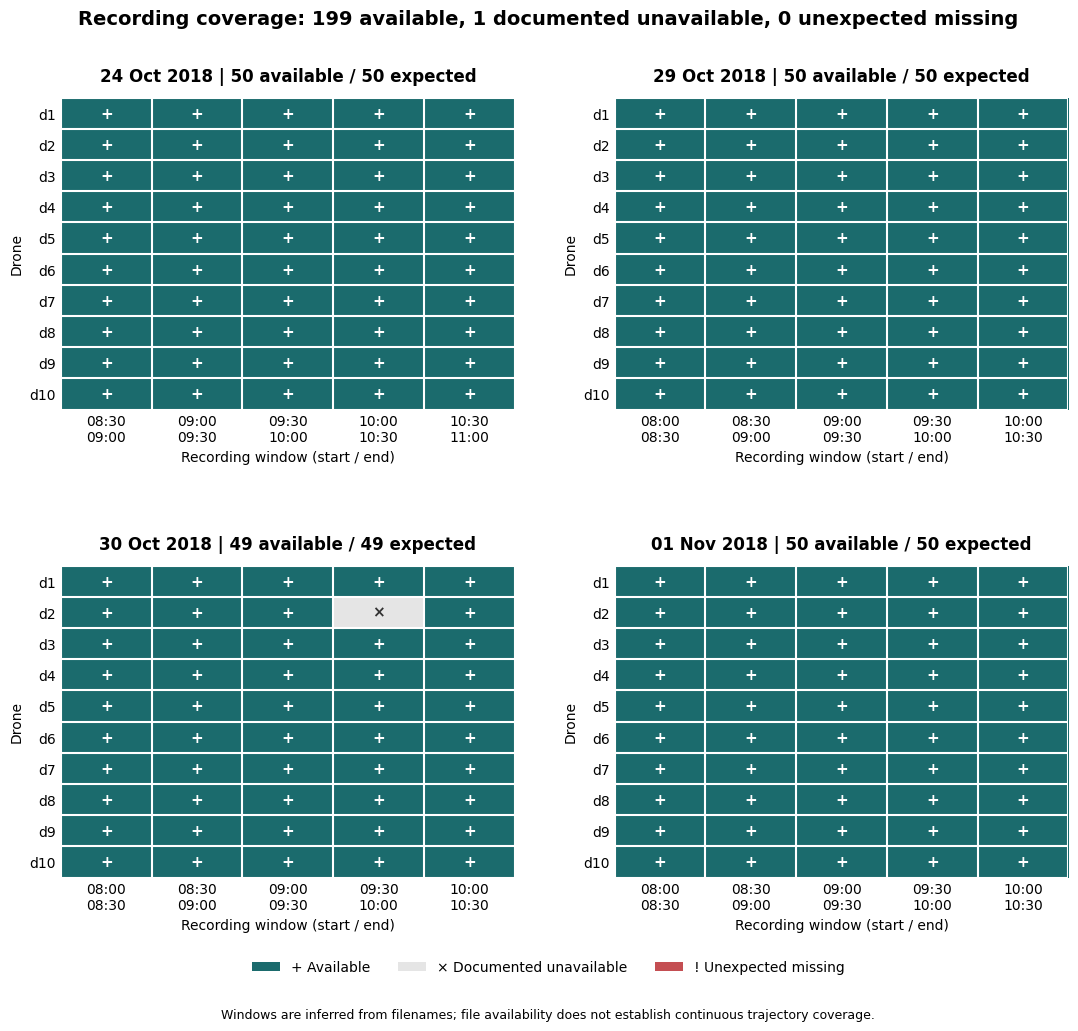

Saved PNG + PDF: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/fig_recording_coverage
Parser inputs ready: 199 CSV files.
Coverage uses the previously verified inventory. This cell rechecks file availability and size, not full contents.
Trajectory observations have not yet been parsed or cleaned.


In [ ]:
# Recording coverage / Độ phủ các lần ghi hình

import json
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


# 1. Reuse the completed inventory / Dùng lại kiểm kê đã hoàn tất
manifest_path = REPORT_DIR / "raw_import_manifest.json"

if not manifest_path.is_file():
    raise FileNotFoundError(
        "The raw-input manifest is unavailable. "
        "Complete the preceding input-preparation cell first."
    )

with manifest_path.open("r", encoding="utf-8") as reader:
    source_manifest = json.load(reader)

if (
    source_manifest.get("status") != "passed"
    or source_manifest.get("run_id") != RUN_ID
    or source_manifest.get("recording_dates") != DATE_FILTER
    or source_manifest.get("expected_files_by_date")
    != EXPECTED_FILES_BY_DATE
    or source_manifest.get("known_unavailable_files")
    != KNOWN_UNAVAILABLE_FILES
):
    raise ValueError(
        "The saved inventory does not match the current configuration. "
        "Complete the preceding input-preparation cell again."
    )

verified_files = source_manifest.get("files", [])

if len(verified_files) != EXPECTED_RAW_FILES:
    raise ValueError(
        f"Expected {EXPECTED_RAW_FILES} inventory records; "
        f"found {len(verified_files)}."
    )

pattern = re.compile(
    r"^(\d{8})_d(10|[1-9])_(\d{4})_(\d{4})\.csv$",
    re.IGNORECASE,
)

records = []
paths_by_name = {}

for entry in verified_files:
    name = entry["filename"].casefold()
    match = pattern.fullmatch(name)

    if match is None:
        raise ValueError(f"Invalid recording identity in manifest: {name}")

    if name in paths_by_name:
        raise ValueError(f"Duplicate recording in manifest: {name}")

    date, drone, start, end = match.groups()
    start_time = datetime.strptime(date + start, "%Y%m%d%H%M")
    end_time = datetime.strptime(date + end, "%Y%m%d%H%M")

    if date not in DATE_FILTER or end_time <= start_time:
        raise ValueError(f"Invalid recording date or window: {name}")

    path = Path(entry["path"])

    if not path.is_absolute():
        raise ValueError(f"Inventory path must be absolute: {path}")

    path = path.resolve()
    raw_root = Path(RAW_DIR).resolve()

    if raw_root not in path.parents:
        raise ValueError(f"Inventory file is outside RAW_DIR: {path}")

    if path.name.casefold() != name:
        raise ValueError(f"Recording identity and path disagree: {name}")

    # Lightweight access check, not another full-content checksum.
    if not path.is_file():
        raise FileNotFoundError(f"Recorded CSV is unavailable: {path}")

    file_size = path.stat().st_size
    if file_size <= 0 or file_size != entry["bytes"]:
        raise ValueError(
            f"File size differs from the verified inventory: {name}. "
            "Rerun input preparation."
        )

    paths_by_name[name] = path
    records.append({
        "filename": name,
        "flight": path.stem,
        "date": date,
        "drone": int(drone),
        "start": start,
        "end": end,
        "bytes": file_size,
    })

inventory = (
    pd.DataFrame(records)
    .sort_values(["date", "drone", "start", "end"])
    .reset_index(drop=True)
)

actual_counts = inventory.groupby("date").size().to_dict()
if actual_counts != EXPECTED_FILES_BY_DATE:
    raise ValueError("Inventory counts do not match the configured dates.")

# Preserve the inputs required by subsequent trajectory-processing cells.
input_files = [
    paths_by_name[name] for name in inventory["filename"]
]
records = inventory.to_dict(orient="records")


# 2. Construct coverage states / Xây dựng trạng thái độ phủ
# 0 = unexpected missing; 1 = available; 2 = documented unavailable
available_names = set(inventory["filename"])
known_missing = {
    name.casefold() for name in KNOWN_UNAVAILABLE_FILES
}

if available_names & known_missing:
    raise ValueError(
        "A documented unavailable recording is now present. "
        "Review the source scope before continuing."
    )

coverage_rows = []
windows_by_date = {}

for date in DATE_FILTER:
    daily = inventory.loc[inventory["date"] == date]
    windows = sorted(set(
        daily[["start", "end"]].itertuples(index=False, name=None)
    ))

    if len(windows) != 5:
        raise ValueError(
            f"{date}: expected five observed window labels; found {windows}."
        )

    windows_by_date[date] = windows

    for drone in range(1, 11):
        for start, end in windows:
            name = f"{date}_d{drone}_{start}_{end}.csv"

            if name in available_names:
                state = 1
            elif name in known_missing:
                state = 2
            else:
                state = 0

            coverage_rows.append({
                "date": date,
                "drone": drone,
                "start": start,
                "end": end,
                "filename": name,
                "state": state,
            })

coverage = pd.DataFrame(coverage_rows)

if not known_missing.issubset(set(coverage["filename"])):
    raise ValueError(
        "The documented exception does not match the coverage layout."
    )


# 3. One figure, four dates / Một hình gồm bốn ngày
colours = ["#C44E52", TEAL, "#E5E5E5"]
cmap = ListedColormap(colours)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

ncols = 2
nrows = (len(DATE_FILTER) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(13, 5.2 * nrows),
    squeeze=False,
)

for ax, date in zip(axes.flat, DATE_FILTER):
    windows = windows_by_date[date]
    daily = coverage.loc[coverage["date"] == date]

    lookup = {
        (row.drone, row.start, row.end): row.state
        for row in daily.itertuples(index=False)
    }

    matrix = np.array([
        [lookup[(drone, start, end)] for start, end in windows]
        for drone in range(1, 11)
    ])

    ax.imshow(
        matrix,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        interpolation="nearest",
    )

    labels = [
        f"{start[:2]}:{start[2:]}\n{end[:2]}:{end[2:]}"
        for start, end in windows
    ]

    ax.set_xticks(range(len(windows)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(10))
    ax.set_yticklabels([f"d{i}" for i in range(1, 11)])
    ax.set_xlabel("Recording window (start / end)")
    ax.set_ylabel("Drone")

    observed_count = int((matrix == 1).sum())
    expected_count = EXPECTED_FILES_BY_DATE[date]
    date_label = datetime.strptime(date, "%Y%m%d").strftime("%d %b %Y")

    ax.set_title(
        f"{date_label} | {observed_count} available "
        f"/ {expected_count} expected",
        pad=12,
    )

    # Symbols make the status readable without colour alone.
    symbols = {0: "!", 1: "+", 2: "×"}
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            state = int(matrix[row, col])
            ax.text(
                col,
                row,
                symbols[state],
                ha="center",
                va="center",
                color="white" if state in (0, 1) else "#333333",
                fontsize=11,
                fontweight="bold",
            )

    ax.set_xticks(np.arange(-0.5, len(windows), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

for ax in list(axes.flat)[len(DATE_FILTER):]:
    ax.set_visible(False)

available_count = int((coverage["state"] == 1).sum())
documented_count = int((coverage["state"] == 2).sum())
unexpected_count = int((coverage["state"] == 0).sum())

fig.suptitle(
    f"Recording coverage: {available_count} available, "
    f"{documented_count} documented unavailable, "
    f"{unexpected_count} unexpected missing",
    fontsize=14,
    fontweight="bold",
    y=0.985,
)

fig.legend(
    handles=[
        Patch(facecolor=TEAL, label="+ Available"),
        Patch(facecolor="#E5E5E5", label="× Documented unavailable"),
        Patch(facecolor="#C44E52", label="! Unexpected missing"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.045),
    ncol=3,
    frameon=False,
)

fig.text(
    0.5,
    0.015,
    "Windows are inferred from filenames; file availability does not "
    "establish continuous trajectory coverage.",
    ha="center",
    fontsize=9,
)

fig.subplots_adjust(
    top=0.90,
    bottom=0.15,
    hspace=0.50,
    wspace=0.22,
)

save_figure(fig, "fig_recording_coverage", tight_layout=False)


# 4. Handover check / Kiểm tra trước khi đọc quỹ đạo
if unexpected_count:
    missing_names = coverage.loc[
        coverage["state"] == 0, "filename"
    ].tolist()

    raise ValueError(
        "Unexpected missing recordings:\n" + "\n".join(missing_names)
    )

print(f"Parser inputs ready: {len(input_files)} CSV files.")
print(
    "Coverage uses the previously verified inventory. "
    "This cell rechecks file availability and size, not full contents."
)
print("Trajectory observations have not yet been parsed or cleaned.")

### 6. Trajectory parsing (Đọc và chuyển đổi quỹ đạo)

This step converts each recording into an intermediate Parquet table with one row per vehicle observation.

(Bước này chuyển mỗi lần ghi hình thành một bảng Parquet trung gian, trong đó mỗi dòng là một lần quan sát phương tiện.)

```text
Raw CSV: one vehicle row → multiple six-value trajectory blocks
                              ↓
Parquet: one observation → flight, track_id, vtype,
                          lat, lon, speed_kmh, t
```

Each trajectory block follows `(lat, lon, speed, lon_acc, lat_acc, time)`. The parser retains location, speed and time, together with the recording and vehicle identifiers. Acceleration and whole-trajectory summaries are not included in this intermediate table.

(Mỗi khối quỹ đạo có thứ tự `(lat, lon, speed, lon_acc, lat_acc, time)`. Bộ đọc giữ vị trí, tốc độ, thời gian cùng mã lần ghi hình và mã phương tiện. Gia tốc và các thống kê toàn quỹ đạo không được đưa vào bảng trung gian này.)

**Validation and exceptions (Kiểm tra và ngoại lệ)**

Header names must match the expected positions or explicitly recognised aliases. Incomplete trajectory blocks and invalid numeric representations in retained fields stop processing. One previously reviewed malformed vehicle row may be excluded only when its recording identifier, line number and content hash match the documented exception; its contents and exclusion reason are preserved.

(Tên cột phải đúng vị trí quy định hoặc thuộc các tên tương đương được khai báo rõ. Khối quỹ đạo không đầy đủ và giá trị không chuyển được sang số trong các trường được giữ lại sẽ làm quá trình dừng. Một hàng xe lỗi đã được rà soát chỉ được loại khi mã lần ghi hình, số dòng và mã băm nội dung khớp ngoại lệ đã ghi nhận; nội dung và lý do loại được lưu lại.)

**Processing and resuming (Xử lý và chạy tiếp)**

Observations are written in batches of `BATCH_SIZE` points. One recording is staged in temporary local storage at a time. A checkpoint records completion only after its Parquet output has passed verification. Reuse requires matching parser settings, source and output checksums, table structure and row count.

(Các quan sát được ghi theo lô `BATCH_SIZE` điểm. Mỗi lần chỉ đưa một bản ghi vào thư mục tạm trên máy chạy. Checkpoint chỉ ghi nhận hoàn thành sau khi đầu ra Parquet vượt qua kiểm tra. Việc dùng lại yêu cầu khớp cấu hình parser, mã kiểm tra nguồn và đầu ra, cấu trúc bảng và số dòng.)

**Expected output (Đầu ra cần đọc)**

A summary by date reports completed recordings, accepted vehicle rows, trajectory points and quarantined vehicle rows. A small observation sample illustrates the resulting table. Vehicle rows are recording-specific tracks, not a count of unique physical vehicles across the study.

(Bảng tổng hợp theo ngày báo số lần ghi hình hoàn tất, số hàng xe được chấp nhận, số điểm quỹ đạo và số hàng xe bị cách ly. Một mẫu quan sát nhỏ minh họa bảng sau chuyển đổi. Hàng xe là quỹ đạo trong từng lần ghi hình, không phải số phương tiện vật lý duy nhất trong toàn nghiên cứu.)

This is structural conversion, not completed cleaning. Non-finite values, implausible measurements and duplicate observations are assessed next.

(Đây là bước chuyển đổi cấu trúc, chưa phải dữ liệu đã làm sạch hoàn toàn. Giá trị không hữu hạn, phép đo bất hợp lý và quan sát trùng được đánh giá ở bước tiếp theo.)

In [ ]:
# Trajectory parsing / Đọc và chuyển đổi quỹ đạo
# Rerun safely: reuse verified outputs; rebuild incompatible/incomplete ones.

import os

if globals().get("IN_COLAB", False):
    os.chdir("/content")

import errno
import hashlib
import json
import re
import shutil
import tempfile
import time
from pathlib import Path

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display


# ============================================================
# 1. Configuration / Cấu hình
# ============================================================

required = [
    "input_files", "BATCH_SIZE", "EXPECTED_RAW_FILES",
    "PROCESSED_DIR", "REPORT_DIR", "RUN_ID", "DATE_FILTER",
    "RAW_DIR", "EXPECTED_FILES_BY_DATE", "KNOWN_UNAVAILABLE_FILES",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Run configuration and source inventory first. "
        f"Missing variables: {missing}"
    )

if (
    not isinstance(BATCH_SIZE, int)
    or isinstance(BATCH_SIZE, bool)
    or BATCH_SIZE <= 0
):
    raise ValueError("BATCH_SIZE must be a positive integer.")

selected_inputs = [Path(path).resolve() for path in input_files]

if len(selected_inputs) != EXPECTED_RAW_FILES:
    raise ValueError("Input count differs from the configured study scope.")

PARSER_VERSION = "trajectory_parts_v6"

schema = pa.schema([
    ("flight", pa.string()),
    ("track_id", pa.string()),
    ("vtype", pa.string()),
    ("lat", pa.float64()),
    ("lon", pa.float64()),
    ("speed_kmh", pa.float64()),
    ("t", pa.float64()),
])

EXPECTED_HEADER = [
    "track_id", "type", "traveled_d", "avg_speed",
    "lat", "lon", "speed", "lon_acc", "lat_acc", "time",
]

HEADER_ALIASES = {
    "track_id": {"trackid", "ftrackid"},
    "type": {"type", "vtype", "vehicletype"},
    "traveled_d": {
        "traveledd", "travelledd",
        "traveleddistance", "travelleddistance",
    },
    "avg_speed": {"avgspeed", "averagespeed", "meanspeed"},
    "lat": {"lat", "latitude"},
    "lon": {"lon", "lng", "long", "longitude"},
    "speed": {"speed", "speedkmh"},
    "lon_acc": {"lonacc", "longitudinalacceleration"},
    "lat_acc": {"latacc", "lateralacceleration"},
    "time": {"time", "t", "timestamp"},
}

KNOWN_BAD_FLIGHT = "20181029_d4_0900_0930"
KNOWN_BAD_LINE = 24
KNOWN_BAD_ROW_SHA256 = (
    "d14b4e95fd361186f86cc53b3977857ed0c32e7034cfb6e4a0936e08abb50ca3"
)

parser_policy = {
    "version": PARSER_VERSION,
    "schema": [(field.name, str(field.type)) for field in schema],
    "header_aliases": {
        name: sorted(values) for name, values in HEADER_ALIASES.items()
    },
    "retained_offsets": [0, 1, 2, 5],
    "newline_policy": "universal_newlines",
    "quarantine": [
        KNOWN_BAD_FLIGHT, KNOWN_BAD_LINE, KNOWN_BAD_ROW_SHA256
    ],
}

POLICY_HASH = hashlib.sha256(
    json.dumps(parser_policy, sort_keys=True).encode("utf-8")
).hexdigest()

LONG_PARTS_DIR = Path(PROCESSED_DIR) / "trajectory_parts"
CHECKPOINT_DIR = LONG_PARTS_DIR / "checkpoints"

# Clear partial/stale handover variables from an earlier attempt.
LONG_FILES = []
parsing_records = []
parsing_summary = pd.DataFrame()
total_rows = 0
saved_rows = 0
PARSING_COMPLETE = False

active_file = None
active_stage = "manifest validation"
started_at = time.perf_counter()


# ============================================================
# 2. Helpers / Hàm hỗ trợ
# ============================================================

def remove_own_staging(path):
    """Best-effort cleanup without hiding an earlier I/O error."""
    try:
        Path(path).unlink(missing_ok=True)
    except OSError:
        pass


def atomic_json(path, value):
    path = Path(path)
    staging = path.with_name(path.name + ".building")
    try:
        staging.write_text(
            json.dumps(value, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
        os.replace(staging, path)
    finally:
        remove_own_staging(staging)


def atomic_csv(frame, path):
    path = Path(path)
    staging = path.with_name(path.name + ".building")
    try:
        frame.to_csv(staging, index=False, encoding="utf-8-sig")
        os.replace(staging, path)
    finally:
        remove_own_staging(staging)


def hash_file(path):
    checksum = hashlib.sha256()
    count = 0
    with Path(path).open("rb") as reader:
        for block in iter(lambda: reader.read(8 * 1024 * 1024), b""):
            checksum.update(block)
            count += len(block)
    return count, checksum.hexdigest()


def copy_checked(source, target, expected_size, expected_hash):
    """Check source stream and stored copy; keep memory bounded."""
    checksum = hashlib.sha256()
    count = 0

    with Path(source).open("rb") as reader:
        with Path(target).open("wb") as writer:
            for block in iter(lambda: reader.read(8 * 1024 * 1024), b""):
                writer.write(block)
                checksum.update(block)
                count += len(block)

    if count != expected_size or checksum.hexdigest() != expected_hash:
        raise ValueError(
            f"Source changed or copy is incomplete: {source}. "
            "Recheck the raw-input inventory."
        )

    if hash_file(target) != (expected_size, expected_hash):
        raise IOError(f"Stored copy failed verification: {target}")


def split_fields(line):
    fields = [value.strip() for value in line.split(";")]
    while fields and fields[-1] == "":
        fields.pop()
    return fields


def inspect_header(line, filename):
    fields = split_fields(line)
    if len(fields) != len(EXPECTED_HEADER):
        raise ValueError(
            f"{filename}: expected 10 header fields; found {len(fields)}."
        )

    differences = []
    for position, (observed, expected) in enumerate(
        zip(fields, EXPECTED_HEADER), start=1
    ):
        normalized = re.sub(
            r"[^a-z0-9]", "", observed.lstrip("\ufeff").lower()
        )
        if normalized not in HEADER_ALIASES[expected]:
            raise ValueError(
                f"{filename}: invalid header at position {position}: "
                f"{observed!r}; expected {expected!r}."
            )
        if observed != expected:
            differences.append({
                "position": position,
                "observed": observed,
                "expected": expected,
            })

    return {
        "status": "accepted_normalized" if differences else "exact_match",
        "original_header": fields,
        "differences": differences,
    }


def check_parquet(path, expected_rows):
    with pq.ParquetFile(path) as parquet:
        if not parquet.schema_arrow.equals(schema, check_metadata=False):
            raise ValueError(f"Unexpected Parquet schema: {path}")
        if (
            parquet.metadata.num_rows <= 0
            or parquet.metadata.num_rows != expected_rows
        ):
            raise ValueError(f"Unexpected Parquet row count: {path}")


def load_checkpoint(path):
    """Missing or malformed metadata triggers rebuilding."""
    try:
        value = json.loads(Path(path).read_text(encoding="utf-8"))
        return value if isinstance(value, dict) else None
    except (FileNotFoundError, json.JSONDecodeError, UnicodeDecodeError):
        return None
    # Other I/O failures propagate: a disconnected Drive is not a bad checkpoint.


def checkpoint_matches(record, source, info):
    if not isinstance(record, dict):
        return False

    required_counts = [
        "vehicle_rows", "trajectory_points", "blank_lines",
        "rejected_vehicle_rows", "parquet_bytes",
    ]
    if any(
        type(record.get(key)) is not int or record[key] < 0
        for key in required_counts
    ):
        return False

    if record["trajectory_points"] <= 0 or record["parquet_bytes"] <= 0:
        return False

    if (
        record.get("parser_version") != PARSER_VERSION
        or record.get("parser_policy_sha256") != POLICY_HASH
        or record.get("filename") != source.name
        or record.get("flight") != source.stem
        or record.get("source_bytes") != info["bytes"]
        or record.get("source_sha256") != info["sha256"]
        or not isinstance(record.get("header_report"), dict)
    ):
        return False

    output_hash = record.get("parquet_sha256")
    if not isinstance(output_hash, str) or not re.fullmatch(
        r"[0-9a-f]{64}", output_hash
    ):
        return False

    quarantine = record.get("quarantine")
    if not isinstance(quarantine, list):
        return False
    if len(quarantine) != record["rejected_vehicle_rows"]:
        return False

    for item in quarantine:
        if not isinstance(item, dict):
            return False
        line = item.get("original_line")
        if (
            source.stem != KNOWN_BAD_FLIGHT
            or item.get("line") != KNOWN_BAD_LINE
            or not isinstance(line, str)
            or hashlib.sha256(line.encode("utf-8")).hexdigest()
            != KNOWN_BAD_ROW_SHA256
        ):
            return False

    return True


def parse_local(source, output, scratch_dir):
    rows = []
    points = 0
    vehicle_rows = 0
    blank_lines = 0
    quarantine = []
    flight = source.stem

    def flush(writer):
        if not rows:
            return
        if shutil.disk_usage(scratch_dir).free < 512 * 1024**2:
            raise OSError(
                errno.ENOSPC, "Local temporary storage is nearly full."
            )

        frame = pd.DataFrame.from_records(rows, columns=schema.names)
        table = pa.Table.from_pandas(
            frame, schema=schema, preserve_index=False
        )
        writer.write_table(table)
        rows.clear()

    with source.open("r", encoding="utf-8-sig", newline=None) as reader:
        header_line = next(reader, None)
        if header_line is None:
            raise ValueError(f"Empty CSV: {source.name}")

        header = inspect_header(header_line, source.name)

        with pq.ParquetWriter(output, schema, compression="snappy") as writer:
            for line_number, line in enumerate(reader, start=2):
                if not line.strip():
                    blank_lines += 1
                    continue

                if (
                    flight == KNOWN_BAD_FLIGHT
                    and line_number == KNOWN_BAD_LINE
                    and hashlib.sha256(line.encode("utf-8")).hexdigest()
                    == KNOWN_BAD_ROW_SHA256
                ):
                    quarantine.append({
                        "line": line_number,
                        "sha256": KNOWN_BAD_ROW_SHA256,
                        "action": "exclude_entire_vehicle_row",
                        "reason": (
                            "Previously reviewed structural corruption: "
                            "Bicycle.0064 embedded in trajectory fields."
                        ),
                        "trajectory_points_excluded": None,
                        "original_line": line,
                    })
                    continue

                fields = split_fields(line)
                if len(fields) < 10 or (len(fields) - 4) % 6:
                    raise ValueError(
                        f"{source.name}, line {line_number}: "
                        "incomplete six-value trajectory blocks."
                    )

                track_id, vtype = fields[:2]
                if not track_id or not vtype:
                    raise ValueError(
                        f"{source.name}, line {line_number}: "
                        "empty vehicle identifier or type."
                    )

                vehicle_rows += 1

                for offset in range(4, len(fields), 6):
                    try:
                        observation = (
                            flight, track_id, vtype,
                            float(fields[offset]),
                            float(fields[offset + 1]),
                            float(fields[offset + 2]),
                            float(fields[offset + 5]),
                        )
                    except ValueError as exc:
                        raise ValueError(
                            f"{source.name}, line {line_number}, "
                            f"point {(offset - 4) // 6 + 1}: "
                            "invalid numeric representation in a retained field."
                        ) from exc

                    rows.append(observation)
                    points += 1
                    if len(rows) >= BATCH_SIZE:
                        flush(writer)

            flush(writer)

    check_parquet(output, points)

    return {
        "vehicle_rows": vehicle_rows,
        "trajectory_points": points,
        "blank_lines": blank_lines,
        "rejected_vehicle_rows": len(quarantine),
        "header_status": header["status"],
        "header_difference_count": len(header["differences"]),
        "header_report": header,
        "quarantine": quarantine,
    }


# ============================================================
# 3. Validate inventory / Đối chiếu kiểm kê nguồn
# ============================================================

try:
    manifest_path = Path(REPORT_DIR) / "raw_import_manifest.json"
    raw_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))

    if (
        raw_manifest.get("status") != "passed"
        or raw_manifest.get("run_id") != RUN_ID
        or raw_manifest.get("recording_dates") != DATE_FILTER
        or raw_manifest.get("expected_files_by_date")
        != EXPECTED_FILES_BY_DATE
        or raw_manifest.get("known_unavailable_files")
        != KNOWN_UNAVAILABLE_FILES
    ):
        raise ValueError(
            "Raw inventory does not match the current configuration. "
            "Complete raw-input preparation first."
        )

    manifest_rows = raw_manifest.get("files", [])
    source_info = {
        row["filename"].casefold(): row for row in manifest_rows
    }
    selected_names = {path.name.casefold() for path in selected_inputs}

    if (
        len(selected_names) != len(selected_inputs)
        or len(source_info) != len(manifest_rows)
        or set(source_info) != selected_names
    ):
        raise ValueError("Parser inputs and raw inventory do not match.")

    raw_root = Path(RAW_DIR).resolve()

    for source in selected_inputs:
        info = source_info[source.name.casefold()]
        if (
            raw_root not in source.parents
            or source != Path(info["path"]).resolve()
        ):
            raise ValueError(f"Source path differs from inventory: {source}")

        if not re.fullmatch(r"[0-9a-f]{64}", str(info.get("sha256", ""))):
            raise ValueError(f"Invalid source checksum: {source.name}")

    for directory in (LONG_PARTS_DIR, CHECKPOINT_DIR, Path(REPORT_DIR)):
        directory.mkdir(parents=True, exist_ok=True)

    print(
        f"Recordings: {len(selected_inputs)} | "
        f"Batch size: {BATCH_SIZE:,} observations"
    )
    print("Valid outputs are reused; old or incomplete outputs are rebuilt.")


    # ========================================================
    # 4. Process or reuse each recording / Xử lý hoặc dùng lại
    # ========================================================

    for number, source in enumerate(selected_inputs, start=1):
        active_file = source.name
        active_stage = "checkpoint inspection"

        info = source_info[source.name.casefold()]
        source_size = int(info["bytes"])
        source_hash = info["sha256"]
        flight = source.stem

        destination = LONG_PARTS_DIR / f"{flight}.parquet"
        checkpoint = CHECKPOINT_DIR / f"{flight}.json"
        previous = load_checkpoint(checkpoint)

        print(
            f"[{number}/{len(selected_inputs)}] {source.name}",
            flush=True,
        )

        compatible = checkpoint_matches(previous, source, info)
        reuse = False

        if compatible:
            active_stage = "source verification"

            # Detect changes even when source file size is unchanged.
            if hash_file(source) != (source_size, source_hash):
                raise ValueError(
                    f"Raw source changed: {source.name}. "
                    "Rerun raw-input verification before parsing."
                )

            with source.open("r", encoding="utf-8-sig") as reader:
                current_header = inspect_header(reader.readline(), source.name)

            if current_header == previous["header_report"]:
                active_stage = "completed-output verification"

                try:
                    stored_size = destination.stat().st_size
                except FileNotFoundError:
                    stored_size = None

                if stored_size == previous["parquet_bytes"]:
                    observed_size, observed_hash = hash_file(destination)
                    if (
                        observed_size == previous["parquet_bytes"]
                        and observed_hash == previous["parquet_sha256"]
                    ):
                        try:
                            check_parquet(
                                destination, previous["trajectory_points"]
                            )
                            reuse = True
                        except (ValueError, pa.ArrowInvalid):
                            reuse = False

        if reuse:
            record = previous
            action = "reused"

        else:
            action = (
                "rebuilt"
                if previous is not None or destination.exists()
                else "created"
            )
            file_started_at = time.perf_counter()

            with tempfile.TemporaryDirectory(
                prefix="pneuma_recording_"
            ) as scratch:
                scratch_dir = Path(scratch)
                local_csv = scratch_dir / source.name
                local_parquet = scratch_dir / "trajectory.parquet"

                # Initial reserve only; storage is also checked per batch.
                if shutil.disk_usage(scratch_dir).free < (
                    3 * source_size + 1024**3
                ):
                    raise OSError(
                        errno.ENOSPC, "Insufficient local temporary storage."
                    )

                active_stage = "source staging"
                copy_checked(source, local_csv, source_size, source_hash)

                active_stage = "trajectory parsing"
                statistics = parse_local(
                    local_csv, local_parquet, scratch_dir
                )
                parquet_size, parquet_hash = hash_file(local_parquet)

                active_stage = "verified output replacement"
                if shutil.disk_usage(LONG_PARTS_DIR).free < parquet_size:
                    raise OSError(
                        errno.ENOSPC,
                        "Insufficient reported storage for staged output.",
                    )

                # Keep the existing completed Parquet until the new copy passes.
                staging = destination.with_name(
                    destination.name + ".uploading"
                )
                try:
                    copy_checked(
                        local_parquet, staging, parquet_size, parquet_hash
                    )
                    check_parquet(staging, statistics["trajectory_points"])
                    os.replace(staging, destination)
                finally:
                    remove_own_staging(staging)

                if hash_file(destination) != (parquet_size, parquet_hash):
                    raise IOError(
                        f"Final output verification failed: {destination}"
                    )

                record = {
                    "parser_version": PARSER_VERSION,
                    "parser_policy_sha256": POLICY_HASH,
                    "filename": source.name,
                    "flight": flight,
                    "source_bytes": source_size,
                    "source_sha256": source_hash,
                    **statistics,
                    "parquet_path": str(destination),
                    "parquet_bytes": parquet_size,
                    "parquet_sha256": parquet_hash,
                    "parse_seconds": time.perf_counter() - file_started_at,
                }

                # Completion is recorded only after final output verification.
                active_stage = "checkpoint update"
                atomic_json(checkpoint, record)

        parsing_records.append({
            **record,
            "parquet_path": str(destination),
            "action": action,
        })
        LONG_FILES.append(destination)

        print(
            f"  {action} | "
            f"{record['trajectory_points']:,} observations",
            flush=True,
        )


    # ========================================================
    # 5. Save handover / Lưu kết quả bàn giao
    # ========================================================

    active_file = None
    active_stage = "summary export"

    parsing_summary = pd.DataFrame(parsing_records)
    total_rows = int(parsing_summary["trajectory_points"].sum())
    saved_rows = total_rows

    if len(LONG_FILES) != EXPECTED_RAW_FILES or total_rows <= 0:
        raise ValueError("Final parsing results do not cover the selected scope.")

    parsing_report = Path(REPORT_DIR) / "table_raw_parsing.csv"

    atomic_csv(
        parsing_summary.drop(columns=["header_report", "quarantine"]),
        parsing_report,
    )

    atomic_json(
        Path(REPORT_DIR) / "trajectory_parts_manifest.json",
        {
            "run_id": RUN_ID,
            "status": "passed",
            "parser_version": PARSER_VERSION,
            "parser_policy_sha256": POLICY_HASH,
            "recordings": len(LONG_FILES),
            "trajectory_points": total_rows,
            "quarantined_vehicle_rows": int(
                parsing_summary["rejected_vehicle_rows"].sum()
            ),
            "files": [str(path) for path in LONG_FILES],
        },
    )

    PARSING_COMPLETE = True

except Exception as exc:
    completed_count = len(LONG_FILES)

    # Do not expose a partial file list as a completed handover.
    LONG_FILES = []
    parsing_summary = pd.DataFrame()
    total_rows = 0
    saved_rows = 0
    PARSING_COMPLETE = False

    print("\nPARSING STOPPED / CHƯA HOÀN TẤT")
    print("Stage:", active_stage)
    if active_file:
        print("Recording:", active_file)
    print("Completed or verified in this attempt:", completed_count)
    print("Error:", str(exc))

    if isinstance(exc, OSError) and exc.errno == errno.ENOTCONN:
        print("Reconnect Drive, then rerun this same cell.")

    print(
        "Completed files remain available for verification and reuse. "
        "Do not run downstream processing until this cell completes."
    )
    raise


# ============================================================
# 6. Compact output / Đầu ra ngắn gọn
# ============================================================

summary_by_date = (
    parsing_summary
    .assign(date=parsing_summary["filename"].str[:8])
    .groupby("date", as_index=False)
    .agg(
        recordings=("filename", "size"),
        accepted_vehicle_rows=("vehicle_rows", "sum"),
        trajectory_points=("trajectory_points", "sum"),
        quarantined_vehicle_rows=("rejected_vehicle_rows", "sum"),
    )
)

summary_by_date["date"] = pd.to_datetime(
    summary_by_date["date"], format="%Y%m%d"
).dt.strftime("%Y-%m-%d")

print("\nTRAJECTORY PARSING COMPLETE / CHUYỂN ĐỔI HOÀN TẤT")

display(
    summary_by_date.style.hide(axis="index").format({
        "recordings": "{:,}",
        "accepted_vehicle_rows": "{:,}",
        "trajectory_points": "{:,}",
        "quarantined_vehicle_rows": "{:,}",
    })
)

print("\nObservation sample / Mẫu quan sát:")
with pq.ParquetFile(LONG_FILES[0]) as parquet:
    sample = next(parquet.iter_batches(batch_size=5)).to_pandas()
display(sample)

actions = parsing_summary["action"].value_counts()
print(
    f"Created: {actions.get('created', 0)} | "
    f"Rebuilt: {actions.get('rebuilt', 0)} | "
    f"Reused: {actions.get('reused', 0)}"
)
print(f"Elapsed: {(time.perf_counter() - started_at) / 60:.1f} minutes")
print("Detailed report:", parsing_report)
print(
    "Vehicle rows are recording-specific tracks, not unique vehicles "
    "across the study. Observation values still require cleaning."
)

Recordings: 199 | Batch size: 100,000 observations
Valid outputs are reused; old or incomplete outputs are rebuilt.
[1/199] 20181024_d1_0830_0900.csv
  reused | 1,446,887 observations
[2/199] 20181024_d1_0900_0930.csv
  reused | 2,042,963 observations
[3/199] 20181024_d1_0930_1000.csv
  reused | 2,165,658 observations
[4/199] 20181024_d1_1000_1030.csv
  reused | 2,915,666 observations
[5/199] 20181024_d1_1030_1100.csv
  reused | 1,491,548 observations
[6/199] 20181024_d2_0830_0900.csv
  reused | 3,761,480 observations
[7/199] 20181024_d2_0900_0930.csv
  reused | 5,215,862 observations
[8/199] 20181024_d2_0930_1000.csv
  reused | 7,010,106 observations
[9/199] 20181024_d2_1000_1030.csv
  reused | 5,619,932 observations
[10/199] 20181024_d2_1030_1100.csv
  reused | 2,419,883 observations
[11/199] 20181024_d3_0830_0900.csv
  reused | 3,366,770 observations
[12/199] 20181024_d3_0900_0930.csv
  reused | 4,357,803 observations
[13/199] 20181024_d3_0930_1000.csv
  reused | 4,774,236 observati

date,recordings,accepted_vehicle_rows,trajectory_points,quarantined_vehicle_rows
2018-10-24,50,"115,390","266,242,917",0
2018-10-29,50,"115,740","244,768,900",1
2018-10-30,49,"115,075","245,742,605",0
2018-11-01,50,"109,392","219,094,552",0



Observation sample / Mẫu quan sát:


,flight,track_id,vtype,lat,lon,speed_kmh,t
0,20181024_d1_0830_0900,1,Car,37.977391,23.737688,4.9178,0.00
1,20181024_d1_0830_0900,1,Car,37.977391,23.737688,4.9207,0.04
2,20181024_d1_0830_0900,1,Car,37.977391,23.737688,4.9160,0.08
3,20181024_d1_0830_0900,1,Car,37.977390,23.737688,4.9057,0.12
4,20181024_d1_0830_0900,1,Car,37.977390,23.737689,4.8871,0.16


Created: 0 | Rebuilt: 0 | Reused: 199
Elapsed: 21.1 minutes
Detailed report: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/table_raw_parsing.csv
Vehicle rows are recording-specific tracks, not unique vehicles across the study. Observation values still require cleaning.


### 7. Trajectory table verification (Kiểm chứng bảng quỹ đạo)

This step checks that the parsed tables cover the selected recordings and contain the expected observation counts before cleaning. It runs only after trajectory parsing completes successfully.

(Bước này kiểm tra các bảng đã chuyển đổi có đủ các lần ghi hình được chọn và có số quan sát khớp kết quả parser trước khi làm sạch. Chỉ thực hiện sau khi bước chuyển đổi quỹ đạo hoàn tất thành công.)

**Verification and output (Kiểm chứng và đầu ra)**

For each Parquet file in `LONG_FILES`, the verification compares its recording identifier and row count with the source inventory and parsing summary. It also checks that no selected recording is missing or represented more than once, and that the total row count matches the parsing result.

(Với mỗi file Parquet trong `LONG_FILES`, bước kiểm chứng đối chiếu mã lần ghi hình và số dòng với kiểm kê nguồn và bảng tổng kết parser. Đồng thời, kiểm tra không thiếu hoặc lặp lần ghi hình được chọn và tổng số dòng khớp kết quả chuyển đổi.)

A compact summary reports the number of recordings checked, the total observations and any mismatches. Per-recording results include the minimum and maximum finite values of `t`; missing or non-finite time values are counted separately for subsequent cleaning.

(Bảng tổng kết ngắn gọn báo số lần ghi hình đã kiểm tra, tổng số quan sát và các sai lệch nếu có. Kết quả theo từng lần ghi hình gồm giá trị hữu hạn nhỏ nhất và lớn nhất của `t`; thời gian thiếu hoặc không hữu hạn được đếm riêng để xử lý ở bước làm sạch.)

**Interpretation (Cách diễn giải)**

`t` is elapsed time in seconds relative to each recording’s time origin,

In [ ]:
# Verify trajectory tables / Kiểm chứng bảng quỹ đạo
# Read existing partitions in batches; do not merge or copy the dataset.

import os

if globals().get("IN_COLAB", False):
    os.chdir("/content")

from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import display


# 1. Reset verification state / Khởi tạo trạng thái kiểm chứng
TRAJECTORY_VERIFIED = False
VERIFIED_LONG_FILES = []

required_variables = [
    "PARSING_COMPLETE",
    "LONG_FILES",
    "input_files",
    "parsing_summary",
    "total_rows",
    "EXPECTED_RAW_FILES",
    "REPORT_DIR",
    "RUN_ID",
    "atomic_csv",
    "atomic_json",
]

missing_variables = [
    name for name in required_variables if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Complete the preceding parsing cell first. "
        f"Missing variables: {missing_variables}"
    )

if PARSING_COMPLETE is not True:
    raise RuntimeError(
        "Trajectory parsing has not completed successfully. "
        "Do not verify or clean partial results."
    )

expected_schema = pa.schema([
    ("flight", pa.string()),
    ("track_id", pa.string()),
    ("vtype", pa.string()),
    ("lat", pa.float64()),
    ("lon", pa.float64()),
    ("speed_kmh", pa.float64()),
    ("t", pa.float64()),
])

paths_to_verify = [Path(path).resolve() for path in LONG_FILES]
selected_inputs = [Path(path).resolve() for path in input_files]

checks = []
active_file = None
active_stage = "handover validation"
VERIFY_BATCH_SIZE = 100_000


try:
    # 2. Validate the complete handover / Đối chiếu bộ dữ liệu bàn giao
    required_columns = {
        "filename",
        "flight",
        "trajectory_points",
        "parquet_path",
        "parquet_bytes",
    }

    missing_columns = required_columns - set(parsing_summary.columns)
    if missing_columns:
        raise ValueError(
            f"Parsing summary is missing columns: {sorted(missing_columns)}"
        )

    if (
        len(paths_to_verify) != EXPECTED_RAW_FILES
        or len(selected_inputs) != EXPECTED_RAW_FILES
        or len(parsing_summary) != EXPECTED_RAW_FILES
    ):
        raise ValueError("Recording counts differ from the configured scope.")

    if len(set(paths_to_verify)) != len(paths_to_verify):
        raise ValueError("LONG_FILES contains duplicate paths.")

    selected_flights = {path.stem for path in selected_inputs}
    if len(selected_flights) != len(selected_inputs):
        raise ValueError("Source recordings have duplicate identifiers.")

    if (
        parsing_summary["flight"].isna().any()
        or parsing_summary["flight"].duplicated().any()
        or set(parsing_summary["flight"]) != selected_flights
    ):
        raise ValueError("Parsing summary recording identities do not match.")

    partition_flights = [path.stem for path in paths_to_verify]
    if (
        len(set(partition_flights)) != len(partition_flights)
        or set(partition_flights) != selected_flights
    ):
        raise ValueError("Parquet recordings are missing, extra or duplicated.")

    expected = parsing_summary.set_index("flight")
    expected_total = int(expected["trajectory_points"].sum())

    if expected_total <= 0 or expected_total != int(total_rows):
        raise ValueError("Parser observation totals do not agree.")

    inputs_by_flight = {path.stem: path for path in selected_inputs}

    print(f"Recordings to verify: {len(paths_to_verify)}")
    print(f"Expected observations: {expected_total:,}")
    print("Reading recording identifiers and times in bounded batches.")


    # 3. Inspect actual table contents / Kiểm tra nội dung bảng
    for number, path in enumerate(paths_to_verify, start=1):
        active_file = path.name
        active_stage = "partition verification"

        flight = path.stem
        expected_record = expected.loc[flight]
        expected_points = int(expected_record["trajectory_points"])

        if expected_record["filename"] != inputs_by_flight[flight].name:
            raise ValueError(f"Source filename mismatch: {flight}")

        if Path(expected_record["parquet_path"]).resolve() != path:
            raise ValueError(f"Parquet path mismatch: {flight}")

        saved_bytes = path.stat().st_size
        if saved_bytes != int(expected_record["parquet_bytes"]):
            raise ValueError(
                f"Parquet size changed after parsing: {path.name}. "
                "Rerun the parsing cell to verify or rebuild this output."
            )

        actual_points = 0
        missing_time = 0
        nonfinite_time = 0
        finite_time = 0
        t_min = None
        t_max = None

        with pq.ParquetFile(path) as parquet:
            if not parquet.schema_arrow.equals(
                expected_schema, check_metadata=False
            ):
                raise ValueError(f"Unexpected table schema: {path.name}")

            metadata_rows = parquet.metadata.num_rows
            if metadata_rows <= 0 or metadata_rows != expected_points:
                raise ValueError(
                    f"Metadata row count differs from parser: {path.name}"
                )

            for batch in parquet.iter_batches(
                columns=["flight", "t"],
                batch_size=VERIFY_BATCH_SIZE,
            ):
                flights = batch.column(0)
                times = batch.column(1)

                # Null identifiers and any different identifier are failures.
                wrong_flight = pc.fill_null(
                    pc.not_equal(flights, pa.scalar(flight)),
                    True,
                )
                if pc.any(wrong_flight).as_py():
                    raise ValueError(
                        f"Missing or incorrect recording identifier: {path.name}"
                    )

                actual_points += batch.num_rows

                null_mask = pc.is_null(times).to_numpy(
                    zero_copy_only=False
                )
                values = times.to_numpy(zero_copy_only=False)
                finite_mask = np.isfinite(values)

                missing_time += int(null_mask.sum())
                nonfinite_time += int(
                    ((~null_mask) & (~finite_mask)).sum()
                )
                finite_time += int(finite_mask.sum())

                if finite_mask.any():
                    batch_min = float(values[finite_mask].min())
                    batch_max = float(values[finite_mask].max())

                    t_min = batch_min if t_min is None else min(t_min, batch_min)
                    t_max = batch_max if t_max is None else max(t_max, batch_max)

        if actual_points != expected_points:
            raise ValueError(
                f"Read row count differs from parser: {path.name}. "
                f"Read={actual_points:,}; expected={expected_points:,}."
            )

        if finite_time + missing_time + nonfinite_time != actual_points:
            raise ValueError(f"Time-value accounting failed: {path.name}")

        checks.append({
            "flight": flight,
            "parquet_file": path.name,
            "trajectory_points": actual_points,
            "finite_time_points": finite_time,
            "missing_time_points": missing_time,
            "nonfinite_time_points": nonfinite_time,
            "t_min": t_min,
            "t_max": t_max,
            "bytes": saved_bytes,
            "schema_matches": True,
            "recording_identifier_matches": True,
            "row_count_matches": True,
        })

        if number == 1 or number % 10 == 0 or number == len(paths_to_verify):
            print(
                f"Verified: {number}/{len(paths_to_verify)} recordings",
                flush=True,
            )


    # 4. Whole-dataset checks / Đối chiếu toàn bộ dữ liệu
    active_file = None
    active_stage = "dataset reconciliation"

    observed = (
        pd.DataFrame(checks)
        .sort_values("flight")
        .reset_index(drop=True)
    )

    verified_total = int(observed["trajectory_points"].sum())

    if (
        set(observed["flight"]) != selected_flights
        or verified_total != expected_total
    ):
        raise ValueError("Verified recordings or observation totals differ.")

    missing_total = int(observed["missing_time_points"].sum())
    nonfinite_total = int(observed["nonfinite_time_points"].sum())

    # Retained for compatibility with subsequent notebook cells.
    # These extrema are across recordings, not a shared timeline.
    result = pd.DataFrame([{
        "so_dong": verified_total,
        "so_flight": len(observed),
        "t_min": observed["t_min"].min(),
        "t_max": observed["t_max"].max(),
    }])


    # 5. Save two verification reports / Lưu hai báo cáo kiểm chứng
    active_stage = "report export"
    verification_csv = Path(REPORT_DIR) / "table_long_verification.csv"

    atomic_csv(observed, verification_csv)

    atomic_json(
        Path(REPORT_DIR) / "long_table_verification.json",
        {
            "run_id": RUN_ID,
            "status": "passed",
            "storage_layout": "one_parquet_per_recording",
            "rows": verified_total,
            "recordings": len(observed),
            "bytes": int(observed["bytes"].sum()),
            "per_recording_counts_match": True,
            "recording_identifiers_match": True,
            "schemas_match": True,
            "missing_time_points": missing_total,
            "nonfinite_time_points": nonfinite_total,
            "checksum_recomputed_in_this_step": False,
            "integrity_basis": (
                "The preceding completed parser verifies SHA-256. "
                "This step checks file size, schema and reads flight/time "
                "columns to verify identities, counts and time ranges."
            ),
            "files": [str(path) for path in paths_to_verify],
        },
    )

    VERIFIED_LONG_FILES = paths_to_verify.copy()
    TRAJECTORY_VERIFIED = True

except Exception as exc:
    VERIFIED_LONG_FILES = []
    TRAJECTORY_VERIFIED = False

    print("\nVERIFICATION STOPPED / KIỂM CHỨNG CHƯA HOÀN TẤT")
    print("Stage:", active_stage)
    if active_file:
        print("File:", active_file)
    print("Error:", str(exc))
    print("Do not run cleaning until verification completes.")
    raise


# 6. Compact reader-facing output / Kết quả hiển thị
verification_summary = pd.DataFrame([
    {
        "Check": "Selected recordings",
        "Expected": f"{EXPECTED_RAW_FILES:,}",
        "Observed": f"{len(observed):,}",
        "Result": "PASS",
    },
    {
        "Check": "Observation count",
        "Expected": f"{expected_total:,}",
        "Observed": f"{verified_total:,}",
        "Result": "PASS",
    },
    {
        "Check": "Schema and recording identifiers",
        "Expected": "Match in every file",
        "Observed": "Match in every file",
        "Result": "PASS",
    },
])

print("\nTRAJECTORY TABLES VERIFIED / BẢNG QUỸ ĐẠO ĐÃ KIỂM CHỨNG")
display(verification_summary.style.hide(axis="index"))

print(
    f"Time values for subsequent cleaning: "
    f"{missing_total:,} missing; "
    f"{nonfinite_total:,} non-finite (NaN or infinity, excluding nulls)."
)

print("\nPer-recording time-range sample / Mẫu phạm vi thời gian:")
display(
    observed[
        [
            "flight",
            "trajectory_points",
            "t_min",
            "t_max",
            "missing_time_points",
            "nonfinite_time_points",
        ]
    ].head(5).style.hide(axis="index").format({
        "trajectory_points": "{:,}",
        "t_min": "{:.2f}",
        "t_max": "{:.2f}",
        "missing_time_points": "{:,}",
        "nonfinite_time_points": "{:,}",
    }, na_rep="No finite time")
)

print("t_min/t_max: relative seconds within each recording, not clock time.")
print("Full per-recording report:", verification_csv)
print("Next: cleaning using VERIFIED_LONG_FILES.")

Recordings to verify: 199
Expected observations: 975,848,974
Reading recording identifiers and times in bounded batches.
Verified: 1/199 recordings
Verified: 10/199 recordings
Verified: 20/199 recordings
Verified: 30/199 recordings
Verified: 40/199 recordings
Verified: 50/199 recordings
Verified: 60/199 recordings
Verified: 70/199 recordings
Verified: 80/199 recordings
Verified: 90/199 recordings
Verified: 100/199 recordings
Verified: 110/199 recordings
Verified: 120/199 recordings
Verified: 130/199 recordings
Verified: 140/199 recordings
Verified: 150/199 recordings
Verified: 160/199 recordings
Verified: 170/199 recordings
Verified: 180/199 recordings
Verified: 190/199 recordings
Verified: 199/199 recordings

TRAJECTORY TABLES VERIFIED / BẢNG QUỸ ĐẠO ĐÃ KIỂM CHỨNG


Check,Expected,Observed,Result
Selected recordings,199,199,PASS
Observation count,"975,848,974","975,848,974",PASS
Schema and recording identifiers,Match in every file,Match in every file,PASS


Time values for subsequent cleaning: 0 missing; 0 non-finite (NaN or infinity, excluding nulls).

Per-recording time-range sample / Mẫu phạm vi thời gian:


flight,trajectory_points,t_min,t_max,missing_time_points,nonfinite_time_points
20181024_d10_0830_0900,"4,268,985",0.00,787.40,0,0
20181024_d10_0900_0930,"4,896,819",0.00,882.00,0,0
20181024_d10_0930_1000,"4,415,442",0.00,815.20,0,0
20181024_d10_1000_1030,"3,230,477",0.00,615.40,0,0
20181024_d10_1030_1100,"2,076,253",0.00,374.60,0,0


t_min/t_max: relative seconds within each recording, not clock time.
Full per-recording report: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/table_long_verification.csv
Next: cleaning using VERIFIED_LONG_FILES.


### 8. Cleaning and aggregation (Làm sạch và tổng hợp)

This step converts verified trajectory observations into a traffic panel with one row per recording, 100 m × 100 m cell and 10-second interval. It documents observation losses separately from the reduction caused by aggregation.

(Bước này chuyển các quan sát quỹ đạo đã kiểm chứng thành bảng giao thông, mỗi dòng tương ứng một lần ghi hình, ô 100 m × 100 m và khoảng 10 giây. Số quan sát bị loại được ghi nhận riêng với sự giảm số dòng do tổng hợp.)

**Observation cleaning (Làm sạch quan sát)**

Retained observations require non-empty vehicle identifiers and types, finite coordinates within valid latitude and longitude ranges, finite non-negative time, and finite speed satisfying `0 ≤ speed < MAX_SPEED_KMH`. Projected coordinates must also be finite. These rules do not establish that a point lies on a road or within the study area.

(Quan sát được giữ cần có mã phương tiện và loại xe không rỗng, tọa độ hữu hạn trong phạm vi kinh–vĩ độ hợp lệ, thời gian hữu hạn không âm và tốc độ hữu hạn thỏa `0 ≤ speed < MAX_SPEED_KMH`. Tọa độ sau chuyển đổi cũng phải hữu hạn. Các quy tắc này chưa xác nhận điểm nằm trên đường hoặc trong khu vực nghiên cứu.)

Invalid observations are counted once in the overall removal total, even when they violate multiple rules. Vehicle rows quarantined during parsing are reported separately and are not counted again as removed trajectory points.

(Mỗi quan sát không hợp lệ chỉ được tính một lần trong tổng số điểm bị loại, dù vi phạm nhiều điều kiện. Hàng xe được cách ly ở bước parser được báo cáo riêng, không tính lại thành điểm quỹ đạo bị loại.)

After validity filtering, observations are grouped by `(flight, track_id, t)`. Identical rows in the retained fields are collapsed to one observation. If a key has conflicting locations, speeds or vehicle types, the entire group is excluded from the main analysis and counted separately. This rule does not match physical vehicles across recordings or drones.

(Sau khi lọc giá trị hợp lệ, các quan sát được nhóm theo `(flight, track_id, t)`. Những dòng giống nhau ở các trường được giữ lại được gộp thành một quan sát. Nếu cùng khóa nhưng khác vị trí, tốc độ hoặc loại xe, toàn bộ nhóm được loại khỏi phân tích chính và thống kê riêng. Quy tắc này không nhận diện cùng phương tiện vật lý giữa các lần ghi hình hoặc drone.)

**Spatial and temporal units (Đơn vị không gian và thời gian)**

Coordinates are transformed from EPSG:4326 to EPSG:32634 and assigned to the fixed grid defined in the project configuration. `cell` combines the integer grid indices; exported `lat` and `lon` describe the cell centre, not individual vehicle positions.

(Tọa độ được chuyển từ EPSG:4326 sang EPSG:32634 và phân vào lưới cố định đã cấu hình. `cell` kết hợp các chỉ số ô nguyên; `lat` và `lon` trong bảng tổng hợp biểu diễn tâm ô, không phải vị trí từng phương tiện.)

Time is grouped within each recording. For example, `t = 127.5` seconds belongs to `t10 = 120`, representing `[120, 130)`. Different recordings remain separate. Intervals without retained observations are not filled with zeros.

(Thời gian được tổng hợp riêng trong từng lần ghi hình. Ví dụ, `t = 127,5` giây thuộc `t10 = 120`, đại diện cho `[120, 130)`. Các lần ghi hình khác nhau không được gộp chung. Khoảng không có quan sát được giữ lại không được điền bằng 0.)

**Aggregate variables (Các biến tổng hợp)**

| Variable / Biến | Meaning / Ý nghĩa |
|---|---|
| `speed` | Mean retained-observation speed, km/h. / Tốc độ trung bình các điểm được giữ, km/h. |
| `n_veh` | Distinct vehicle identifiers within the recording–cell–interval group. / Số mã phương tiện phân biệt trong nhóm lần ghi hình–ô–khoảng thời gian. |
| `share_2w` | Share of retained observations labelled `Motorcycle`; excludes bicycles. / Tỷ lệ điểm quan sát có nhãn `Motorcycle`, không gồm xe đạp. |
| `share_heavy` | Share labelled `Bus`, `Heavy Vehicle` or `Medium Vehicle`. / Tỷ lệ điểm có nhãn `Bus`, `Heavy Vehicle` hoặc `Medium Vehicle`. |

Speed and composition are observation-weighted: vehicles contributing more points have greater influence. `n_veh` is an observed vehicle count, not a direct measure of traffic density or flow. Composition shares do not give each vehicle equal weight.

(Tốc độ và thành phần xe được tính theo điểm quan sát: xe đóng góp nhiều điểm có ảnh hưởng lớn hơn. `n_veh` là số xe quan sát được, không trực tiếp tương đương mật độ hoặc lưu lượng. Các tỷ lệ thành phần không cho mỗi xe trọng số bằng nhau.)

**Cell coverage (Độ phủ ô lưới)**

The full aggregate panel is retained. Cells with at least `MIN_CELL_RECORDS` aggregate rows are flagged for coverage-based descriptive analysis. The configured threshold of 200 refers to recording–cell–interval rows, not vehicles, raw points or consecutive intervals.

(Bảng tổng hợp đầy đủ được giữ lại. Các ô có ít nhất `MIN_CELL_RECORDS` dòng tổng hợp được đánh dấu để phân tích mô tả theo độ phủ. Ngưỡng 200 tính theo dòng lần ghi hình–ô–khoảng thời gian, không phải số xe, điểm thô hoặc khoảng liên tiếp.)

This retrospective flag supports RQ1 and is not automatically used to select modelling data. Notebook 02 determines eligibility using the training data and the requirements of each evaluation experiment.

(Cờ độ phủ hồi cứu này hỗ trợ RQ1, không tự động dùng để chọn dữ liệu mô hình. Notebook 02 xác định điều kiện chọn mẫu dựa trên dữ liệu huấn luyện và yêu cầu của từng thí nghiệm đánh giá.)

**Outputs and checks (Đầu ra và kiểm chứng)**

The panel is available as `h_clean` and saved to `PANEL_FILE`. Reader-facing outputs include:

- A before–after table accounting for invalid observations, duplicate removals, conflicting groups and retained points.
- A summary by recording date to reveal uneven data loss.
- A map of observation-removal rates for points that can be located on the study grid. Unlocatable points are reported separately; missing spatial data are distinguished from a zero removal rate.

(Bảng tổng hợp có trong `h_clean` và được lưu tại `PANEL_FILE`. Đầu ra dành cho người đọc gồm:

- Bảng trước–sau đối chiếu điểm không hợp lệ, điểm trùng bị loại, nhóm xung đột và điểm được giữ.
- Tổng hợp theo ngày ghi hình để phát hiện mức mất dữ liệu không đồng đều.
- Bản đồ tỷ lệ điểm bị loại đối với những điểm xác định được vị trí trên lưới nghiên cứu. Điểm không định vị được được báo riêng; vùng thiếu dữ liệu không được thể hiện như vùng có tỷ lệ loại bằng 0.)

Before handover, checks reconcile observation counts, verify unique panel keys and valid aggregate ranges, and identify recordings that lose all observations. The saved panel is read back and compared with the generated table. These checks support data reliability; the subsequent analyses provide the evidence answering the research questions.

(Trước khi bàn giao, các kiểm tra đối chiếu số quan sát, xác nhận khóa bảng không trùng và giá trị tổng hợp hợp lệ, đồng thời phát hiện lần ghi hình mất toàn bộ quan sát. Bảng đã lưu được đọc lại và so sánh với bảng vừa tạo. Những kiểm tra này hỗ trợ độ tin cậy dữ liệu; các phân tích tiếp theo mới cung cấp bằng chứng trả lời câu hỏi nghiên cứu.)

[1/199] 20181024_d1_0830_0900


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Kept: 1,446,887 points | Aggregate rows: 939
[2/199] 20181024_d1_0900_0930
  Kept: 2,042,961 points | Aggregate rows: 1,061
[3/199] 20181024_d1_0930_1000
  Kept: 2,165,658 points | Aggregate rows: 1,118
[4/199] 20181024_d1_1000_1030


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

  Kept: 5,336,039 points | Aggregate rows: 1,260
[199/199] 20181101_d10_1000_1030


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Kept: 5,114,308 points | Aggregate rows: 1,426


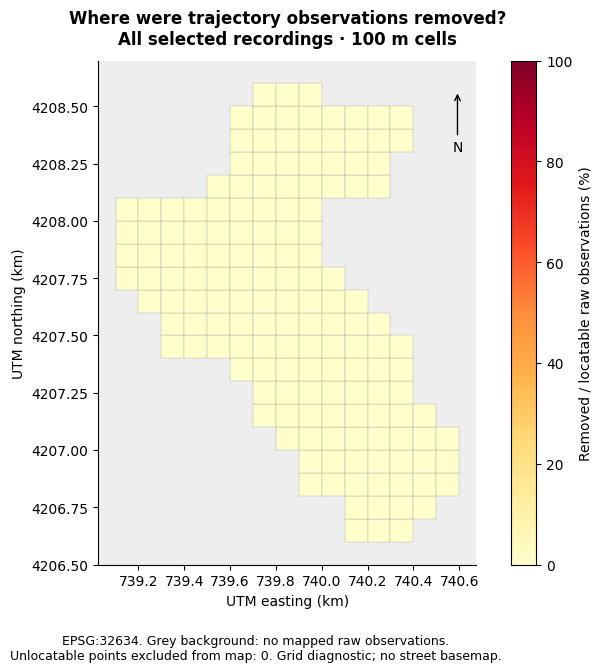

Saved PNG + PDF: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/fig_cleaning_removal_map

CLEANING AND AGGREGATION COMPLETE


stage,unit,before,after,removed
validity_filter,trajectory_points,"975,848,974","975,841,353","7,621"
conflicting_key_removal,trajectory_points,"975,841,353","975,841,353",0
identical_duplicate_removal,trajectory_points,"975,841,353","975,841,353",0



Quality by recording date / Chất lượng theo ngày:


date,raw_points,invalid_points,conflict_points,duplicate_points,retained_points,retained_pct
20181024,"266,242,917","2,579",0,0,"266,240,338",99.999%
20181029,"244,768,900",584,0,0,"244,768,316",100.000%
20181030,"245,742,605","1,186",0,0,"245,741,419",100.000%
20181101,"219,094,552","3,272",0,0,"219,091,280",99.999%



Retained observations: 975,841,353 / 975,848,974 (99.999%)
Panel: 316,008 rows | 154 cells | 199 recordings
Cells meeting the descriptive 200-row threshold: 133. No cells were removed by this threshold.
Quarantined source vehicle rows are reported by the parser, not counted again as removed observations here.
Saved panel: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/data/processed/pneuma.parquet


In [ ]:
# Cleaning and aggregation / Làm sạch và tổng hợp
# Run only after trajectory verification has completed.

import os

if globals().get("IN_COLAB", False):
    os.chdir("/content")

import hashlib
import re
import shutil
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from pyproj import CRS, Transformer
from IPython.display import display


# ============================================================
# 1. Preconditions / Điều kiện chạy
# ============================================================

CLEANING_COMPLETE = False
globals().pop("h_clean", None)

required = [
    "TRAJECTORY_VERIFIED", "VERIFIED_LONG_FILES", "input_files",
    "total_rows", "PANEL_FILE", "REPORT_DIR", "BATCH_SIZE",
    "DUCKDB_MEMORY_LIMIT", "DUCKDB_THREADS",
    "SOURCE_CRS", "GRID_CRS", "GRID_SIZE_M",
    "GRID_ORIGIN_X_M", "GRID_ORIGIN_Y_M",
    "BIN_SECONDS", "MIN_CELL_RECORDS", "MAX_SPEED_KMH",
    "atomic_csv", "save_figure",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run preceding cells first. Missing: {missing}")

if TRAJECTORY_VERIFIED is not True:
    raise RuntimeError("Complete trajectory verification before cleaning.")

INPUT_FILES = [Path(path).resolve() for path in VERIFIED_LONG_FILES]
OUTPUT_FILE = Path(PANEL_FILE)
expected_flights = {Path(path).stem for path in input_files}

if (
    not INPUT_FILES
    or len(INPUT_FILES) != len(expected_flights)
    or len(set(INPUT_FILES)) != len(INPUT_FILES)
    or {path.stem for path in INPUT_FILES} != expected_flights
):
    raise ValueError("Verified partitions do not match the source inventory.")

if GRID_SIZE_M != 100 or BIN_SECONDS != 10:
    raise ValueError("This analysis requires a 100 m grid and 10 s intervals.")

if not isinstance(BATCH_SIZE, int) or BATCH_SIZE <= 0:
    raise ValueError("BATCH_SIZE must be a positive integer.")

if not isinstance(MIN_CELL_RECORDS, int) or MIN_CELL_RECORDS < 1:
    raise ValueError("MIN_CELL_RECORDS must be a positive integer.")

grid_size = float(GRID_SIZE_M)
origin_x = float(GRID_ORIGIN_X_M)
origin_y = float(GRID_ORIGIN_Y_M)

if (
    not np.isfinite([grid_size, origin_x, origin_y, MAX_SPEED_KMH]).all()
    or MAX_SPEED_KMH <= 0
):
    raise ValueError("Invalid grid or speed configuration.")

grid_crs = CRS.from_user_input(GRID_CRS)
if (
    not grid_crs.is_projected
    or len(grid_crs.axis_info) < 2
    or any(
        abs(axis.unit_conversion_factor - 1.0) > 1e-12
        for axis in grid_crs.axis_info[:2]
    )
):
    raise ValueError("GRID_CRS must use projected coordinates in metres.")

to_grid = Transformer.from_crs(SOURCE_CRS, GRID_CRS, always_xy=True)
to_wgs84 = Transformer.from_crs(GRID_CRS, SOURCE_CRS, always_xy=True)

point_schema = pa.schema([
    ("flight", pa.string()),
    ("track_id", pa.string()),
    ("vtype", pa.string()),
    ("lat", pa.float64()),
    ("lon", pa.float64()),
    ("speed_kmh", pa.float64()),
    ("t", pa.float64()),
])
projected_schema = (
    point_schema
    .append(pa.field("grid_x", pa.int64()))
    .append(pa.field("grid_y", pa.int64()))
    .append(pa.field("valid", pa.bool_()))
)

# Disjoint reasons: each invalid point receives its first failing reason.
reason_names = [
    "missing_identifier",
    "missing_vehicle_type",
    "invalid_coordinates",
    "invalid_projection",
    "invalid_time",
    "invalid_speed",
]

memory_limit = str(DUCKDB_MEMORY_LIMIT)
if not re.fullmatch(r"\d+(\.\d+)?\s*(KB|MB|GB|TB)", memory_limit, re.I):
    raise ValueError("Invalid DUCKDB_MEMORY_LIMIT.")

threads = int(DUCKDB_THREADS)
if threads < 1:
    raise ValueError("DUCKDB_THREADS must be positive.")


def sql_literal(value):
    return "'" + str(value).replace("'", "''") + "'"


def checksum(path):
    result = hashlib.sha256()
    with Path(path).open("rb") as reader:
        for block in iter(lambda: reader.read(8 * 1024 * 1024), b""):
            result.update(block)
    return result.hexdigest()


def numeric_array(frame, column):
    return frame[column].to_numpy(dtype=float, na_value=np.nan)


aggregated_parts = []
quality_rows = []
spatial_parts = []
active_file = None
active_stage = "initialization"


try:
    # ========================================================
    # 2. Process one recording at a time / Xử lý từng bản ghi
    # ========================================================

    with tempfile.TemporaryDirectory(prefix="pneuma_cleaning_") as root:
        work_root = Path(root)

        for index, source in enumerate(INPUT_FILES, start=1):
            flight = source.stem
            active_file = source.name
            active_stage = "projection and validity checks"

            print(
                f"[{index}/{len(INPUT_FILES)}] {flight}",
                flush=True,
            )

            # Temporary projected points and SQL tables are removed per file.
            with tempfile.TemporaryDirectory(dir=work_root) as part_dir:
                work = Path(part_dir)
                projected_file = work / "projected.parquet"
                spill = work / "spill"
                spill.mkdir()

                counts = {
                    "flight": flight,
                    "raw_points": 0,
                    "valid_points": 0,
                    "unlocatable_points": 0,
                    "projection_invalid_points": 0,
                    **{name: 0 for name in reason_names},
                }

                with pq.ParquetFile(source) as reader:
                    if not reader.schema_arrow.equals(
                        point_schema, check_metadata=False
                    ):
                        raise ValueError(f"Unexpected schema: {source.name}")

                    with pq.ParquetWriter(
                        projected_file, projected_schema, compression="snappy"
                    ) as writer:
                        for batch in reader.iter_batches(batch_size=BATCH_SIZE):
                            frame = batch.to_pandas()

                            if (
                                frame["flight"].isna().any()
                                or not frame["flight"].eq(flight).all()
                            ):
                                raise ValueError(
                                    f"Incorrect recording identity: {source.name}"
                                )

                            lat = numeric_array(frame, "lat")
                            lon = numeric_array(frame, "lon")
                            speed = numeric_array(frame, "speed_kmh")
                            t = numeric_array(frame, "t")
                            n = len(frame)

                            coordinate_ok = (
                                np.isfinite(lat) & np.isfinite(lon)
                                & (lat >= -90) & (lat <= 90)
                                & (lon >= -180) & (lon <= 180)
                            )

                            x = np.full(n, np.nan)
                            y = np.full(n, np.nan)

                            if coordinate_ok.any():
                                x[coordinate_ok], y[coordinate_ok] = (
                                    to_grid.transform(
                                        lon[coordinate_ok],
                                        lat[coordinate_ok],
                                        errcheck=False,
                                    )
                                )

                            with np.errstate(invalid="ignore", over="ignore"):
                                gx = np.floor((x - origin_x) / grid_size)
                                gy = np.floor((y - origin_y) / grid_size)

                            # Guard integer conversion as well as projection.
                            locatable = (
                                coordinate_ok
                                & np.isfinite(gx) & np.isfinite(gy)
                                & (np.abs(gx) < 9e15)
                                & (np.abs(gy) < 9e15)
                            )

                            identifier_ok = (
                                frame["track_id"].fillna("").str.strip()
                                .ne("").to_numpy()
                            )
                            type_ok = (
                                frame["vtype"].fillna("").str.strip()
                                .ne("").to_numpy()
                            )
                            time_ok = np.isfinite(t) & (t >= 0)
                            speed_ok = (
                                np.isfinite(speed)
                                & (speed >= 0) & (speed < MAX_SPEED_KMH)
                            )

                            tests = [
                                identifier_ok,
                                type_ok,
                                coordinate_ok,
                                locatable,
                                time_ok,
                                speed_ok,
                            ]

                            valid = np.ones(n, dtype=bool)
                            for reason, test in zip(reason_names, tests):
                                failed_here = valid & ~test
                                counts[reason] += int(failed_here.sum())
                                valid &= test

                            counts["raw_points"] += n
                            counts["valid_points"] += int(valid.sum())
                            counts["unlocatable_points"] += int(
                                (~locatable).sum()
                            )
                            counts["projection_invalid_points"] += int(
                                (coordinate_ok & ~locatable).sum()
                            )

                            # Null grid indices exclude unlocatable points
                            # from spatial-rate denominators, not from counts.
                            frame["grid_x"] = pd.array(
                                np.where(locatable, gx, np.nan), dtype="Int64"
                            )
                            frame["grid_y"] = pd.array(
                                np.where(locatable, gy, np.nan), dtype="Int64"
                            )
                            frame["valid"] = valid

                            if shutil.disk_usage(work).free < 512 * 1024**2:
                                raise OSError("Local temporary storage is nearly full.")

                            writer.write_table(pa.Table.from_pandas(
                                frame,
                                schema=projected_schema,
                                preserve_index=False,
                            ))

                # ====================================================
                # 3. Conflicts, duplicates and aggregation / Tổng hợp
                # ====================================================

                active_stage = "duplicate handling and aggregation"

                with duckdb.connect(str(work / "processing.duckdb")) as conn:
                    conn.execute(
                        f"SET memory_limit = {sql_literal(memory_limit)}"
                    )
                    conn.execute(f"SET threads = {threads}")
                    conn.execute(
                        f"SET temp_directory = {sql_literal(spill.as_posix())}"
                    )
                    conn.execute(
                        "CREATE VIEW points AS SELECT * FROM read_parquet("
                        + sql_literal(projected_file.as_posix()) + ")"
                    )

                    # One row for each distinct retained observation.
                    # multiplicity records how many identical rows it represents.
                    conn.execute("""
                        CREATE TABLE variants AS
                        SELECT
                            flight, track_id, t, vtype,
                            lat, lon, speed_kmh, grid_x, grid_y,
                            COUNT(*) AS multiplicity
                        FROM points
                        WHERE valid
                        GROUP BY
                            flight, track_id, t, vtype,
                            lat, lon, speed_kmh, grid_x, grid_y
                    """)

                    conn.execute("""
                        CREATE TABLE key_quality AS
                        SELECT
                            flight, track_id, t,
                            COUNT(*) AS variants,
                            SUM(multiplicity) AS source_points
                        FROM variants
                        GROUP BY flight, track_id, t
                    """)

                    conflict_groups, conflict_points = conn.execute("""
                        SELECT COUNT(*), COALESCE(SUM(source_points), 0)
                        FROM key_quality
                        WHERE variants > 1
                    """).fetchone()

                    # A conflicting key contributes no retained observations.
                    conn.execute("""
                        CREATE TABLE cleaned AS
                        SELECT v.*
                        FROM variants v
                        JOIN key_quality k USING (flight, track_id, t)
                        WHERE k.variants = 1
                    """)

                    kept, duplicates = conn.execute("""
                        SELECT
                            COUNT(*),
                            COALESCE(SUM(multiplicity - 1), 0)
                        FROM cleaned
                    """).fetchone()

                    counts["conflict_groups"] = int(conflict_groups)
                    counts["conflict_points"] = int(conflict_points)
                    counts["duplicate_valid_points"] = int(duplicates)
                    counts["unique_valid_points"] = int(kept)
                    counts["invalid_points"] = (
                        counts["raw_points"] - counts["valid_points"]
                    )

                    if (
                        counts["invalid_points"]
                        != sum(counts[name] for name in reason_names)
                        or counts["valid_points"]
                        != int(conflict_points) + int(duplicates) + int(kept)
                    ):
                        raise ValueError(f"Point accounting failed: {flight}")

                    if kept == 0:
                        raise ValueError(
                            f"{flight}: all observations were removed. "
                            f"Counts: {counts}"
                        )

                    part = conn.execute(f"""
                        SELECT
                            flight, grid_x, grid_y,
                            FLOOR(t / {int(BIN_SECONDS)})
                                * {int(BIN_SECONDS)} AS t10,
                            AVG(speed_kmh) AS speed,
                            COUNT(DISTINCT track_id) AS n_veh,
                            COUNT(*) AS n_obs,
                            AVG(CASE WHEN vtype = 'Motorcycle'
                                THEN 1.0 ELSE 0.0 END) AS share_2w,
                            AVG(CASE WHEN vtype IN (
                                'Bus', 'Heavy Vehicle', 'Medium Vehicle'
                            ) THEN 1.0 ELSE 0.0 END) AS share_heavy
                        FROM cleaned
                        GROUP BY flight, grid_x, grid_y, t10
                    """).df()

                    # Include locatable raw points even if speed/time is invalid.
                    spatial = conn.execute("""
                        WITH raw_counts AS (
                            SELECT grid_x, grid_y, COUNT(*) AS raw_points
                            FROM points
                            WHERE grid_x IS NOT NULL AND grid_y IS NOT NULL
                            GROUP BY grid_x, grid_y
                        ),
                        kept_counts AS (
                            SELECT grid_x, grid_y, COUNT(*) AS retained_points
                            FROM cleaned
                            GROUP BY grid_x, grid_y
                        )
                        SELECT
                            r.grid_x, r.grid_y, r.raw_points,
                            COALESCE(k.retained_points, 0) AS retained_points
                        FROM raw_counts r
                        LEFT JOIN kept_counts k USING (grid_x, grid_y)
                    """).df()

                aggregated_parts.append(part)
                quality_rows.append(counts)
                spatial_parts.append(spatial)

                print(
                    f"  Kept: {kept:,} points | "
                    f"Aggregate rows: {len(part):,}",
                    flush=True,
                )


    # ========================================================
    # 4. Full panel and coverage flags / Bảng đầy đủ và độ phủ
    # ========================================================

    active_file = None
    active_stage = "panel reconciliation"

    raw_cleaning_table = pd.DataFrame(quality_rows)
    if int(raw_cleaning_table["raw_points"].sum()) != int(total_rows):
        raise ValueError("Cleaning input count differs from parser output.")

    h = pd.concat(aggregated_parts, ignore_index=True)
    del aggregated_parts

    if h.empty:
        raise ValueError("The aggregate panel is empty.")

    h["grid_x"] = h["grid_x"].astype("int64")
    h["grid_y"] = h["grid_y"].astype("int64")
    h["cell"] = (
        h["grid_x"].astype(str) + "_" + h["grid_y"].astype(str)
    )
    h["date_block"] = h["flight"].str.extract(
        r"^(\d{8}_d\d+)_", expand=False
    )

    centre_x = origin_x + (h["grid_x"].to_numpy() + 0.5) * grid_size
    centre_y = origin_y + (h["grid_y"].to_numpy() + 0.5) * grid_size
    h["lon"], h["lat"] = to_wgs84.transform(
        centre_x, centre_y, errcheck=True
    )

    coverage = (
        h.groupby("cell").size().rename("aggregate_rows").reset_index()
    )
    coverage["meets_descriptive_threshold"] = (
        coverage["aggregate_rows"] >= MIN_CELL_RECORDS
    )

    # No coverage filter is applied to h.
    # Keep the descriptive flag out of the modelling feature columns.
    h = h[[
        "flight", "cell", "t10",
        "speed", "n_veh", "share_2w", "share_heavy",
        "date_block", "grid_x", "grid_y", "lat", "lon", "n_obs",
    ]].sort_values(["flight", "cell", "t10"]).reset_index(drop=True)

    if h["date_block"].isna().any():
        raise ValueError("Unexpected recording-name structure.")

    if h.duplicated(["flight", "cell", "t10"]).any():
        raise ValueError("Duplicate panel keys.")

    numeric = [
        "t10", "speed", "n_veh", "n_obs", "share_2w", "share_heavy",
        "grid_x", "grid_y", "lat", "lon",
    ]
    if not np.isfinite(h[numeric].to_numpy(dtype=float)).all():
        raise ValueError("Non-finite panel values.")

    if (
        not h["speed"].between(0, MAX_SPEED_KMH, inclusive="left").all()
        or not (h["t10"] >= 0).all()
        or not np.isclose(h["t10"] % BIN_SECONDS, 0).all()
        or not (h["n_veh"] >= 1).all()
        or not (h["n_obs"] >= h["n_veh"]).all()
        or not h["lat"].between(-90, 90).all()
        or not h["lon"].between(-180, 180).all()
    ):
        raise ValueError("Invalid aggregate ranges.")

    for column in ["share_2w", "share_heavy"]:
        if not h[column].between(0, 1).all():
            raise ValueError(f"Invalid composition share: {column}")

    if not (h["share_2w"] + h["share_heavy"] <= 1 + 1e-12).all():
        raise ValueError("Composition shares are inconsistent.")

    if set(h["flight"]) != expected_flights:
        raise ValueError("Some selected recordings are absent from the panel.")

    kept_total = int(raw_cleaning_table["unique_valid_points"].sum())
    if int(h["n_obs"].sum()) != kept_total:
        raise ValueError("Aggregated observation counts do not reconcile.")

    actual_by_flight = h.groupby("flight")["n_obs"].sum().sort_index()
    expected_by_flight = (
        raw_cleaning_table.set_index("flight")["unique_valid_points"]
        .sort_index()
    )
    if not np.array_equal(
        actual_by_flight.to_numpy(), expected_by_flight.to_numpy()
    ):
        raise ValueError("Per-recording aggregate counts do not reconcile.")


    # ========================================================
    # 5. Quality tables / Báo cáo chất lượng
    # ========================================================

    totals = raw_cleaning_table.select_dtypes(include="number").sum()
    raw_total = int(totals["raw_points"])
    valid_total = int(totals["valid_points"])
    conflict_total = int(totals["conflict_points"])
    duplicate_total = int(totals["duplicate_valid_points"])

    cleaning_log = pd.DataFrame([
        {
            "stage": "validity_filter",
            "unit": "trajectory_points",
            "before": raw_total,
            "after": valid_total,
        },
        {
            "stage": "conflicting_key_removal",
            "unit": "trajectory_points",
            "before": valid_total,
            "after": valid_total - conflict_total,
        },
        {
            "stage": "identical_duplicate_removal",
            "unit": "trajectory_points",
            "before": valid_total - conflict_total,
            "after": kept_total,
        },
    ])
    cleaning_log["removed"] = cleaning_log["before"] - cleaning_log["after"]

    spatial_quality = (
        pd.concat(spatial_parts, ignore_index=True)
        .groupby(["grid_x", "grid_y"], as_index=False)[
            ["raw_points", "retained_points"]
        ].sum()
    )
    del spatial_parts

    spatial_quality["removed_points"] = (
        spatial_quality["raw_points"] - spatial_quality["retained_points"]
    )
    spatial_quality["removal_pct"] = (
        100 * spatial_quality["removed_points"] / spatial_quality["raw_points"]
    )

    unlocatable_total = int(totals["unlocatable_points"])

    if (
        int(spatial_quality["raw_points"].sum()) + unlocatable_total
        != raw_total
        or int(spatial_quality["retained_points"].sum()) != kept_total
        or (spatial_quality["removed_points"] < 0).any()
    ):
        raise ValueError("Spatial quality accounting failed.")

    date_quality = (
        raw_cleaning_table
        .assign(date=raw_cleaning_table["flight"].str[:8])
        .groupby("date", as_index=False)
        .agg(
            raw_points=("raw_points", "sum"),
            invalid_points=("invalid_points", "sum"),
            conflict_points=("conflict_points", "sum"),
            duplicate_points=("duplicate_valid_points", "sum"),
            retained_points=("unique_valid_points", "sum"),
        )
    )
    date_quality["retained_pct"] = (
        100 * date_quality["retained_points"] / date_quality["raw_points"]
    )


    # ========================================================
    # 6. Save and verify panel / Lưu và kiểm chứng bảng
    # ========================================================

    active_stage = "panel export"
    OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    staging = OUTPUT_FILE.with_name(OUTPUT_FILE.name + ".uploading")

    with tempfile.TemporaryDirectory(prefix="pneuma_panel_") as panel_dir:
        local_panel = Path(panel_dir) / "panel.parquet"
        h.to_parquet(local_panel, index=False, compression="zstd")
        expected_hash = checksum(local_panel)

        try:
            shutil.copyfile(local_panel, staging)
            if checksum(staging) != expected_hash:
                raise IOError("Panel copy checksum mismatch.")

            saved = pd.read_parquet(staging)
            pd.testing.assert_frame_equal(h, saved, check_exact=True)
            del saved

            os.replace(staging, OUTPUT_FILE)
            if checksum(OUTPUT_FILE) != expected_hash:
                raise IOError("Final panel checksum mismatch.")
        finally:
            try:
                staging.unlink(missing_ok=True)
            except OSError:
                pass

    active_stage = "quality report export"
    atomic_csv(
        raw_cleaning_table,
        Path(REPORT_DIR) / "table_raw_cleaning_by_flight.csv",
    )
    atomic_csv(
        cleaning_log,
        Path(REPORT_DIR) / "table_cleaning_log.csv",
    )
    atomic_csv(
        coverage,
        Path(REPORT_DIR) / "table_cell_coverage.csv",
    )
    atomic_csv(
        spatial_quality,
        Path(REPORT_DIR) / "table_spatial_cleaning.csv",
    )


    # ========================================================
    # 7. Spatial quality figure / Bản đồ chất lượng theo ô
    # ========================================================

    active_stage = "quality figure export"

    x0 = (
        origin_x + spatial_quality["grid_x"].to_numpy() * grid_size
    ) / 1000
    y0 = (
        origin_y + spatial_quality["grid_y"].to_numpy() * grid_size
    ) / 1000
    side = grid_size / 1000

    vertices = np.stack([
        np.column_stack([x0, y0]),
        np.column_stack([x0 + side, y0]),
        np.column_stack([x0 + side, y0 + side]),
        np.column_stack([x0, y0 + side]),
    ], axis=1)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#EEEEEE")

    # Fixed 0–100% scale avoids exaggerating small removal rates.
    collection = PolyCollection(
        vertices,
        array=spatial_quality["removal_pct"].to_numpy(),
        cmap="YlOrRd",
        norm=Normalize(0, 100),
        edgecolors="#888888",
        linewidths=0.2,
    )
    ax.add_collection(collection)
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.set_xlabel("UTM easting (km)")
    ax.set_ylabel("UTM northing (km)")
    ax.ticklabel_format(style="plain", useOffset=False)
    ax.set_title(
        "Where were trajectory observations removed?\n"
        "All selected recordings · 100 m cells",
        pad=12,
    )
    fig.colorbar(
        collection, ax=ax, label="Removed / locatable raw observations (%)"
    )
    ax.annotate(
        "N", xy=(0.95, 0.94), xytext=(0.95, 0.82),
        xycoords="axes fraction", ha="center",
        arrowprops={"arrowstyle": "->", "color": "black"},
    )
    fig.text(
        0.5, 0.025,
        f"{GRID_CRS}. Grey background: no mapped raw observations.\n"
        f"Unlocatable points excluded from map: {unlocatable_total:,}. "
        "Grid diagnostic; no street basemap.",
        ha="center", fontsize=9,
    )
    fig.subplots_adjust(bottom=0.16)
    save_figure(fig, "fig_cleaning_removal_map", tight_layout=False)

    # Publish the handover only after processing and exports complete.
    h_clean = h
    CLEANING_COMPLETE = True

except Exception as exc:
    CLEANING_COMPLETE = False
    globals().pop("h_clean", None)
    print("\nCLEANING STOPPED / LÀM SẠCH CHƯA HOÀN TẤT")
    print("Stage:", active_stage)
    if active_file:
        print("Recording:", active_file)
    print("Error:", str(exc))
    print(
        "Trajectory partitions remain available. "
        "Do not run downstream analysis until this cell completes."
    )
    raise


# ============================================================
# 8. Compact results / Kết quả ngắn gọn
# ============================================================

print("\nCLEANING AND AGGREGATION COMPLETE")

display(
    cleaning_log.style.hide(axis="index").format({
        "before": "{:,}", "after": "{:,}", "removed": "{:,}",
    })
)

print("\nQuality by recording date / Chất lượng theo ngày:")
display(
    date_quality.style.hide(axis="index").format({
        "raw_points": "{:,}",
        "invalid_points": "{:,}",
        "conflict_points": "{:,}",
        "duplicate_points": "{:,}",
        "retained_points": "{:,}",
        "retained_pct": "{:.3f}%",
    })
)

print(
    f"\nRetained observations: {kept_total:,} / {raw_total:,} "
    f"({100 * kept_total / raw_total:.3f}%)"
)
print(
    f"Panel: {len(h_clean):,} rows | "
    f"{h_clean['cell'].nunique():,} cells | "
    f"{h_clean['flight'].nunique():,} recordings"
)
print(
    f"Cells meeting the descriptive {MIN_CELL_RECORDS}-row threshold: "
    f"{int(coverage['meets_descriptive_threshold'].sum()):,}. "
    "No cells were removed by this threshold."
)
print(
    "Quarantined source vehicle rows are reported by the parser, "
    "not counted again as removed observations here."
)
print("Saved panel:", OUTPUT_FILE)

### 9. Descriptive statistics and temporal completeness (Thống kê mô tả và mức độ đầy đủ theo thời gian)

This step describes `h_clean` without changing its contents. Each row represents one recording, one grid cell and one observed 10-second interval. The full panel is included, including cells below the descriptive coverage threshold.

(Bước này mô tả `h_clean` mà không thay đổi dữ liệu. Mỗi dòng tương ứng một lần ghi hình, một ô lưới và một khoảng 10 giây có quan sát. Phân tích sử dụng bảng đầy đủ, gồm cả các ô chưa đạt ngưỡng độ phủ mô tả.)

**Distributions and weighting (Phân bố và trọng số)**

The main summaries describe `speed`, `n_veh`, `n_obs`, `share_2w` and `share_heavy`, using observation counts, means, standard deviations, selected quantiles and ranges. Recording and cell identifiers are summarised as coverage counts rather than numerical measurements.

(Các thống kê chính mô tả `speed`, `n_veh`, `n_obs`, `share_2w` và `share_heavy`, gồm số giá trị, trung bình, độ lệch chuẩn, các phân vị được chọn và khoảng giá trị. Mã lần ghi hình và mã ô được tổng hợp theo số lượng bao phủ, không xem như đại lượng đo.)

Each aggregate row receives equal weight in these summaries. Therefore, the mean of `speed` describes the average across observed recording–cell–interval rows, not an equally weighted average across vehicles, cells or recording dates. Within each row, speed and composition remain observation-weighted.

(Mỗi dòng tổng hợp có trọng số bằng nhau trong các thống kê này. Vì vậy, trung bình của `speed` là trung bình trên các dòng lần ghi hình–ô–khoảng thời gian có quan sát, không phải trung bình cho mỗi xe, mỗi ô hoặc mỗi ngày trọng số bằng nhau. Bên trong từng dòng, tốc độ và thành phần xe vẫn được tính theo điểm quan sát.)

**Missing values and absent intervals (Giá trị thiếu và khoảng thời gian vắng)**

Missing values are empty entries within existing rows. Internal time gaps are absent 10-second slots between the first and last observed intervals of a recording–cell series. These are measured separately.

(Giá trị thiếu là ô dữ liệu trống trong những dòng đang tồn tại. Khoảng trống thời gian nội bộ là các mốc 10 giây vắng giữa khoảng đầu và cuối có quan sát của một chuỗi lần ghi hình–ô. Hai dạng này được thống kê riêng.)

Time labels and key uniqueness are checked before calculating gaps. For each series, the internal gap rate is the number of absent slots divided by all expected slots between its observed endpoints, including both endpoints. Series containing only one observed interval are identified separately because they provide no evidence about continuity.

(Nhãn thời gian và tính duy nhất của khóa được kiểm tra trước khi tính khoảng trống. Với mỗi chuỗi, tỷ lệ khoảng trống nội bộ bằng số mốc vắng chia cho tổng số mốc kỳ vọng giữa hai đầu quan sát, tính cả hai đầu. Chuỗi chỉ có một khoảng quan sát được ghi nhận riêng vì chưa cung cấp bằng chứng về tính liên tục.)

This measure excludes time outside the observed endpoints and series that are entirely absent. An absent interval does not establish sensor failure or zero traffic. Its implications for historical features and future targets are examined during feature construction.

(Chỉ số này không đo phần thời gian ngoài hai đầu quan sát hoặc chuỗi hoàn toàn không xuất hiện. Khoảng vắng chưa chứng minh lỗi cảm biến hoặc giao thông bằng không. Ảnh hưởng đến đặc trưng lịch sử và nhãn tương lai được kiểm tra ở bước tạo đặc trưng.)

**Reader-facing outputs (Đầu ra dành cho người đọc)**

- A compact distribution table for the five traffic variables.
- A missing-value summary; if all fields are complete, a short confirmation replaces an empty chart.
- A temporal-completeness summary showing internal absent slots, affected series and single-interval series. An overall gap rate uses the summed absent slots divided by the summed expected slots.

- Bảng phân bố ngắn gọn cho năm biến giao thông.
- Tổng hợp giá trị thiếu; nếu mọi trường đều đầy đủ, dùng thông báo ngắn thay cho biểu đồ không có thông tin.
- Tổng hợp mức độ đầy đủ theo thời gian, gồm số mốc vắng nội bộ, số chuỗi bị ảnh hưởng và số chuỗi chỉ có một khoảng quan sát. Tỷ lệ khoảng trống chung được tính bằng tổng số mốc vắng chia cho tổng số mốc kỳ vọng.

Constant or strongly skewed variables are flagged for interpretation, not automatically removed or transformed. No interpolation, imputation, row insertion or deletion is performed.

(Biến hằng hoặc lệch mạnh được đánh dấu để diễn giải, không tự động loại bỏ hay biến đổi. Bước này không nội suy, điền thiếu, thêm dòng hoặc xóa dữ liệu.)

In [ ]:
# Descriptive statistics and temporal completeness
# Thống kê mô tả và mức độ đầy đủ theo thời gian
# Không thay đổi giá trị, kiểu dữ liệu hoặc metadata của h_clean.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# 1. Validate inputs / Kiểm tra đầu vào
# ============================================================

EDA_COMPLETE = False

required = [
    "h_clean", "CLEANING_COMPLETE", "REPORT_DIR",
    "BIN_SECONDS", "atomic_csv",
]
missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        f"Run preceding cells first. Missing: {missing}"
    )

if CLEANING_COMPLETE is not True:
    raise RuntimeError(
        "Cleaning and aggregation must complete before EDA."
    )

if not isinstance(h_clean, pd.DataFrame) or h_clean.empty:
    raise ValueError("h_clean must be a non-empty DataFrame.")

if not h_clean.columns.is_unique:
    raise ValueError("Duplicate column names in h_clean.")

# Independent copies prevent report formatting from changing h_clean.
source_snapshot = h_clean.copy(deep=True)
eda = h_clean.copy(deep=True)
eda.columns = eda.columns.copy(deep=True).rename(None)
eda.index = eda.index.copy(deep=True).rename(None)

keys = ["flight", "cell", "t10"]
traffic_columns = [
    "speed", "n_veh", "n_obs", "share_2w", "share_heavy"
]

missing_columns = set(keys + traffic_columns) - set(eda.columns)
if missing_columns:
    raise ValueError(
        f"Missing columns: {sorted(missing_columns)}"
    )

if eda[keys].isna().any().any():
    raise ValueError(
        "Recording–cell–time keys contain missing values."
    )

if eda.duplicated(keys).any():
    raise ValueError("Duplicate recording–cell–time keys.")

step = float(BIN_SECONDS)
if not np.isfinite(step) or step <= 0:
    raise ValueError("BIN_SECONDS must be finite and positive.")

for column in traffic_columns + ["t10"]:
    if not pd.api.types.is_numeric_dtype(eda[column]):
        raise ValueError(f"{column} must be numeric.")

# Missing entries are reported below; infinities require review.
for column in traffic_columns:
    values = eda[column].to_numpy(
        dtype=float, na_value=np.nan
    )
    if np.isinf(values).any():
        raise ValueError(
            f"{column} contains infinity. Review the cleaning output."
        )

time_values = eda["t10"].to_numpy(
    dtype=float, na_value=np.nan
)

if not np.isfinite(time_values).all() or (time_values < 0).any():
    raise ValueError(
        "t10 must contain finite, non-negative times."
    )

tick_values = time_values / step
rounded_ticks = np.rint(tick_values)

if (
    not np.isfinite(tick_values).all()
    or not np.isclose(
        tick_values,
        rounded_ticks,
        rtol=0,
        atol=1e-8,
    ).all()
):
    raise ValueError(
        "Some t10 values do not match the configured time grid."
    )

if (rounded_ticks >= 2**53 - 1).any():
    raise ValueError(
        "Time indices are too large for exact interval checks."
    )

report_dir = Path(REPORT_DIR)
report_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Five traffic variables / Năm biến giao thông
# ============================================================

numeric = eda[traffic_columns]

desc_num = numeric.describe(
    percentiles=[0.25, 0.50, 0.75, 0.95]
).T

desc_num["skew"] = numeric.skew()
desc_num["distinct_values"] = numeric.nunique(dropna=True)

units = {
    "speed": "km/h",
    "n_veh": "distinct tracks per interval",
    "n_obs": "trajectory points per interval",
    "share_2w": "proportion [0, 1]",
    "share_heavy": "proportion [0, 1]",
}
desc_num.insert(0, "unit", pd.Series(units))

review_notes = []

for column in traffic_columns:
    notes = []
    distinct = int(desc_num.loc[column, "distinct_values"])
    missing_count = int(numeric[column].isna().sum())
    skew = desc_num.loc[column, "skew"]

    if distinct == 0:
        notes.append("all values missing")
    elif distinct == 1:
        notes.append("constant among non-missing values")

    if missing_count:
        notes.append(f"{missing_count:,} missing values")

    if pd.notna(skew) and abs(skew) > 2:
        notes.append("|skew| > 2; review distribution")

    review_notes.append(
        "; ".join(notes) if notes else "No flag"
    )

desc_num["review_note"] = review_notes

# Rename an independent index, never a shared source axis.
desc_num.index = (
    desc_num.index.copy(deep=True).rename("variable")
)


# ============================================================
# 3. Missing values / Giá trị thiếu trong các dòng hiện có
# ============================================================

miss = pd.DataFrame({
    "dtype": eda.dtypes.astype(str),
    "non_missing_count": eda.notna().sum(),
    "missing_count": eda.isna().sum(),
})

miss["missing_rate"] = miss["missing_count"] / len(eda)
miss.index = miss.index.copy(deep=True).rename("column")
miss = miss.sort_values(
    ["missing_count"],
    ascending=False,
    kind="stable",
)


# ============================================================
# 4. Internal gaps / Khoảng trống thời gian nội bộ
# ============================================================

ordered = eda[keys].copy()
ordered["tick"] = pd.array(
    rounded_ticks.astype("int64"),
    dtype="Int64",
)

if ordered.duplicated(["flight", "cell", "tick"]).any():
    raise ValueError(
        "Multiple rows map to the same time slot."
    )

ordered = ordered.sort_values(
    ["flight", "cell", "tick"]
).reset_index(drop=True)

group_keys = ["flight", "cell"]
groups = ordered.groupby(group_keys, sort=False)

# Preserve integer arithmetic when the first previous value is missing.
ordered["previous_tick"] = (
    groups["tick"].shift().astype("Int64")
)
ordered["delta_ticks"] = (
    ordered["tick"].astype("Int64")
    - ordered["previous_tick"]
)

gap_mask = ordered["delta_ticks"].gt(1).fillna(False)

gap_rows = ordered.loc[
    gap_mask,
    group_keys + ["previous_tick", "tick", "delta_ticks"],
].copy()

gaps = gap_rows[group_keys].copy()

gaps["previous_observed_t10"] = (
    gap_rows["previous_tick"].astype("int64") * step
)
gaps["next_observed_t10"] = gap_rows["tick"] * step
gaps["missing_slots"] = (
    gap_rows["delta_ticks"].astype("int64") - 1
)
gaps["first_missing_t10"] = (
    gaps["previous_observed_t10"] + step
)
gaps["last_missing_t10"] = (
    gaps["next_observed_t10"] - step
)

# Observed at 120 and 150:
# missing labels are 130 and 140 -> 2 slots -> 20 missing seconds.
gaps["missing_duration_seconds"] = (
    gaps["missing_slots"] * step
)
gaps["observed_label_separation_seconds"] = (
    gaps["next_observed_t10"]
    - gaps["previous_observed_t10"]
)
gaps = gaps.reset_index(drop=True)

gap_summary = (
    ordered.groupby(group_keys)
    .agg(
        observed_rows=("tick", "size"),
        first_tick=("tick", "min"),
        last_tick=("tick", "max"),
    )
)

gap_summary["expected_slots_within_span"] = (
    gap_summary["last_tick"]
    - gap_summary["first_tick"]
    + 1
)
gap_summary["missing_slots"] = (
    gap_summary["expected_slots_within_span"]
    - gap_summary["observed_rows"]
)
gap_summary["single_interval_series"] = (
    gap_summary["observed_rows"] == 1
)
gap_summary["first_t10"] = (
    gap_summary["first_tick"] * step
)
gap_summary["last_t10"] = (
    gap_summary["last_tick"] * step
)

gap_counts = gaps.groupby(group_keys).size()
gap_totals = gaps.groupby(group_keys)["missing_slots"].sum()

gap_summary["internal_gaps"] = (
    gap_counts.reindex(
        gap_summary.index, fill_value=0
    ).astype("int64")
)

# Reconcile both counting methods for every series.
counted_missing = (
    gap_totals.reindex(
        gap_summary.index, fill_value=0
    ).astype("int64")
)

if not np.array_equal(
    counted_missing.to_numpy(),
    gap_summary["missing_slots"].to_numpy(),
):
    raise ValueError(
        "Internal gap counts disagree between counting methods."
    )

if (gap_summary["missing_slots"] < 0).any():
    raise ValueError("Negative missing-slot count.")

gap_summary["internal_gap_rate"] = (
    gap_summary["missing_slots"]
    / gap_summary["expected_slots_within_span"]
)
gap_summary["observed_fraction_within_span"] = (
    gap_summary["observed_rows"]
    / gap_summary["expected_slots_within_span"]
)

gap_summary = gap_summary.drop(
    columns=["first_tick", "last_tick"]
).reset_index()

observed_total = int(gap_summary["observed_rows"].sum())
expected_total = int(
    gap_summary["expected_slots_within_span"].sum()
)
absent_total = int(gap_summary["missing_slots"].sum())

if (
    observed_total != len(eda)
    or expected_total != observed_total + absent_total
):
    raise ValueError(
        "Observed and absent interval counts do not reconcile."
    )

overall_gap_rate = absent_total / expected_total
affected_series = int(
    (gap_summary["missing_slots"] > 0).sum()
)
single_series = int(
    gap_summary["single_interval_series"].sum()
)

gap_by_date = (
    gap_summary.assign(date=gap_summary["flight"].str[:8])
    .groupby("date", as_index=False)
    .agg(
        series=("cell", "size"),
        single_interval_series=("single_interval_series", "sum"),
        observed_slots=("observed_rows", "sum"),
        expected_slots=("expected_slots_within_span", "sum"),
        absent_slots=("missing_slots", "sum"),
    )
)
gap_by_date["internal_gap_pct"] = (
    100
    * gap_by_date["absent_slots"]
    / gap_by_date["expected_slots"]
)


# ============================================================
# 5. Verify source preservation and save four reports
# Kiểm tra bảng nguồn không đổi và lưu bốn báo cáo
# ============================================================

pd.testing.assert_frame_equal(
    h_clean,
    source_snapshot,
    check_exact=True,
)

atomic_csv(
    desc_num.reset_index(),
    report_dir / "table_describe_numeric.csv",
)
atomic_csv(
    miss.reset_index(),
    report_dir / "table_missing.csv",
)
atomic_csv(
    gaps,
    report_dir / "table_time_gaps.csv",
)
atomic_csv(
    gap_summary,
    report_dir / "table_time_gap_summary.csv",
)


# ============================================================
# 6. Reader-facing output / Kết quả hiển thị
# ============================================================

def show_eda(frame, formats=None):
    """Format a separate display copy without requiring Jinja2."""
    shown = frame.copy(deep=True)

    for column, spec in (formats or {}).items():
        shown[column] = shown[column].map(
            lambda value: (
                "Not available"
                if pd.isna(value)
                else spec.format(value)
            )
        )

    display(shown)


print(
    f"DESCRIPTIVE SUMMARY | {len(eda):,} aggregate rows | "
    f"{eda['flight'].nunique():,} recordings | "
    f"{eda['cell'].nunique():,} cells"
)
print("Each aggregate row receives equal weight.")

shown_columns = [
    "unit", "count", "mean", "std", "min",
    "25%", "50%", "75%", "95%", "max",
]
formats = {
    name: "{:,.3f}"
    for name in shown_columns
    if name not in {"unit", "count"}
}
formats["Non-missing rows"] = "{:,.0f}"

show_eda(
    desc_num[shown_columns].rename(
        columns={"count": "Non-missing rows"}
    ),
    formats,
)

flagged = desc_num.loc[
    desc_num["review_note"] != "No flag",
    ["skew", "review_note"],
]
if not flagged.empty:
    print("\nReview flags / Dấu hiệu cần diễn giải:")
    show_eda(flagged, {"skew": "{:.3f}"})

missing_fields = miss.loc[miss["missing_count"] > 0]

print("\nMISSING VALUES / GIÁ TRỊ THIẾU")
if missing_fields.empty:
    print(
        "No missing entries in existing rows; "
        "time coverage is assessed separately."
    )
else:
    show_eda(
        missing_fields[["missing_count", "missing_rate"]],
        {
            "missing_count": "{:,}",
            "missing_rate": "{:.3%}",
        },
    )

print("\nINTERNAL TIME GAPS / KHOẢNG TRỐNG THỜI GIAN NỘI BỘ")
print(
    f"Series: {len(gap_summary):,} | "
    f"With gaps: {affected_series:,} | "
    f"Single-interval series: {single_series:,}"
)
print(
    f"Absent slots: {absent_total:,} / {expected_total:,} "
    f"({overall_gap_rate:.3%})"
)

show_eda(
    gap_by_date,
    {
        **{
            name: "{:,}"
            for name in [
                "series",
                "single_interval_series",
                "observed_slots",
                "expected_slots",
                "absent_slots",
            ]
        },
        "internal_gap_pct": "{:.3f}%",
    },
)

if not gaps.empty:
    print("\nFive longest internal gaps / Năm khoảng vắng dài nhất:")

    longest = (
        gaps.sort_values(
            ["missing_slots", "flight", "cell"],
            ascending=[False, True, True],
        )
        .head(5)[[
            "flight",
            "cell",
            "first_missing_t10",
            "last_missing_t10",
            "missing_slots",
            "missing_duration_seconds",
        ]]
        .reset_index(drop=True)
    )

    show_eda(
        longest,
        {
            "first_missing_t10": "{:,.1f}",
            "last_missing_t10": "{:,.1f}",
            "missing_slots": "{:,}",
            "missing_duration_seconds": "{:,.1f}",
        },
    )

print("\nSingle-interval series do not establish continuity.")
print(
    "Absent slots combine recording-cell series, "
    "not study-wide missing duration."
)
print("Reports:", report_dir)
print("h_clean values, dtypes and axis metadata were preserved.")

EDA_COMPLETE = True

del source_snapshot, eda

DESCRIPTIVE SUMMARY | 316,008 aggregate rows | 199 recordings | 154 cells
Each aggregate row receives equal weight.


,unit,Non-missing rows,mean,std,min,25%,50%,75%,95%,max
variable,,,,,,,,,,
speed,km/h,"316,008",15.583,10.604,0.000,7.597,13.486,22.026,35.558,125.912
n_veh,distinct tracks per interval,"316,008",19.395,17.178,1.000,6.000,15.000,28.000,54.000,136.000
n_obs,trajectory points per interval,"316,008","3,088.027","3,318.810",1.000,570.000,"1,954.000","4,506.000","9,951.000","36,405.000"
share_2w,"proportion [0, 1]","316,008",0.261,0.219,0.000,0.106,0.234,0.361,0.675,1.000
share_heavy,"proportion [0, 1]","316,008",0.113,0.161,0.000,0.000,0.072,0.152,0.387,1.000



Review flags / Dấu hiệu cần diễn giải:


,skew,review_note
variable,,
share_heavy,3.014,|skew| > 2; review distribution



MISSING VALUES / GIÁ TRỊ THIẾU
No missing entries in existing rows; time coverage is assessed separately.

INTERNAL TIME GAPS / KHOẢNG TRỐNG THỜI GIAN NỘI BỘ
Series: 4,196 | With gaps: 1,502 | Single-interval series: 63
Absent slots: 31,407 / 347,415 (9.040%)


,date,series,single_interval_series,observed_slots,expected_slots,absent_slots,internal_gap_pct
0,20181024,"1,057",18,"77,762","84,989","7,227",8.503%
1,20181029,"1,056",10,"79,515","87,316","7,801",8.934%
2,20181030,"1,032",19,"78,872","85,866","6,994",8.145%
3,20181101,"1,051",16,"79,859","89,244","9,385",10.516%



Five longest internal gaps / Năm khoảng vắng dài nhất:


,flight,cell,first_missing_t10,last_missing_t10,missing_slots,missing_duration_seconds
0,20181024_d1_1000_1030,7405_42070,60.0,930.0,88,880.0
1,20181029_d5_0930_1000,7394_42075,40.0,870.0,84,840.0
2,20181101_d1_0830_0900,7403_42068,130.0,810.0,69,690.0
3,20181024_d1_1000_1030,7405_42069,260.0,890.0,64,640.0
4,20181024_d1_0930_1000,7401_42070,150.0,760.0,62,620.0



Single-interval series do not establish continuity.
Absent slots combine recording-cell series, not study-wide missing duration.
Reports: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report
h_clean values, dtypes and axis metadata were preserved.


### 10. Column roles (Vai trò các biến)

The panel separates sequence identifiers, current traffic measurements and spatial metadata. These roles guide subsequent analysis and feature construction; they do not automatically select model inputs.

(Bảng dữ liệu phân biệt mã định danh chuỗi, các đại lượng giao thông hiện tại và thông tin không gian. Vai trò này định hướng phân tích và tạo đặc trưng, không tự động quyết định đầu vào mô hình.)

Current traffic measurements summarise observations within `[t10, t10 + BIN_SECONDS)`. They are available for forecasting only after that interval ends. Future targets are constructed separately using exact time offsets.

(Các đại lượng giao thông hiện tại tổng hợp quan sát trong khoảng `[t10, t10 + BIN_SECONDS)`. Chỉ sử dụng chúng để dự báo sau khi khoảng đó kết thúc. Nhãn tương lai được tạo riêng theo độ dịch thời gian chính xác.)

`n_obs` records the number of retained trajectory points contributing to each aggregate row. It supports quality checks and interpretation of observation weighting; it is not automatically added to the model predictors.

(`n_obs` ghi số điểm quỹ đạo được giữ lại đóng góp vào mỗi dòng tổng hợp. Biến này hỗ trợ kiểm tra chất lượng và diễn giải trọng số quan sát, không tự động được thêm vào đầu vào mô hình.)

Associations between traffic variables, including Pearson and Spearman correlations, are examined together in RQ1 with their sample scope and limitations. No columns are removed or transformed here.

(Liên hệ giữa các biến giao thông, gồm tương quan Pearson và Spearman, được phân tích cùng nhau tại RQ1, kèm phạm vi mẫu và giới hạn diễn giải. Bước này không xóa hoặc biến đổi cột.)

In [ ]:
# Column roles / Vai trò các biến
# Document roles without changing h_clean or selecting model inputs.

from pathlib import Path

import pandas as pd
from IPython.display import display


# 1. Check the handover / Kiểm tra dữ liệu bàn giao
if globals().get("CLEANING_COMPLETE") is not True:
    raise RuntimeError(
        "Complete cleaning and aggregation before documenting column roles."
    )

if (
    "h_clean" not in globals()
    or not isinstance(h_clean, pd.DataFrame)
    or h_clean.empty
):
    raise ValueError("A non-empty h_clean DataFrame is required.")

if not h_clean.columns.is_unique:
    raise ValueError("h_clean contains duplicate column names.")

if "REPORT_DIR" not in globals() or "atomic_csv" not in globals():
    raise RuntimeError("Run the preceding configuration and helper cells.")


# 2. Explicit roles / Khai báo vai trò
roles = {
    "flight": (
        "Sequence key",
        "Recording identifier",
        "Groups observations by recording; not a default model input.",
    ),
    "cell": (
        "Sequence key",
        "Projected grid-cell identifier",
        "Groups spatial sequences; does not encode latitude/longitude.",
    ),
    "t10": (
        "Time alignment",
        "Interval start, recording-relative seconds",
        "Aligns history and targets; is not clock time.",
    ),
    "speed": (
        "Current traffic measurement",
        "Observation-weighted mean speed, km/h",
        "Candidate input after interval end; future targets are separate.",
    ),
    "n_veh": (
        "Current traffic measurement",
        "Distinct track identifiers within the interval and cell",
        "Candidate input; not a direct density or flow measurement.",
    ),
    "n_obs": (
        "Observation support",
        "Retained trajectory points contributing to the aggregate",
        "Quality and weighting checks; not a default model input.",
    ),
    "share_2w": (
        "Current traffic measurement",
        "Motorcycle observation share, proportion from 0 to 1",
        "Candidate input; excludes bicycles and is not vehicle-weighted.",
    ),
    "share_heavy": (
        "Current traffic measurement",
        "Bus, Heavy Vehicle and Medium Vehicle observation share",
        "Candidate input; proportion from 0 to 1, not vehicle-weighted.",
    ),
    "date_block": (
        "Grouping metadata",
        "Recording date and drone identifier",
        "Supports grouped summaries; not a default model input.",
    ),
    "grid_x": (
        "Spatial metadata",
        "Integer easting index of the projected grid",
        "Locates cells; not a default model input.",
    ),
    "grid_y": (
        "Spatial metadata",
        "Integer northing index of the projected grid",
        "Locates cells; not a default model input.",
    ),
    "lat": (
        "Spatial metadata",
        "WGS 84 latitude of the cell centre",
        "Mapping; does not represent an individual vehicle position.",
    ),
    "lon": (
        "Spatial metadata",
        "WGS 84 longitude of the cell centre",
        "Mapping; does not represent an individual vehicle position.",
    ),
}

missing_columns = set(roles) - set(h_clean.columns)
if missing_columns:
    raise ValueError(
        "The current panel is missing expected columns: "
        f"{sorted(missing_columns)}"
    )

column_table = pd.DataFrame([
    {
        "column": column,
        "role": roles.get(
            column,
            ("Unspecified", "", ""),
        )[0],
        "meaning": roles.get(
            column,
            ("", "Additional column", ""),
        )[1],
        "use": roles.get(
            column,
            ("", "", "Review before analysis or modelling."),
        )[2],
    }
    for column in h_clean.columns
])


# 3. Save the full dictionary / Lưu từ điển biến đầy đủ
report_dir = Path(REPORT_DIR)
report_dir.mkdir(parents=True, exist_ok=True)

column_report = report_dir / "table_columns.csv"
atomic_csv(column_table, column_report)


# 4. Compact display / Hiển thị ngắn gọn
role_summary = pd.DataFrame([
    {
        "Role / Vai trò": "Sequence keys and time alignment / Khóa và thời gian",
        "Columns / Biến": "flight, cell, t10",
    },
    {
        "Role / Vai trò": "Current traffic measurements / Giao thông hiện tại",
        "Columns / Biến": "speed, n_veh, share_2w, share_heavy",
    },
    {
        "Role / Vai trò": "Observation support / Số điểm đóng góp",
        "Columns / Biến": "n_obs",
    },
    {
        "Role / Vai trò": "Grouping metadata / Thông tin nhóm",
        "Columns / Biến": "date_block",
    },
    {
        "Role / Vai trò": "Spatial metadata / Thông tin không gian",
        "Columns / Biến": "grid_x, grid_y, lat, lon",
    },
])

display(role_summary)

unspecified = column_table.loc[
    column_table["role"] == "Unspecified"
]
if not unspecified.empty:
    print("Additional columns requiring role review:")
    display(unspecified)

print("Full column dictionary:", column_report)
print(
    "Current traffic measurements are available only after "
    "the current interval ends."
)
print("No columns were changed and no model inputs were selected.")

,Role / Vai trò,Columns / Biến
0,Sequence keys and time alignment / Khóa và thờ...,"flight, cell, t10"
1,Current traffic measurements / Giao thông hiện...,"speed, n_veh, share_2w, share_heavy"
2,Observation support / Số điểm đóng góp,n_obs
3,Grouping metadata / Thông tin nhóm,date_block
4,Spatial metadata / Thông tin không gian,"grid_x, grid_y, lat, lon"


Full column dictionary: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/table_columns.csv
Current traffic measurements are available only after the current interval ends.
No columns were changed and no model inputs were selected.


### 11. Exact-time features and targets (Đặc trưng và nhãn đúng mốc thời gian)

Features and targets are constructed within each `(flight, cell)` series. Exact-time joins preserve every panel row; unavailable historical values and future targets remain missing.

(Đặc trưng và nhãn được tạo riêng trong từng chuỗi `(flight, cell)`. Phép ghép đúng thời gian giữ nguyên mọi dòng của bảng tổng hợp; giá trị quá khứ và nhãn tương lai không có dữ liệu được giữ thiếu.)

**Prediction timing (Thời điểm dự báo)**

A row labelled `t10 = t` summarises `[t, t + 10)`. Predictions using that row are issued after the interval ends, at `t + 10`, assuming no additional processing delay.

(Dòng có nhãn `t10 = t` tổng hợp khoảng `[t, t + 10)`. Dự báo sử dụng dòng đó được phát sau khi khoảng kết thúc, tại `t + 10`, với giả định không có độ trễ xử lý bổ sung.)

| Quantity / Đại lượng | Definition / Định nghĩa | Example with `t = 120` / Ví dụ |
|---|---|---|
| Prediction issue time / Thời điểm phát dự báo | `t + 10` | `130 s` |
| `y_30s` | Mean speed in `[t + 30, t + 40)` / Tốc độ trung bình trong khoảng này | `[150, 160)` |
| `y_60s` | Mean speed in `[t + 60, t + 70)` / Tốc độ trung bình trong khoảng này | `[180, 190)` |
| Future warning window / Cửa sổ cảnh báo | Six intervals covering `[t + 10, t + 70)` / Sáu khoảng liên tiếp | `[130, 190)` |

The speed-target names indicate offsets between interval labels, equivalently the time from prediction issuance to the target interval’s end. They do not represent average speed over the entire next 30 or 60 seconds.

(Tên nhãn tốc độ biểu diễn độ lệch giữa nhãn các khoảng, cũng tương ứng thời gian từ lúc phát dự báo đến cuối khoảng đích. Chúng không biểu diễn tốc độ trung bình trên toàn bộ 30 hoặc 60 giây tiếp theo.)

**Historical features (Đặc trưng lịch sử)**

- `s_lag1`, `s_lag3`: speed at interval labels `t − 10` and `t − 30`.
- `n_lag1`: distinct vehicle count at `t − 10`.
- `s_ma1m`, `n_ma1m`: equal-weight means across available interval labels from `t − 50` through `t`.
- `history_count`: number of available intervals in that window, from 1 to 6.

- `s_lag1`, `s_lag3`: tốc độ ở các nhãn khoảng `t − 10` và `t − 30`.
- `n_lag1`: số mã xe phân biệt ở nhãn khoảng `t − 10`.
- `s_ma1m`, `n_ma1m`: trung bình có trọng số bằng nhau trên các nhãn khoảng hiện có từ `t − 50` đến `t`.
- `history_count`: số khoảng hiện có trong cửa sổ, từ 1 đến 6.

A rolling mean based on fewer than six intervals is a partial-history summary. `history_count` records this distinction for subsequent eligibility checks; no missing interval is filled.

(Trung bình trượt từ ít hơn sáu khoảng là thống kê trên lịch sử chưa đầy đủ. `history_count` ghi nhận sự khác biệt này để kiểm tra điều kiện chọn mẫu phía sau; không điền dữ liệu cho khoảng vắng.)

**Future low-speed label (Nhãn tốc độ thấp tương lai)**

`y_cong_60s` is defined only when all six future intervals are available. It equals 1 if any interval has mean speed below `CONGESTION_SPEED_THRESHOLD`, and 0 otherwise. An incomplete future window produces a missing label.

(`y_cong_60s` chỉ được xác định khi có đủ sáu khoảng tương lai. Nhãn bằng 1 nếu ít nhất một khoảng có tốc độ trung bình dưới `CONGESTION_SPEED_THRESHOLD`, ngược lại bằng 0. Cửa sổ tương lai không đầy đủ tạo nhãn thiếu.)

This label describes a future low-speed event, not confirmed congestion. Onset-oriented warning evaluation additionally requires the current interval to be above or equal to the threshold.

(Nhãn này mô tả sự kiện tốc độ thấp tương lai, chưa xác nhận ùn tắc. Đánh giá cảnh báo theo hướng khởi phát còn yêu cầu tốc độ khoảng hiện tại lớn hơn hoặc bằng ngưỡng.)

**Output and safeguards (Đầu ra và kiểm tra)**

The SQL table `feat` retains spatial metadata and `n_obs`, adds historical features and future labels, and preserves the panel’s keys and row count. A compact report shows history and target availability. These counts precede model eligibility and train/test splitting.

(Bảng SQL `feat` giữ thông tin không gian và `n_obs`, bổ sung đặc trưng lịch sử cùng nhãn tương lai, đồng thời bảo toàn khóa và số dòng đầu vào. Báo cáo ngắn thể hiện độ sẵn có của lịch sử và nhãn. Những số lượng này được tính trước bước chọn mẫu mô hình và chia train/test.)

Future labels must never enter predictor columns. Separate temporal audits follow before export to Notebook 02.

(Nhãn tương lai không được đưa vào cột dự báo đầu vào. Bước kiểm chứng thời gian riêng được thực hiện tiếp theo trước khi xuất dữ liệu cho Notebook 02.)

In [ ]:
# Exact-time features and future targets
# Đặc trưng và nhãn tương lai theo đúng mốc thời gian

from pathlib import Path
import re

import numpy as np
import pandas as pd
import duckdb
from IPython.display import display


# 1. Preconditions / Điều kiện chạy
FEATURES_COMPLETE = False
TEMPORAL_AUDIT_VERIFIED = False
TARGET_TIMING_VERIFIED = False
HANDOVER_COMPLETE = False

required = [
    "h_clean", "CLEANING_COMPLETE",
    "PANEL_FILE", "SQL_DIR", "REPORT_DIR",
    "DUCKDB_MEMORY_LIMIT", "DUCKDB_THREADS",
    "BIN_SECONDS", "FORECAST_HORIZONS",
    "WARNING_HORIZON_SECONDS", "CONGESTION_SPEED_THRESHOLD",
    "MAX_SPEED_KMH", "atomic_csv",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run preceding cells first. Missing: {missing}")

if CLEANING_COMPLETE is not True:
    raise RuntimeError("Cleaning and aggregation must complete first.")

if not isinstance(h_clean, pd.DataFrame) or h_clean.empty:
    raise ValueError("h_clean must be a non-empty DataFrame.")

if (
    BIN_SECONDS != 10
    or sorted(FORECAST_HORIZONS) != [30, 60]
    or WARNING_HORIZON_SECONDS != 60
):
    raise ValueError(
        "This feature definition requires 10-second intervals, "
        "30/60-second target offsets and a 60-second warning window."
    )

threshold = float(CONGESTION_SPEED_THRESHOLD)
if not np.isfinite(threshold) or not 0 < threshold < MAX_SPEED_KMH:
    raise ValueError("Invalid low-speed threshold.")

base_columns = [
    "flight", "cell", "t10",
    "speed", "n_veh", "share_2w", "share_heavy",
    "date_block", "grid_x", "grid_y", "lat", "lon", "n_obs",
]
missing_columns = set(base_columns) - set(h_clean.columns)
if missing_columns:
    raise ValueError(f"Missing panel columns: {sorted(missing_columns)}")

if not h_clean.columns.is_unique:
    raise ValueError("Panel column names must be unique.")

source_snapshot = h_clean.copy(deep=True)
keys = ["flight", "cell", "t10"]

if h_clean[keys].isna().any().any() or h_clean.duplicated(keys).any():
    raise ValueError("Panel keys are missing or duplicated.")

for column in ["flight", "cell"]:
    if h_clean[column].astype(str).str.strip().eq("").any():
        raise ValueError(f"Empty identifier in {column}.")

numeric_columns = [
    "t10", "speed", "n_veh", "n_obs",
    "share_2w", "share_heavy", "grid_x", "grid_y", "lat", "lon",
]
if not np.isfinite(
    h_clean[numeric_columns].to_numpy(dtype=float)
).all():
    raise ValueError("Panel contains missing or non-finite numeric values.")

# Exact joins require exact time-grid labels.
times = h_clean["t10"].to_numpy(dtype=float)
if (times > 2**53 - 60).any():
    raise ValueError("Time labels exceed safe exact arithmetic bounds.")
if (times < 0).any() or (np.remainder(times, BIN_SECONDS) != 0).any():
    raise ValueError("t10 must lie exactly on the configured time grid.")

if (
    not h_clean["speed"].between(
        0, MAX_SPEED_KMH, inclusive="left"
    ).all()
    or not (h_clean["n_veh"] >= 1).all()
    or not (h_clean["n_obs"] >= h_clean["n_veh"]).all()
):
    raise ValueError("Invalid speed or observation/vehicle counts.")

for column in ["n_veh", "n_obs"]:
    values = h_clean[column].to_numpy(dtype=float)
    if (values != np.floor(values)).any():
        raise ValueError(f"{column} must contain integer counts.")

for column in ["share_2w", "share_heavy"]:
    if not h_clean[column].between(0, 1).all():
        raise ValueError(f"Invalid proportion: {column}")

memory_limit = str(DUCKDB_MEMORY_LIMIT)
if not re.fullmatch(r"\d+(\.\d+)?\s*(KB|MB|GB|TB)", memory_limit, re.I):
    raise ValueError("Invalid DUCKDB_MEMORY_LIMIT.")

threads = int(DUCKDB_THREADS)
if threads < 1:
    raise ValueError("DUCKDB_THREADS must be positive.")

sql_dir = Path(SQL_DIR)
report_dir = Path(REPORT_DIR)
sql_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)


# 2. SQL definition / Định nghĩa SQL
feature_sql = f"""
CREATE OR REPLACE TABLE feat AS
WITH temporal AS (
    SELECT
        *,
        AVG(speed) OVER history_window AS s_ma1m,
        AVG(n_veh) OVER history_window AS n_ma1m,
        COUNT(*) OVER history_window AS history_count,
        COUNT(*) OVER future_window AS future_count,
        MIN(speed) OVER future_window AS future_min_speed
    FROM pn
    WINDOW
        history_window AS (
            PARTITION BY flight, cell
            ORDER BY t10
            RANGE BETWEEN 50 PRECEDING AND CURRENT ROW
        ),
        future_window AS (
            PARTITION BY flight, cell
            ORDER BY t10
            RANGE BETWEEN 10 FOLLOWING AND 60 FOLLOWING
        )
)
SELECT
    a.flight,
    a.cell,
    a.t10,
    a.speed,
    a.n_veh,
    a.share_2w,
    a.share_heavy,
    a.date_block,
    a.grid_x,
    a.grid_y,
    a.lat,
    a.lon,
    a.n_obs,

    past10.speed AS s_lag1,
    past30.speed AS s_lag3,
    a.s_ma1m,
    past10.n_veh AS n_lag1,
    a.n_ma1m,
    a.history_count,

    next30.speed AS y_30s,
    next60.speed AS y_60s,

    CASE
        WHEN a.future_count = 6
        THEN CAST(a.future_min_speed < {threshold!r} AS INTEGER)
        ELSE NULL
    END AS y_cong_60s

FROM temporal a
LEFT JOIN pn past10
    ON past10.flight = a.flight
   AND past10.cell = a.cell
   AND past10.t10 = a.t10 - 10
LEFT JOIN pn past30
    ON past30.flight = a.flight
   AND past30.cell = a.cell
   AND past30.t10 = a.t10 - 30
LEFT JOIN pn next30
    ON next30.flight = a.flight
   AND next30.cell = a.cell
   AND next30.t10 = a.t10 + 30
LEFT JOIN pn next60
    ON next60.flight = a.flight
   AND next60.cell = a.cell
   AND next60.t10 = a.t10 + 60
"""


# 3. Build from the current cleaned panel / Tạo từ bảng hiện tại
# Keep con available for the subsequent temporal audit.
old_con = globals().get("con")
if old_con is not None:
    old_con.close()

# Remove a stale Python feature table from an earlier execution.
globals().pop("feat", None)

con = duckdb.connect(database=":memory:")

try:
    con.execute(f"SET memory_limit = '{memory_limit}'")
    con.execute(f"SET threads = {threads}")

    # Normalise metadata on a separate copy, never on h_clean.
    panel_input = h_clean[base_columns].copy(deep=True)
    panel_input.columns = panel_input.columns.copy(deep=True).rename(None)

    con.register("_panel_input", panel_input)
    con.execute("CREATE TABLE pn AS SELECT * FROM _panel_input")
    con.unregister("_panel_input")

    con.execute(feature_sql)

    panel_rows = len(h_clean)
    feature_rows = int(
        con.execute("SELECT COUNT(*) FROM feat").fetchone()[0]
    )

    if feature_rows != panel_rows:
        raise ValueError("Feature row count differs from the panel.")

    duplicate_keys = con.execute("""
        SELECT COUNT(*) FROM (
            SELECT flight, cell, t10
            FROM feat
            GROUP BY flight, cell, t10
            HAVING COUNT(*) > 1
        ) duplicates
    """).fetchone()[0]

    key_difference = con.execute("""
        SELECT COUNT(*) FROM (
            (SELECT flight, cell, t10 FROM pn
             EXCEPT
             SELECT flight, cell, t10 FROM feat)
            UNION ALL
            (SELECT flight, cell, t10 FROM feat
             EXCEPT
             SELECT flight, cell, t10 FROM pn)
        ) differences
    """).fetchone()[0]

    if duplicate_keys or key_difference:
        raise ValueError("Feature keys were duplicated, lost or added.")

    invalid_history = con.execute("""
        SELECT COUNT(*) FROM feat
        WHERE history_count IS NULL
           OR history_count NOT BETWEEN 1 AND 6
           OR s_ma1m IS NULL
           OR n_ma1m IS NULL
           OR (
               history_count = 6
               AND (
                   s_lag1 IS NULL
                   OR s_lag3 IS NULL
                   OR n_lag1 IS NULL
               )
           )
    """).fetchone()[0]

    if invalid_history:
        raise ValueError("Historical-feature coverage is inconsistent.")

    invalid_labels = con.execute("""
        SELECT COUNT(*) FROM feat
        WHERE y_cong_60s IS NOT NULL
          AND y_cong_60s NOT IN (0, 1)
    """).fetchone()[0]

    if invalid_labels:
        raise ValueError("Warning labels must be 0, 1 or missing.")


    # 4. Availability report / Báo cáo độ sẵn có
    availability = con.execute("""
        SELECT
            COUNT(*) AS panel_rows,
            COUNT(*) FILTER (
                WHERE history_count = 6
            ) AS complete_history,
            COUNT(y_30s) AS target_30_available,
            COUNT(y_60s) AS target_60_available,
            COUNT(y_cong_60s) AS warning_available,
            COUNT(*) FILTER (
                WHERE history_count = 6 AND y_30s IS NOT NULL
            ) AS history_and_30,
            COUNT(*) FILTER (
                WHERE history_count = 6 AND y_60s IS NOT NULL
            ) AS history_and_60
        FROM feat
    """).fetchone()

    _, n_history, n30, n60, n_warning, n_history30, n_history60 = availability

    availability_table = pd.DataFrame([
        ["Six historical intervals", int(n_history)],
        ["Speed target at label t + 30", int(n30)],
        ["Speed target at label t + 60", int(n60)],
        ["Complete future warning window", int(n_warning)],
        ["Six historical intervals + 30 s target", int(n_history30)],
        ["Six historical intervals + 60 s target", int(n_history60)],
    ], columns=["Condition", "Available rows"])

    availability_table["Share of panel (%)"] = (
        100 * availability_table["Available rows"] / panel_rows
    )

    atomic_csv(
        availability_table,
        report_dir / "table_feature_target_availability.csv",
    )

    # Save the SQL construction using the configured panel path.
    panel_sql_path = Path(PANEL_FILE).as_posix().replace("'", "''")
    SQL = (
        "-- Run against the completed panel from this experiment.\n"
        "CREATE OR REPLACE TABLE pn AS\n"
        f"SELECT * FROM read_parquet('{panel_sql_path}');\n\n"
        + feature_sql.strip()
        + ";\n"
    )
    sql_path = sql_dir / "features_and_targets.sql"
    sql_path.write_text(SQL, encoding="utf-8")

    pd.testing.assert_frame_equal(
        h_clean,
        source_snapshot,
        check_exact=True,
    )
    FEATURES_COMPLETE = True

except Exception:
    con.close()
    con = None
    FEATURES_COMPLETE = False
    raise


# 5. Compact output / Đầu ra ngắn gọn
print("EXACT-TIME FEATURES AND TARGETS COMPLETE")
print(f"Panel rows: {panel_rows:,} | Feature rows: {feature_rows:,}")
print("Recording–cell–time keys preserved.")

availability_display = availability_table.copy(deep=True)
availability_display["Available rows"] = (
    availability_display["Available rows"].map("{:,}".format)
)
availability_display["Share of panel (%)"] = (
    availability_display["Share of panel (%)"].map("{:.2f}%".format)
)
display(availability_display)

del source_snapshot, panel_input

print(
    "Conditions overlap; do not add these counts together. "
    "They are not final training/test sample counts."
)
print(
    "n_obs and history_count are retained for diagnostics and eligibility; "
    "they are not automatically added to model inputs."
)
print("SQL:", sql_path)
print("feat remains in DuckDB con; feature Parquet has not been exported.")
print("Next: independent temporal-alignment checks.")

EXACT-TIME FEATURES AND TARGETS COMPLETE
Panel rows: 316,008 | Feature rows: 316,008
Recording–cell–time keys preserved.


,Condition,Available rows,Share of panel (%)
0,Six historical intervals,"267,516",84.65%
1,Speed target at label t + 30,"291,246",92.16%
2,Speed target at label t + 60,"280,603",88.80%
3,Complete future warning window,"261,215",82.66%
4,Six historical intervals + 30 s target,"254,157",80.43%
5,Six historical intervals + 60 s target,"245,117",77.57%


Conditions overlap; do not add these counts together. They are not final training/test sample counts.
n_obs and history_count are retained for diagnostics and eligibility; they are not automatically added to model inputs.
SQL: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/sql/features_and_targets.sql
feat remains in DuckDB con; feature Parquet has not been exported.
Next: independent temporal-alignment checks.


### 12. Temporal consistency audit (Kiểm chứng tính nhất quán theo thời gian)

This step independently reconstructs all nine temporal fields from `h_clean` using pandas time-offset lookups, then compares them with the SQL table `feat`. Every lookup stays within the same recording and grid cell.

(Bước này dựng lại độc lập cả chín biến thời gian từ `h_clean` bằng phép tra cứu độ lệch thời gian trong pandas, rồi đối chiếu với bảng SQL `feat`. Mọi phép tra cứu đều nằm trong cùng lần ghi hình và ô lưới.)

| Fields / Biến | Reconstruction / Cách dựng lại |
|---|---|
| `s_lag1`, `s_lag3`, `n_lag1` | Exact historical intervals / Các khoảng quá khứ đúng mốc |
| `s_ma1m`, `n_ma1m` | Means of available intervals at −50, −40, −30, −20, −10 and 0 seconds / Trung bình các khoảng hiện có |
| `history_count` | Number of available historical intervals, including the current interval / Số khoảng lịch sử hiện có, gồm khoảng hiện tại |
| `y_30s`, `y_60s` | Speed at exact label offsets +30 and +60 seconds / Tốc độ tại đúng độ lệch nhãn +30 và +60 giây |
| `y_cong_60s` | Requires all six future intervals; positive if any has speed below the configured threshold / Yêu cầu đủ sáu khoảng tương lai; dương tính nếu ít nhất một khoảng có tốc độ dưới ngưỡng cấu hình |

Missingness must match as well as values. Direct lookups, interval counts and binary labels require exact equality. Rolling means allow a small numerical tolerance because the two implementations may sum values in different orders.

(Trạng thái thiếu và giá trị đều phải khớp. Giá trị tra cứu trực tiếp, số khoảng và nhãn nhị phân phải bằng nhau chính xác. Trung bình trượt cho phép sai số số thực nhỏ vì hai cách triển khai có thể cộng theo thứ tự khác nhau.)

The output reports mismatches for each field. All nine fields must pass before export. Matching partial-history averages does not make a row eligible for modelling: the required history and target coverage are checked separately during sample selection.

(Đầu ra báo số sai lệch của từng biến. Cả chín biến phải đạt trước khi xuất dữ liệu. Trung bình trên lịch sử chưa đầy đủ dù khớp vẫn chưa xác nhận dòng đủ điều kiện mô hình: độ phủ lịch sử và nhãn cần thiết được kiểm tra riêng khi chọn mẫu.)

This audit confirms agreement with the aggregated panel. It does not independently validate source measurements or train/test separation. No features, labels or panel values are modified.

(Kiểm chứng này xác nhận kết quả thống nhất với bảng tổng hợp, không tự xác minh phép đo nguồn hoặc việc tách train/test. Không sửa đặc trưng, nhãn hay giá trị trong bảng tổng hợp.)

In [ ]:
# Independently audit all temporal fields.
# Đối chứng toàn bộ biến thời gian; không sửa dữ liệu.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# 1. Preconditions / Điều kiện chạy
TEMPORAL_AUDIT_VERIFIED = False
TARGET_TIMING_VERIFIED = False
HANDOVER_COMPLETE = False

required = [
    "con", "h_clean", "FEATURES_COMPLETE", "CLEANING_COMPLETE",
    "REPORT_DIR", "BIN_SECONDS", "CONGESTION_SPEED_THRESHOLD",
    "atomic_csv",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run preceding cells first. Missing: {missing}")

if (
    FEATURES_COMPLETE is not True
    or CLEANING_COMPLETE is not True
    or con is None
):
    raise RuntimeError("Complete cleaning and feature construction first.")

if BIN_SECONDS != 10:
    raise ValueError("This audit requires 10-second intervals.")

threshold = float(CONGESTION_SPEED_THRESHOLD)
if not np.isfinite(threshold) or threshold <= 0:
    raise ValueError("Invalid low-speed threshold.")

if not isinstance(h_clean, pd.DataFrame) or h_clean.empty:
    raise ValueError("h_clean must be a non-empty DataFrame.")

if not h_clean.columns.is_unique:
    raise ValueError("Panel column names must be unique.")

keys = ["flight", "cell", "t10"]
fields = [
    "s_lag1", "s_lag3", "n_lag1",
    "s_ma1m", "n_ma1m", "history_count",
    "y_30s", "y_60s", "y_cong_60s",
]

panel_columns = keys + ["speed", "n_veh"]
missing_columns = set(panel_columns) - set(h_clean.columns)
if missing_columns:
    raise ValueError(f"Missing panel columns: {sorted(missing_columns)}")

audit_panel = h_clean[panel_columns].copy()

audit_feat = con.execute("""
    SELECT
        flight, cell, t10,
        s_lag1, s_lag3, n_lag1,
        s_ma1m, n_ma1m, history_count,
        y_30s, y_60s, y_cong_60s
    FROM feat
    ORDER BY flight, cell, t10
""").df()


# 2. Verify source keys / Kiểm tra khóa nguồn
for name, frame in [("h_clean", audit_panel), ("feat", audit_feat)]:
    if frame.empty:
        raise ValueError(f"{name} is empty.")

    if frame[keys].isna().any().any():
        raise ValueError(f"{name} contains missing keys.")

    if frame.duplicated(keys).any():
        raise ValueError(f"{name} contains duplicate keys.")

    for column in ["flight", "cell"]:
        if frame[column].astype(str).str.strip().eq("").any():
            raise ValueError(f"{name} contains empty {column} values.")

    times = frame["t10"].to_numpy(dtype=float, na_value=np.nan)
    if (
        not np.isfinite(times).all()
        or (times < 0).any()
        or (times > 2**53 - 60).any()
        or (np.remainder(times, BIN_SECONDS) != 0).any()
    ):
        raise ValueError(f"{name} has invalid time-grid labels.")

source_values = audit_panel[["speed", "n_veh"]].to_numpy(
    dtype=float, na_value=np.nan
)
if not np.isfinite(source_values).all():
    raise ValueError("Panel speed or vehicle count is missing/non-finite.")

panel_index = audit_panel.set_index(keys)
feature_index = pd.MultiIndex.from_frame(audit_feat[keys])

if (
    len(panel_index) != len(feature_index)
    or not feature_index.isin(panel_index.index).all()
    or not panel_index.index.isin(feature_index).all()
):
    raise ValueError("Panel and feature-table keys do not match.")


# 3. Explicit offset reconstruction / Dựng lại theo độ lệch
def at_offset(column, offset):
    lookup_keys = pd.MultiIndex.from_arrays(
        [
            audit_feat["flight"],
            audit_feat["cell"],
            audit_feat["t10"].to_numpy(dtype=float) + offset,
        ],
        names=keys,
    )
    return panel_index[column].reindex(lookup_keys).to_numpy(
        dtype=float, na_value=np.nan
    )


past_offsets = [-50, -40, -30, -20, -10, 0]
future_offsets = [10, 20, 30, 40, 50, 60]

past_speed = pd.DataFrame({
    offset: at_offset("speed", offset)
    for offset in past_offsets
})
past_count = pd.DataFrame({
    offset: at_offset("n_veh", offset)
    for offset in past_offsets
})
future = pd.DataFrame({
    offset: at_offset("speed", offset)
    for offset in future_offsets
})

history_counts = past_speed.notna().sum(axis=1).to_numpy()
count_history_counts = past_count.notna().sum(axis=1).to_numpy()

if not np.array_equal(history_counts, count_history_counts):
    raise ValueError("Speed and vehicle-count history coverage disagree.")

if not ((history_counts >= 1) & (history_counts <= 6)).all():
    raise ValueError("Historical interval count is outside 1–6.")

complete_future = future.notna().all(axis=1).to_numpy()

warning_expected = np.full(len(audit_feat), np.nan)
future_minimum = future.min(axis=1).to_numpy()
warning_expected[complete_future] = (
    future_minimum[complete_future] < threshold
).astype(float)

expected_values_by_field = {
    "s_lag1": past_speed[-10].to_numpy(),
    "s_lag3": past_speed[-30].to_numpy(),
    "n_lag1": past_count[-10].to_numpy(),
    "s_ma1m": past_speed.mean(axis=1).to_numpy(),
    "n_ma1m": past_count.mean(axis=1).to_numpy(),
    "history_count": history_counts.astype(float),
    "y_30s": future[30].to_numpy(),
    "y_60s": future[60].to_numpy(),
    "y_cong_60s": warning_expected,
}


# 4. Compare values and missingness / Đối chiếu giá trị và thiếu
audit_rows = []
example_parts = []

for column in fields:
    expected_values = expected_values_by_field[column]
    actual_values = audit_feat[column].to_numpy(
        dtype=float, na_value=np.nan
    )

    actual_missing = np.isnan(actual_values)
    expected_missing = np.isnan(expected_values)

    missingness_mismatch = actual_missing != expected_missing
    both_present = ~actual_missing & ~expected_missing
    value_mismatch = np.zeros(len(audit_feat), dtype=bool)

    if column in {"s_ma1m", "n_ma1m"}:
        rtol = 1e-9
        atol = 1e-9
        value_mismatch[both_present] = ~np.isclose(
            actual_values[both_present],
            expected_values[both_present],
            rtol=rtol,
            atol=atol,
        )
    else:
        rtol = 0.0
        atol = 0.0
        value_mismatch[both_present] = (
            actual_values[both_present] != expected_values[both_present]
        )

    mismatch = missingness_mismatch | value_mismatch

    audit_rows.append({
        "column": column,
        "rows_checked": len(audit_feat),
        "actual_non_missing": int((~actual_missing).sum()),
        "expected_non_missing": int((~expected_missing).sum()),
        "missingness_mismatches": int(missingness_mismatch.sum()),
        "value_mismatches": int(value_mismatch.sum()),
        "mismatches": int(mismatch.sum()),
        "rtol": rtol,
        "atol": atol,
        "status": "PASS" if not mismatch.any() else "FAIL",
    })

    positions = np.flatnonzero(mismatch)[:10]
    if len(positions):
        examples = audit_feat.iloc[positions][keys].copy()
        examples.insert(0, "column", column)
        examples["actual"] = actual_values[positions]
        examples["expected"] = expected_values[positions]
        examples["issue"] = np.where(
            missingness_mismatch[positions],
            "missingness mismatch",
            "value mismatch",
        )
        example_parts.append(examples)

temporal_audit = pd.DataFrame(audit_rows)
temporal_audit_examples = (
    pd.concat(example_parts, ignore_index=True)
    if example_parts
    else pd.DataFrame(
        columns=["column"] + keys + ["actual", "expected", "issue"]
    )
)


# 5. One saved report / Một báo cáo được lưu
audit_path = Path(REPORT_DIR) / "table_temporal_audit.csv"
atomic_csv(temporal_audit, audit_path)

print("TEMPORAL CONSISTENCY AUDIT / KIỂM CHỨNG BIẾN THỜI GIAN")

audit_display = temporal_audit[[
    "column", "rows_checked", "missingness_mismatches",
    "value_mismatches", "mismatches", "status",
]].copy(deep=True)

for column in [
    "rows_checked",
    "missingness_mismatches",
    "value_mismatches",
    "mismatches",
]:
    audit_display[column] = audit_display[column].map("{:,}".format)

display(audit_display)

if not temporal_audit["mismatches"].eq(0).all():
    print("Mismatch examples / Mẫu sai lệch:")
    display(temporal_audit_examples)
    raise ValueError(
        "Temporal audit failed. Correct feature construction before export."
    )

TEMPORAL_AUDIT_VERIFIED = True
TARGET_TIMING_VERIFIED = True

print(f"PASS: all {len(fields)} fields match across {len(audit_feat):,} rows.")
print(
    f"Complete six-interval history: {(history_counts == 6).sum():,} rows | "
    f"Complete future warning window: {complete_future.sum():,} rows"
)
print("Report:", audit_path)
print(
    "No data were modified. Model eligibility and train/test separation "
    "still require separate checks."
)

# Keep compact audit results; release temporary reconstruction tables.
del audit_panel, audit_feat, panel_index, feature_index
del past_speed, past_count, future, source_values
del expected_values_by_field

TEMPORAL CONSISTENCY AUDIT / KIỂM CHỨNG BIẾN THỜI GIAN


,column,rows_checked,missingness_mismatches,value_mismatches,mismatches,status
0,s_lag1,"316,008",0,0,0,PASS
1,s_lag3,"316,008",0,0,0,PASS
2,n_lag1,"316,008",0,0,0,PASS
3,s_ma1m,"316,008",0,0,0,PASS
4,n_ma1m,"316,008",0,0,0,PASS
5,history_count,"316,008",0,0,0,PASS
6,y_30s,"316,008",0,0,0,PASS
7,y_60s,"316,008",0,0,0,PASS
8,y_cong_60s,"316,008",0,0,0,PASS


PASS: all 9 fields match across 316,008 rows.
Complete six-interval history: 267,516 rows | Complete future warning window: 261,215 rows
Report: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/table_temporal_audit.csv
No data were modified. Model eligibility and train/test separation still require separate checks.


## Validate and export the feature handover (Kiểm chứng và xuất dữ liệu bàn giao)

This step checks the current feature table against the cleaned panel, the saved panel and the temporal definitions before exporting data for Notebook 02. All aggregated rows are retained, including rows with missing history or future targets.

(Bước này đối chiếu bảng đặc trưng hiện tại với bảng tổng hợp trong bộ nhớ, bảng đã lưu và các định nghĩa thời gian trước khi xuất dữ liệu cho Notebook 02. Toàn bộ dòng tổng hợp được giữ lại, kể cả dòng thiếu lịch sử hoặc nhãn tương lai.)

### Repeated execution (Chạy lại)

An existing feature file is reused when its table matches the current result. Otherwise, the verified current table is written to a temporary file and read back before replacing the destination. Temporary files are removed after use; repeated runs use the same output paths.

(File đặc trưng đã tồn tại được dùng lại nếu bảng bên trong khớp kết quả hiện tại. Nếu khác, bảng hiện tại đã kiểm chứng được ghi vào file tạm và đọc lại trước khi thay file đích. File tạm được dọn sau khi sử dụng; các lần chạy lại dùng cùng đường dẫn đầu ra.)

### Outputs (Đầu ra)

- `feat.parquet`: traffic variables, spatial metadata, historical features and future targets.
  (Các biến giao thông, thông tin không gian, đặc trưng lịch sử và nhãn tương lai.)
- `manifest.json`: dataset counts, column definitions, configuration and file checksums.
  (Số lượng dữ liệu, thông tin cột, cấu hình và mã kiểm tra file.)
- `table_data_handover.csv`: a compact summary of the exported dataset.
  (Bảng tổng kết ngắn gọn về dữ liệu bàn giao.)

Notebook 02 must use the same project root and run identifier, verify the manifest and feature-file checksum, and use `lat` and `lon` for cell-centre coordinates. Model eligibility and train/test separation are performed there.

(Notebook 02 phải dùng cùng thư mục dự án và mã lần chạy, kiểm tra manifest cùng mã kiểm tra file đặc trưng, và dùng `lat`, `lon` làm tọa độ tâm ô. Việc chọn mẫu đủ điều kiện và chia train/test được thực hiện tại notebook đó.)

In [ ]:
# Validate and export this run's feature handover.
# Kiểm chứng và xuất bàn giao; giữ nguyên các dòng có nhãn thiếu.

import os

if globals().get("IN_COLAB", False):
    os.chdir("/content")

import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
from IPython.display import display


# 1. Preconditions / Điều kiện bàn giao
HANDOVER_COMPLETE = False

required = [
    "con", "h_clean", "temporal_audit",
    "CLEANING_COMPLETE", "FEATURES_COMPLETE",
    "TEMPORAL_AUDIT_VERIFIED",
    "FEATURE_FILE", "MANIFEST_FILE", "PANEL_FILE",
    "REPORT_DIR", "RUN_ID", "DATE_FILTER", "input_files",
    "GRID_CRS", "GRID_SIZE_M", "GRID_ORIGIN_X_M", "GRID_ORIGIN_Y_M",
    "BIN_SECONDS", "MIN_CELL_RECORDS", "parsing_summary",
    "CONGESTION_SPEED_THRESHOLD", "PRIMARY_HORIZON",
    "atomic_csv",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Complete preceding cells first. Missing: {missing}")

if not all(
    value is True
    for value in [
        CLEANING_COMPLETE, FEATURES_COMPLETE, TEMPORAL_AUDIT_VERIFIED
    ]
):
    raise RuntimeError("Cleaning, feature construction and audit must pass.")

if con is None:
    raise RuntimeError("The feature-table connection is unavailable.")

if GRID_SIZE_M != 100 or BIN_SECONDS != 10 or PRIMARY_HORIZON != 60:
    raise ValueError("This handover expects the configured 100 m / 10 s design.")

if not isinstance(h_clean, pd.DataFrame) or h_clean.empty:
    raise ValueError("h_clean must be a non-empty DataFrame.")

if not h_clean.columns.is_unique:
    raise ValueError("Panel column names must be unique.")

keys = ["flight", "cell", "t10"]

panel_columns = keys + [
    "speed", "n_veh", "share_2w", "share_heavy",
    "date_block", "grid_x", "grid_y", "lat", "lon", "n_obs",
]
temporal_columns = [
    "s_lag1", "s_lag3", "n_lag1",
    "s_ma1m", "n_ma1m", "history_count",
    "y_30s", "y_60s", "y_cong_60s",
]

if (
    len(temporal_audit) != len(temporal_columns)
    or set(temporal_audit["column"]) != set(temporal_columns)
    or not temporal_audit["mismatches"].eq(0).all()
):
    raise ValueError("The nine-field temporal audit is incomplete or failed.")

feature_path = Path(FEATURE_FILE)
manifest_path = Path(MANIFEST_FILE)
panel_path = Path(PANEL_FILE)
report_dir = Path(REPORT_DIR)

if len({
    feature_path.resolve(), manifest_path.resolve(), panel_path.resolve()
}) != 3:
    raise ValueError("Panel, feature and manifest paths must be different.")

for folder in [feature_path.parent, manifest_path.parent, report_dir]:
    folder.mkdir(parents=True, exist_ok=True)


def ordered(table, columns):
    """Normalise comparison copies without changing the source table."""
    return (
        table[columns]
        .sort_values(keys)
        .reset_index(drop=True)
        .rename_axis(index=None, columns=None)
    )


def file_digest(path, algorithm="sha256"):
    result = hashlib.new(algorithm)
    with Path(path).open("rb") as reader:
        for block in iter(lambda: reader.read(8 * 1024 * 1024), b""):
            result.update(block)
    return result.hexdigest()


def remove_staging(path):
    try:
        Path(path).unlink(missing_ok=True)
    except OSError:
        pass


# 2. Validate the current table / Kiểm tra bảng hiện tại
feat = con.execute(
    "SELECT * FROM feat ORDER BY flight, cell, t10"
).df()

if h_clean[keys].isna().any().any() or h_clean.duplicated(keys).any():
    raise ValueError("Panel keys are missing or duplicated.")

expected_columns = set(panel_columns + temporal_columns)
if not feat.columns.is_unique or set(feat.columns) != expected_columns:
    raise ValueError(
        "Feature columns differ from the agreed handover schema. "
        f"Missing: {sorted(expected_columns - set(feat.columns))}; "
        f"extra: {sorted(set(feat.columns) - expected_columns)}"
    )

if feat.empty or len(feat) != len(h_clean):
    raise ValueError("Feature and panel row counts differ.")

if feat[keys].isna().any().any() or feat.duplicated(keys).any():
    raise ValueError("Feature keys are missing or duplicated.")

if not temporal_audit["rows_checked"].eq(len(feat)).all():
    raise ValueError("Audit row counts differ from the current feature table.")

expected_flights = {Path(path).stem for path in input_files}
if (
    len(expected_flights) != len(input_files)
    or set(feat["flight"]) != expected_flights
):
    raise ValueError("Feature recording scope differs from the inventory.")

actual_dates = sorted(feat["flight"].str[:8].unique().tolist())
if actual_dates != sorted(map(str, DATE_FILTER)):
    raise ValueError("Feature recording dates differ from configuration.")

pd.testing.assert_frame_equal(
    ordered(feat, panel_columns),
    ordered(h_clean, panel_columns),
    check_dtype=False,
    check_exact=True,
)

# Check the saved panel against the current in-memory panel.
panel_hash = file_digest(panel_path)
saved_panel = pd.read_parquet(panel_path)

pd.testing.assert_frame_equal(
    ordered(saved_panel, panel_columns),
    ordered(h_clean, panel_columns),
    check_dtype=False,
    check_exact=True,
)
del saved_panel

if file_digest(panel_path) != panel_hash:
    raise ValueError("The saved panel changed during verification.")


# 3. Recheck current temporal values / Kiểm tra ngay trước xuất
# Reconstruct values rather than relying only on an earlier success flag.
times = feat["t10"].to_numpy(dtype=float, na_value=np.nan)
if (
    not np.isfinite(times).all()
    or (times < 0).any()
    or (times > 2**53 - 60).any()
    or (np.remainder(times, BIN_SECONDS) != 0).any()
):
    raise ValueError("Invalid time-grid labels.")

if not np.isfinite(
    h_clean[["speed", "n_veh"]].to_numpy(dtype=float)
).all():
    raise ValueError("Panel speed/count contains missing or non-finite values.")

source_lookup = h_clean.set_index(keys)[["speed", "n_veh"]]


def lookup(column, offset):
    index = pd.MultiIndex.from_arrays(
        [
            feat["flight"],
            feat["cell"],
            feat["t10"].to_numpy(dtype=float) + offset,
        ],
        names=keys,
    )
    return source_lookup[column].reindex(index).to_numpy(
        dtype=float, na_value=np.nan
    )


past_speed = pd.DataFrame({
    offset: lookup("speed", offset)
    for offset in [-50, -40, -30, -20, -10, 0]
})
past_count = pd.DataFrame({
    offset: lookup("n_veh", offset)
    for offset in [-50, -40, -30, -20, -10, 0]
})
future = pd.DataFrame({
    offset: lookup("speed", offset)
    for offset in [10, 20, 30, 40, 50, 60]
})

threshold = float(CONGESTION_SPEED_THRESHOLD)
if not np.isfinite(threshold) or threshold <= 0:
    raise ValueError("Invalid warning threshold.")

complete_future = future.notna().all(axis=1).to_numpy()
warning = np.full(len(feat), np.nan)
warning[complete_future] = (
    future.min(axis=1).to_numpy()[complete_future] < threshold
).astype(float)

reconstructed = {
    "s_lag1": past_speed[-10].to_numpy(),
    "s_lag3": past_speed[-30].to_numpy(),
    "n_lag1": past_count[-10].to_numpy(),
    "s_ma1m": past_speed.mean(axis=1).to_numpy(),
    "n_ma1m": past_count.mean(axis=1).to_numpy(),
    "history_count": past_speed.notna().sum(axis=1).to_numpy(dtype=float),
    "y_30s": future[30].to_numpy(),
    "y_60s": future[60].to_numpy(),
    "y_cong_60s": warning,
}

for column, expected_values in reconstructed.items():
    actual = feat[column].to_numpy(dtype=float, na_value=np.nan)
    tolerance = 1e-9 if column in {"s_ma1m", "n_ma1m"} else 0.0

    if not np.isclose(
        actual, expected_values,
        rtol=tolerance, atol=tolerance, equal_nan=True,
    ).all():
        raise ValueError(
            f"Current values failed the export check: {column}. "
            "Rebuild features and rerun the temporal audit."
        )

del source_lookup, past_speed, past_count, future, reconstructed

if not feat["y_60s"].notna().any():
    raise ValueError("No available primary speed targets.")


# 4. Reuse or replace the feature file / Dùng lại hoặc thay file
same_table = False

if feature_path.exists():
    try:
        existing = pd.read_parquet(feature_path)
    except pa.ArrowInvalid:
        # Rebuild malformed Parquet from the verified current table.
        existing = None

    if (
        existing is not None
        and existing.columns.is_unique
        and set(existing.columns) == set(feat.columns)
    ):
        try:
            pd.testing.assert_frame_equal(
                ordered(existing, list(feat.columns)),
                ordered(feat, list(feat.columns)),
                check_exact=True,
            )
            same_table = True
        except AssertionError:
            same_table = False

    del existing

if same_table:
    storage_action = "reused_identical_table"
else:
    existed_before = feature_path.exists()
    staging = feature_path.with_name(feature_path.name + ".building")

    try:
        feat.to_parquet(staging, index=False, compression="zstd")

        read_back = pd.read_parquet(staging)
        pd.testing.assert_frame_equal(feat, read_back, check_exact=True)
        del read_back

        expected_hash = file_digest(staging)
        os.replace(staging, feature_path)

        if file_digest(feature_path) != expected_hash:
            raise IOError("Final feature-file checksum mismatch.")

    finally:
        remove_staging(staging)

    storage_action = (
        "replaced_with_verified_table"
        if existed_before else "created_and_verified"
    )

feature_hash = file_digest(feature_path)


# 5. Manifest / Thông tin bàn giao
manifest = {
    "manifest_version": 3,
    "run_id": RUN_ID,
    "rows": int(len(feat)),
    "cols": list(feat.columns),
    "dtypes": {column: str(dtype) for column, dtype in feat.dtypes.items()},
    "sha256": feature_hash,
    # Retained for compatibility with older notebook checks.
    "md5": file_digest(feature_path, "md5"),
    "panel_sha256": panel_hash,
    "storage_action": storage_action,
    "recording_dates": actual_dates,
    "raw_files": len(input_files),
    "flights": int(feat["flight"].nunique()),
    "cells": int(feat["cell"].nunique()),
    "time_min": float(feat["t10"].min()),
    "time_max": float(feat["t10"].max()),
    "grid_crs": GRID_CRS,
    "grid_size_m": float(GRID_SIZE_M),
    "grid_origin_x_m": float(GRID_ORIGIN_X_M),
    "grid_origin_y_m": float(GRID_ORIGIN_Y_M),
    "cell_encoding": "grid_x_grid_y",
    "coordinate_columns": {
        "lat": "WGS84 cell-centre latitude",
        "lon": "WGS84 cell-centre longitude",
    },
    "bin_seconds": int(BIN_SECONDS),
    "coverage_filter_applied": False,
    "coverage_filter_scope": "none",
    "descriptive_cell_threshold_rows": int(MIN_CELL_RECORDS),
    "duplicate_policy": (
        "Collapse identical retained observations; exclude all valid "
        "observations in conflicting flight/track_id/time groups."
    ),
    "temporal_audit_passed": True,
    "audited_temporal_fields": temporal_columns,
    "temporal_values_rechecked_at_export": True,
    "quarantined_vehicle_rows": int(
        parsing_summary["rejected_vehicle_rows"].sum()
    ),
    "speed_target_offsets_seconds": [30, 60],
    "primary_speed_target": "y_60s",
    "prediction_timing": "after_current_10_second_interval",
    "target_offset_reference": "interval_labels",
    "history_definition": {
        "offsets_seconds": [-50, -40, -30, -20, -10, 0],
        "rolling_mean": "equal_weight_over_available_intervals",
        "coverage_column": "history_count",
        "complete_history_count": 6,
    },
    "warning_definition": {
        "future_offsets_seconds": [10, 20, 30, 40, 50, 60],
        "require_all_intervals": True,
        "positive_when": "any_future_interval_speed_below_threshold",
        "threshold_kmh": threshold,
        "onset_evaluation_requires_current_speed_at_least_threshold": True,
    },
    "diagnostic_columns_not_automatic_predictors": ["n_obs", "history_count"],
    "target_columns": ["y_30s", "y_60s", "y_cong_60s"],
    "missing_features_and_targets_preserved": True,
    "model_eligibility_applied": False,
    "train_test_split_applied": False,
    "model_notebook_requires_metric_cell_support": True,
}

handover = pd.DataFrame([{
    "raw_files": len(input_files),
    "panel_rows": len(h_clean),
    "feature_rows": len(feat),
    "columns": len(feat.columns),
    "flights": feat["flight"].nunique(),
    "cells": feat["cell"].nunique(),
    "complete_history": int(feat["history_count"].eq(6).sum()),
    "available_30s": int(feat["y_30s"].notna().sum()),
    "available_60s": int(feat["y_60s"].notna().sum()),
    "available_warning": int(feat["y_cong_60s"].notna().sum()),
    "quarantined_vehicle_rows": manifest["quarantined_vehicle_rows"],
}])

atomic_csv(handover, report_dir / "table_data_handover.csv")

# Update the manifest last; Notebook 02 verifies its checksum before use.
manifest_staging = manifest_path.with_name(manifest_path.name + ".building")

try:
    manifest_staging.write_text(
        json.dumps(manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    if json.loads(manifest_staging.read_text(encoding="utf-8")) != manifest:
        raise IOError("Manifest read-back verification failed.")

    if file_digest(feature_path) != feature_hash:
        raise IOError("Feature file changed during manifest preparation.")

    os.replace(manifest_staging, manifest_path)

finally:
    remove_staging(manifest_staging)

HANDOVER_COMPLETE = True


# 6. Compact output / Kết quả hiển thị
print("DATA HANDOVER EXPORTED AND VERIFIED")

handover_display = handover.T.rename(columns={0: "Count"}).copy()
handover_display["Count"] = handover_display["Count"].map("{:,}".format)
display(handover_display)

print("Storage action:", storage_action)
print("Feature table:", feature_path)
print("Manifest:", manifest_path)
print(
    "All panel rows retained; missing history and targets preserved. "
    "No coverage-based removal, model eligibility filter or split applied."
)

DATA HANDOVER EXPORTED AND VERIFIED


,Count
raw_files,199
panel_rows,"316,008"
feature_rows,"316,008"
columns,22
flights,199
cells,154
complete_history,"267,516"
available_30s,"291,246"
available_60s,"280,603"
available_warning,"261,215"


Storage action: replaced_with_verified_table
Feature table: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/data/processed/feat.parquet
Manifest: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/data/processed/manifest.json
All panel rows retained; missing history and targets preserved. No coverage-based removal, model eligibility filter or split applied.


# Part III · Traffic patterns and RQ1
*Phần III · Đặc điểm giao thông và RQ1*

This section examines where and when observed traffic is slower, and how speed relates to observed vehicle counts and vehicle composition. It uses the cleaned 100 m × 100 m cell–10-second panel; future targets are not required for these descriptive analyses.

(Phần này phân tích giao thông chậm hơn ở đâu, vào những khung ghi hình nào, và tốc độ có liên hệ thế nào với số xe quan sát và thành phần phương tiện. Phân tích sử dụng bảng ô 100 m × 100 m–khoảng 10 giây đã làm sạch; không yêu cầu có nhãn tương lai để đưa một dòng vào thống kê mô tả.)

## Analysis plan (Hướng phân tích)

| Focus / Nội dung | Question / Câu hỏi | Main output / Đầu ra chính |
|---|---|---|
| Spatial patterns / Phân bố không gian | Where are lower speeds and more frequent low-speed intervals observed? / Những vị trí nào có tốc độ thấp hơn và thường xuyên xuất hiện khoảng tốc độ thấp? | Maps of mean speed and low-speed share, accompanied by observation coverage. / Bản đồ tốc độ trung bình và tỷ lệ khoảng tốc độ thấp, kèm độ phủ quan sát. |
| Temporal differences / Khác biệt thời gian | How do traffic conditions differ across recording dates and windows? / Giao thông khác nhau thế nào giữa các ngày và khung ghi hình? | Comparisons across common observed cells, with sample counts. / So sánh trên các ô được quan sát chung, kèm số mẫu. |
| Vehicle counts and composition / Số xe và thành phần phương tiện | How is speed associated with observed track counts and vehicle shares? / Tốc độ liên hệ thế nào với số track và tỷ trọng từng nhóm phương tiện? | Grouped comparisons and association summaries with observation counts. / So sánh theo nhóm và tổng hợp mức độ liên hệ, kèm số quan sát. |

## Reading the results (Cách đọc kết quả)

Each recording–cell–interval row receives equal weight in pooled summaries unless stated otherwise. Within each row, speed and vehicle shares were calculated from retained trajectory observations. `n_veh` counts distinct tracks within that row; it is not a measurement of traffic density or flow.

(Mỗi dòng lần ghi hình–ô–khoảng thời gian có trọng số bằng nhau trong thống kê gộp, trừ khi có ghi chú khác. Trong từng dòng, tốc độ và tỷ trọng phương tiện được tính từ các điểm quỹ đạo giữ lại. `n_veh` đếm các track khác nhau trong dòng đó; đây không phải phép đo mật độ hoặc lưu lượng giao thông.)

The observed low-speed share is the percentage of available intervals with mean speed below 10 km/h. Missing intervals are excluded from its denominator and are not treated as zero traffic. This descriptive measure differs from the future warning label `y_cong_60s`.

(Tỷ lệ khoảng tốc độ thấp là phần trăm khoảng có quan sát với tốc độ trung bình dưới 10 km/h. Khoảng không có quan sát không nằm trong mẫu số và không được xem là giao thông bằng không. Chỉ số mô tả này khác nhãn cảnh báo tương lai `y_cong_60s`.)

Maps and comparisons are interpreted alongside recording counts and temporal coverage. Results describe the observed study area and recording periods; associations do not establish causation or predictive benefit.

(Bản đồ và các phép so sánh được đọc cùng số lần ghi hình và độ phủ thời gian. Kết quả mô tả khu vực và thời kỳ đã quan sát; mối liên hệ không tự chứng minh quan hệ nhân quả hoặc lợi ích dự báo.)

### Prepare or restore the RQ1 analysis table
*Chuẩn bị hoặc khôi phục bảng phân tích RQ1*

This step reads the saved aggregate panel, `pneuma.parquet`, and checks its checksum, dimensions, recording dates and analysis configuration against the handover manifest. It works after a runtime restart without repeating raw-data processing.

(Bước này đọc bảng tổng hợp đã lưu `pneuma.parquet`, đối chiếu mã kiểm tra, kích thước, ngày ghi hình và cấu hình phân tích với manifest bàn giao. Có thể chạy sau khi phiên làm việc khởi động lại mà không xử lý lại dữ liệu thô.)

The verified panel is made available as `rq1_panel` through a separate DuckDB connection, `rq1_con`. The cell also prepares the CSV export helper required by the following queries. Existing preparation tables remain unchanged.

(Bảng đã kiểm tra được cung cấp dưới tên `rq1_panel` qua kết nối DuckDB riêng `rq1_con`. Ô này cũng chuẩn bị hàm xuất CSV cho các truy vấn tiếp theo. Các bảng của phần chuẩn bị dữ liệu đang có được giữ nguyên.)

All aggregate rows are retained. This step does not filter by future-target availability or create another dataset copy on disk.

(Toàn bộ dòng tổng hợp được giữ lại. Bước này không lọc theo độ sẵn có của nhãn tương lai và không tạo thêm bản sao dữ liệu trên ổ đĩa.)

In [ ]:
# RQ1 setup/recovery from the saved aggregate panel.
# Không xử lý lại dữ liệu raw.

RQ1_RUN_DIR = ""  # Optional absolute path to runs/<run_id>.

import os
import sys
import json
import hashlib
import tempfile
import subprocess
import importlib.util
from pathlib import Path

RQ1_READY = False
RQ1_SQL_COMPLETE = False


# 1. Locate the saved run / Xác định thư mục lần chạy
try:
    from google.colab import drive
    rq1_colab = True
except ImportError:
    rq1_colab = False

if rq1_colab:
    os.chdir("/content")

if RQ1_RUN_DIR.strip():
    run_dir = Path(RQ1_RUN_DIR).expanduser()

elif "PROJECT_DIR" in globals():
    run_dir = Path(PROJECT_DIR).expanduser()

else:
    default_root = (
        Path("/content/drive/MyDrive/PNEUMA_Nhom9_Research")
        if rq1_colab
        else Path.home() / "PNEUMA_Nhom9_Research"
    )
    run_dir = (
        Path(
            globals().get("PROJECT_ROOT", default_root)
        ).expanduser()
        / "runs"
        / str(globals().get("RUN_ID", "pneuma_4days_100m_v1"))
    )

if not run_dir.is_absolute():
    raise ValueError(
        "RQ1_RUN_DIR/project directory must be an absolute path."
    )

if (
    rq1_colab
    and str(run_dir).startswith("/content/drive/")
    and not Path("/content/drive/MyDrive").is_dir()
):
    drive.mount("/content/drive")

rq1_panel_path = run_dir / "data" / "processed" / "pneuma.parquet"
rq1_manifest_path = run_dir / "data" / "processed" / "manifest.json"

for path in [rq1_panel_path, rq1_manifest_path]:
    if not path.is_file():
        raise FileNotFoundError(
            f"Saved file unavailable: {path}\n"
            "Check Drive and RQ1_RUN_DIR. "
            "Do not rerun raw processing."
        )


# 2. Prepare missing dependencies / Chuẩn bị thư viện còn thiếu
missing_packages = [
    name
    for name in ["numpy", "pandas", "pyarrow", "duckdb"]
    if importlib.util.find_spec(name) is None
]

if missing_packages:
    print("Installing missing libraries:", ", ".join(missing_packages))
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", *missing_packages
    ])
    importlib.invalidate_caches()

import numpy as np
import pandas as pd
import duckdb


def rq1_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as reader:
        for block in iter(
            lambda: reader.read(8 * 1024 * 1024), b""
        ):
            digest.update(block)
    return digest.hexdigest()


# 3. Validate the saved panel / Kiểm tra bảng đã lưu
rq1_manifest = json.loads(
    rq1_manifest_path.read_text(encoding="utf-8")
)

required_fields = {
    "manifest_version", "run_id", "panel_sha256",
    "rows", "flights", "cells", "raw_files", "recording_dates",
    "grid_crs", "grid_size_m", "grid_origin_x_m", "grid_origin_y_m",
    "bin_seconds", "cell_encoding", "temporal_audit_passed",
    "warning_definition",
}

missing_fields = required_fields - set(rq1_manifest)
if missing_fields:
    raise ValueError(
        f"Incomplete manifest: {sorted(missing_fields)}"
    )

if rq1_manifest["manifest_version"] != 3:
    raise ValueError(
        "This recovery cell requires the version-3 handover manifest."
    )

if rq1_manifest["run_id"] != run_dir.name:
    raise ValueError(
        "Manifest run_id differs from the selected run directory."
    )

if (
    rq1_manifest["grid_crs"] != "EPSG:32634"
    or rq1_manifest["grid_size_m"] != 100
    or rq1_manifest["bin_seconds"] != 10
    or rq1_manifest["cell_encoding"] != "grid_x_grid_y"
    or rq1_manifest["temporal_audit_passed"] is not True
):
    raise ValueError(
        "Manifest does not match the verified 100 m / 10 s design."
    )

expected_hash = rq1_manifest["panel_sha256"]

print("Reading and verifying the saved aggregate panel...")

if rq1_sha256(rq1_panel_path) != expected_hash:
    raise ValueError(
        "Panel SHA-256 differs from the manifest. "
        "Check the selected run."
    )

rq1_input = pd.read_parquet(rq1_panel_path)

if rq1_sha256(rq1_panel_path) != expected_hash:
    raise ValueError(
        "Panel changed while being read; stop and check storage."
    )

rq1_columns = [
    "flight", "cell", "t10",
    "speed", "n_veh", "n_obs", "share_2w", "share_heavy",
    "date_block", "grid_x", "grid_y", "lat", "lon",
]

if (
    rq1_input.empty
    or not rq1_input.columns.is_unique
    or not set(rq1_columns).issubset(rq1_input.columns)
):
    raise ValueError(
        "Saved panel is empty or its required columns are invalid."
    )

rq1_input = rq1_input[rq1_columns].copy(deep=True)
rq1_input.columns = rq1_input.columns.copy(deep=True).rename(None)

keys = ["flight", "cell", "t10"]
if (
    rq1_input[keys].isna().any().any()
    or rq1_input.duplicated(keys).any()
):
    raise ValueError("Saved panel has missing or duplicate keys.")

numeric = [
    column
    for column in rq1_columns
    if column not in ["flight", "cell", "date_block"]
]
if not np.isfinite(
    rq1_input[numeric].to_numpy(dtype=float)
).all():
    raise ValueError(
        "Non-finite or missing numeric values in the saved panel."
    )

if (
    (rq1_input["t10"] < 0).any()
    or (rq1_input["t10"] % 10 != 0).any()
):
    raise ValueError("Invalid 10-second interval labels.")

actual_dates = sorted(
    rq1_input["flight"].astype(str).str[:8].unique()
)
if actual_dates != sorted(
    map(str, rq1_manifest["recording_dates"])
):
    raise ValueError(
        "Panel recording dates differ from the manifest."
    )

actual_counts = (
    len(rq1_input),
    rq1_input["flight"].nunique(),
    rq1_input["cell"].nunique(),
)
expected_counts = tuple(
    int(rq1_manifest[key])
    for key in ["rows", "flights", "cells"]
)

if (
    actual_counts != expected_counts
    or actual_counts[1] != int(rq1_manifest["raw_files"])
):
    raise ValueError(
        "Panel counts differ from the handover manifest."
    )

threshold = float(
    rq1_manifest["warning_definition"]["threshold_kmh"]
)
if not np.isfinite(threshold) or threshold <= 0:
    raise ValueError(
        "Invalid low-speed threshold in the manifest."
    )


# 4. CSV helper / Hàm xuất báo cáo không phụ thuộc ô trước
def atomic_csv(table, path, **kwargs):
    destination = Path(path)
    destination.parent.mkdir(parents=True, exist_ok=True)

    options = {"index": False, "encoding": "utf-8-sig"}
    options.update(kwargs)
    temporary = None

    try:
        with tempfile.NamedTemporaryFile(
            dir=destination.parent,
            prefix=destination.name + ".",
            suffix=".tmp",
            delete=False,
        ) as handle:
            temporary = Path(handle.name)

        table.to_csv(temporary, **options)
        os.replace(temporary, destination)

    finally:
        if temporary is not None and temporary.exists():
            temporary.unlink()


# 5. Separate RQ1 connection / Kết nối riêng cho RQ1
# Preserve con, feat and h_clean if they already exist.
new_rq1_con = duckdb.connect(database=":memory:")

try:
    new_rq1_con.register("_rq1_input", rq1_input)
    new_rq1_con.execute(
        "CREATE TABLE rq1_panel AS SELECT * FROM _rq1_input"
    )
    new_rq1_con.unregister("_rq1_input")

    sql_rows = new_rq1_con.execute(
        "SELECT COUNT(*) FROM rq1_panel"
    ).fetchone()[0]

    if sql_rows != len(rq1_input):
        raise ValueError("SQL row count mismatch.")

except Exception:
    new_rq1_con.close()
    raise

previous_rq1_con = globals().get("rq1_con")
rq1_con = new_rq1_con

if (
    previous_rq1_con is not None
    and previous_rq1_con is not globals().get("con")
):
    previous_rq1_con.close()


# Restore the settings required by the next SQL cell.
REPORT_DIR = run_dir / "report"
SQL_DIR = run_dir / "sql"
BIN_SECONDS = int(rq1_manifest["bin_seconds"])
CONGESTION_SPEED_THRESHOLD = threshold
RQ1_READY = True

print("RQ1 READY / SẴN SÀNG")
print("Run:", rq1_manifest["run_id"])
print(
    f"Rows: {actual_counts[0]:,} | "
    f"Recordings: {actual_counts[1]:,} | "
    f"Cells: {actual_counts[2]:,}"
)
print("Panel:", rq1_panel_path)
print("SQL: rq1_con → rq1_panel | CSV helper: ready")
print("No raw processing, no target-based filtering, no new data files.")
print("Next: run the four RQ1 SQL summaries.")

del rq1_input, new_rq1_con, previous_rq1_con

Reading and verifying the saved aggregate panel...
RQ1 READY / SẴN SÀNG
Run: pneuma_4days_100m_v1
Rows: 316,008 | Recordings: 199 | Cells: 154
Panel: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/data/processed/pneuma.parquet
SQL: rq1_con → rq1_panel | CSV helper: ready
No raw processing, no target-based filtering, no new data files.
Next: run the four RQ1 SQL summaries.


## Four SQL summaries for RQ1 (Bốn bảng tổng hợp SQL cho RQ1)

These queries summarise `rq1_panel` without filtering by historical-feature or future-target availability. The results provide the data for the following maps and comparisons.

(Các truy vấn tổng hợp `rq1_panel` mà không lọc theo độ sẵn có của đặc trưng lịch sử hoặc nhãn tương lai. Kết quả cung cấp dữ liệu cho các bản đồ và phép so sánh phía sau.)

| Summary / Bảng tổng hợp | Content / Nội dung |
|---|---|
| **Q1 — Cells / Ô lưới** | Speed, low-speed percentage, coordinates and observation coverage for each cell. / Tốc độ, tỷ lệ khoảng tốc độ thấp, tọa độ và độ phủ quan sát của từng ô. |
| **Q2 — Track counts / Số track** | Speed and composition across groups of 1–5, 6–10, 11–15 tracks, and so on. / Tốc độ và thành phần phương tiện theo nhóm 1–5, 6–10, 11–15 track và tiếp tục tương tự. |
| **Q3 — Recordings / Lần ghi hình** | Traffic summaries, observed cells and relative-time ranges for each recording. / Thống kê giao thông, số ô và phạm vi thời gian tương đối của từng lần ghi hình. |
| **Q4 — Composition / Thành phần phương tiện** | Speed across observation-share groups, separately for motorcycles and the heavy group. / Tốc độ theo nhóm tỷ trọng điểm quan sát, phân tích riêng xe máy và nhóm xe nặng. |

Each aggregate row receives equal weight. Speed summaries include the mean, median and 25th–75th percentiles; these percentiles describe variation, not confidence intervals. `low_speed_pct` is the percentage of observed rows whose mean speed is below the configured threshold.

(Mỗi dòng tổng hợp có trọng số bằng nhau. Thống kê tốc độ gồm trung bình, trung vị và phân vị 25–75%; các phân vị mô tả độ phân tán, không phải khoảng tin cậy. `low_speed_pct` là phần trăm dòng quan sát có tốc độ trung bình dưới ngưỡng đã cấu hình.)

Composition groups separate 0% from positive shares in ten-percentage-point bands: (0%, 10%], (10%, 20%], and so on. The heavy group follows `share_heavy`: Bus, Medium Vehicle and Heavy Vehicle. Each vehicle-group analysis covers the full panel, so its row counts must not be added to those of the other group.

(Nhóm thành phần tách riêng 0% và chia tỷ trọng dương thành các khoảng rộng 10 điểm phần trăm: (0%, 10%], (10%, 20%] và tiếp tục tương tự. Nhóm xe nặng theo định nghĩa `share_heavy`: Bus, Medium Vehicle và Heavy Vehicle. Mỗi phân tích nhóm phương tiện sử dụng toàn bộ bảng, nên không cộng số dòng của hai phân tích với nhau.)

Recording summaries may cover different locations and observation durations. They support coverage inspection; fair comparisons between recording periods require matching the observed cells in the subsequent analysis. Track count is not traffic density, and composition shares are based on trajectory points rather than equally weighted vehicles.

(Các lần ghi hình có thể khác nhau về vị trí và thời lượng quan sát. Bảng theo lần ghi hình hỗ trợ xem xét độ phủ; so sánh giữa các thời kỳ cần đối chiếu trên các ô được quan sát chung ở bước sau. Số track không phải mật độ giao thông; tỷ trọng thành phần được tính từ điểm quỹ đạo, không phải mỗi xe có trọng số bằng nhau.)

Four complete CSV summaries and one SQL script are saved. The notebook displays a compact coverage summary here; findings are presented with the maps and charts that follow.

(Bốn bảng CSV đầy đủ và một script SQL được lưu. Tại đây notebook hiển thị bảng tổng kết phạm vi ngắn gọn; các phát hiện được trình bày cùng bản đồ và biểu đồ phía sau.)

In [ ]:
# Four descriptive SQL summaries for RQ1.
# Bốn bảng tổng hợp; không lọc theo nhãn tương lai.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# 1. Preconditions / Điều kiện chạy
RQ1_SQL_COMPLETE = False

required = [
    "rq1_con", "RQ1_READY", "REPORT_DIR", "SQL_DIR",
    "BIN_SECONDS", "CONGESTION_SPEED_THRESHOLD", "atomic_csv",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Run the RQ1 preparation cell first. Missing: {missing}"
    )

if RQ1_READY is not True or rq1_con is None:
    raise RuntimeError("The RQ1 analysis table is not ready.")

if BIN_SECONDS != 10:
    raise ValueError("These summaries require 10-second intervals.")

threshold = float(CONGESTION_SPEED_THRESHOLD)
if not np.isfinite(threshold) or threshold <= 0:
    raise ValueError("Invalid low-speed threshold.")

expected_rows = int(
    rq1_con.execute(
        "SELECT COUNT(*) FROM rq1_panel"
    ).fetchone()[0]
)
if expected_rows == 0:
    raise ValueError("rq1_panel is empty.")

invalid = rq1_con.execute("""
    SELECT COUNT(*) FROM rq1_panel
    WHERE speed IS NULL OR NOT isfinite(speed) OR speed < 0
       OR n_veh IS NULL OR NOT isfinite(n_veh)
       OR n_veh < 1 OR n_veh != FLOOR(n_veh)
       OR share_2w IS NULL OR NOT isfinite(share_2w)
       OR share_2w NOT BETWEEN 0 AND 1
       OR share_heavy IS NULL OR NOT isfinite(share_heavy)
       OR share_heavy NOT BETWEEN 0 AND 1
""").fetchone()[0]

if invalid:
    raise ValueError(
        "Invalid traffic values in rq1_panel; review preparation."
    )

inconsistent_cells = rq1_con.execute("""
    SELECT COUNT(*) FROM (
        SELECT cell
        FROM rq1_panel
        GROUP BY cell
        HAVING COUNT(DISTINCT grid_x) != 1
            OR COUNT(DISTINCT grid_y) != 1
            OR COUNT(DISTINCT lat) != 1
            OR COUNT(DISTINCT lon) != 1
    ) x
""").fetchone()[0]

if inconsistent_cells:
    raise ValueError("Cell coordinates are not consistent across rows.")


# 2. SQL definitions / Định nghĩa truy vấn
# Each aggregate row receives equal weight.
stats = f"""
    COUNT(*) AS records,
    COUNT(DISTINCT flight) AS flights,
    COUNT(DISTINCT cell) AS cells,
    AVG(speed) AS mean_speed_kmh,
    MEDIAN(speed) AS median_speed_kmh,
    QUANTILE_CONT(speed, 0.25) AS p25_speed_kmh,
    QUANTILE_CONT(speed, 0.75) AS p75_speed_kmh,
    100.0 * AVG(
        CAST(speed < {threshold!r} AS INTEGER)
    ) AS low_speed_pct
"""

rq1_queries = {
    "q1_cells": f"""
        SELECT
            cell,
            MIN(grid_x) AS grid_x,
            MIN(grid_y) AS grid_y,
            MIN(lat) AS lat,
            MIN(lon) AS lon,
            COUNT(DISTINCT SUBSTR(flight, 1, 8)) AS recording_dates,
            SUM(n_obs) AS trajectory_points,
            AVG(n_veh) AS mean_track_count,
            {stats}
        FROM rq1_panel
        GROUP BY cell
        ORDER BY mean_speed_kmh, cell
    """,

    "q2_track_counts": f"""
        WITH grouped AS (
            SELECT
                *,
                CAST(
                    FLOOR((n_veh - 1) / 5.0) * 5 + 1
                    AS BIGINT
                ) AS track_min
            FROM rq1_panel
        )
        SELECT
            track_min,
            track_min + 4 AS track_max,
            CAST(track_min AS VARCHAR) || '–' ||
                CAST(track_min + 4 AS VARCHAR) AS track_group,
            AVG(n_veh) AS mean_track_count,
            100.0 * AVG(share_2w) AS motorcycle_observation_pct,
            100.0 * AVG(share_heavy) AS heavy_observation_pct,
            {stats}
        FROM grouped
        GROUP BY track_min
        ORDER BY track_min
    """,

    "q3_recordings": f"""
        SELECT
            flight,
            SUBSTR(flight, 1, 8) AS recording_date,
            SPLIT_PART(flight, '_', 2) AS drone,
            SPLIT_PART(flight, '_', 3) || '–' ||
                SPLIT_PART(flight, '_', 4) AS recording_window,
            MIN(t10) AS first_bin_s,
            MAX(t10) AS last_bin_s,
            COUNT(DISTINCT t10) AS observed_time_bins,
            SUM(n_obs) AS trajectory_points,
            {stats}
        FROM rq1_panel
        GROUP BY flight
        ORDER BY flight
    """,

    "q4_composition": f"""
        WITH composition AS (
            SELECT
                flight, cell, speed, n_veh,
                'Motorcycle' AS vehicle_group,
                share_2w AS obs_share
            FROM rq1_panel

            UNION ALL

            SELECT
                flight, cell, speed, n_veh,
                'Heavy group' AS vehicle_group,
                share_heavy AS obs_share
            FROM rq1_panel
        ),
        grouped AS (
            SELECT
                *,
                CASE
                    WHEN obs_share = 0 THEN 0
                    ELSE CAST(
                        LEAST(10, CEIL(obs_share * 10))
                        AS INTEGER
                    )
                END AS share_bin
            FROM composition
        )
        SELECT
            vehicle_group,
            share_bin,
            CASE
                WHEN share_bin = 0 THEN '0%'
                ELSE
                    '(' ||
                    CAST((share_bin - 1) * 10 AS VARCHAR) ||
                    ', ' ||
                    CAST(share_bin * 10 AS VARCHAR) ||
                    ']%'
            END AS observation_share_group,
            100.0 * AVG(obs_share) AS mean_observation_pct,
            AVG(n_veh) AS mean_track_count,
            {stats}
        FROM grouped
        GROUP BY vehicle_group, share_bin
        ORDER BY vehicle_group, share_bin
    """,
}


# 3. Execute and verify totals / Thực thi và đối chiếu số dòng
rq1_results = {
    name: rq1_con.execute(query).df()
    for name, query in rq1_queries.items()
}

for name in ("q1_cells", "q2_track_counts", "q3_recordings"):
    if int(rq1_results[name]["records"].sum()) != expected_rows:
        raise ValueError(
            f"{name}: aggregate row totals do not match the panel."
        )

composition_totals = (
    rq1_results["q4_composition"]
    .groupby("vehicle_group")["records"]
    .sum()
)

if (
    set(composition_totals.index) != {"Motorcycle", "Heavy group"}
    or not composition_totals.eq(expected_rows).all()
):
    raise ValueError(
        "Each composition analysis must cover the full panel."
    )

for name, result in rq1_results.items():
    if not result["low_speed_pct"].between(0, 100).all():
        raise ValueError(f"{name}: invalid low-speed percentage.")


# 4. Save complete results / Lưu kết quả đầy đủ
report_dir = Path(REPORT_DIR)
sql_dir = Path(SQL_DIR)
report_dir.mkdir(parents=True, exist_ok=True)
sql_dir.mkdir(parents=True, exist_ok=True)

for name, result in rq1_results.items():
    atomic_csv(
        result,
        report_dir / f"table_rq1_{name}.csv",
    )

sql_path = sql_dir / "rq1_queries.sql"
sql_path.write_text(
    "-- Requires rq1_panel from the RQ1 preparation cell.\n"
    + ";\n\n".join(
        f"-- {name}\n{query.strip()}"
        for name, query in rq1_queries.items()
    )
    + ";\n",
    encoding="utf-8",
)

RQ1_SQL_COMPLETE = True


# 5. Compact overview / Tổng kết ngắn gọn
composition = rq1_results["q4_composition"]

summary = pd.DataFrame([
    [
        "Cells",
        len(rq1_results["q1_cells"]),
        expected_rows,
    ],
    [
        "Track-count groups",
        len(rq1_results["q2_track_counts"]),
        expected_rows,
    ],
    [
        "Recordings",
        len(rq1_results["q3_recordings"]),
        expected_rows,
    ],
    [
        "Motorcycle-share groups",
        int(composition["vehicle_group"].eq("Motorcycle").sum()),
        expected_rows,
    ],
    [
        "Heavy-share groups",
        int(composition["vehicle_group"].eq("Heavy group").sum()),
        expected_rows,
    ],
], columns=["Summary", "Groups", "Panel rows represented"])

for column in ["Groups", "Panel rows represented"]:
    summary[column] = summary[column].map("{:,}".format)

print("RQ1 SQL SUMMARIES READY / ĐÃ TẠO BẢNG TỔNG HỢP RQ1")
display(summary)

print(
    f"Low speed: interval mean speed < {threshold:g} km/h; "
    "percentages use observed rows."
)
print(
    "Composition is analysed separately for each vehicle group; "
    "do not add their counts."
)
print(
    "Recording summaries have differing spatial coverage; "
    "they are not matched time comparisons."
)
print(
    "Next: maps and comparisons using rq1_results. "
    "No input rows were changed."
)
print("Reports:", report_dir)
print("SQL:", sql_path)

RQ1 SQL SUMMARIES READY / ĐÃ TẠO BẢNG TỔNG HỢP RQ1


,Summary,Groups,Panel rows represented
0,Cells,154,"316,008"
1,Track-count groups,28,"316,008"
2,Recordings,199,"316,008"
3,Motorcycle-share groups,11,"316,008"
4,Heavy-share groups,11,"316,008"


Low speed: interval mean speed < 10 km/h; percentages use observed rows.
Composition is analysed separately for each vehicle group; do not add their counts.
Recording summaries have differing spatial coverage; they are not matched time comparisons.
Next: maps and comparisons using rq1_results. No input rows were changed.
Reports: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report
SQL: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/sql/rq1_queries.sql


## Speed, vehicle counts and composition
*Tốc độ, số xe và thành phần phương tiện*

This analysis describes how current speed is associated with observed track counts, motorcycle observation share and heavy-group observation share. Pearson measures linear association; Spearman measures association between ranks.

(Phân tích mô tả liên hệ giữa tốc độ hiện tại với số track quan sát, tỷ trọng điểm quan sát xe máy và nhóm xe nặng. Pearson đo liên hệ tuyến tính; Spearman đo liên hệ giữa thứ hạng.)

### Pooled and within-series comparisons (Đối chiếu toàn bộ dữ liệu và trong từng chuỗi)

Pooled coefficients use all aggregate rows with equal weight. They may reflect differences between locations and recordings as well as variation within them.

(Các hệ số gộp sử dụng toàn bộ dòng tổng hợp với trọng số bằng nhau. Chúng có thể phản ánh cả khác biệt giữa vị trí, lần ghi hình và biến động bên trong các nhóm này.)

To provide context, correlations are also calculated separately within each recording–cell series. The summary reports the median and 25th–75th percentiles of the series-level Spearman coefficients, giving each computable series equal weight. Differences from the pooled coefficient indicate that the association depends on the level of aggregation.

(Để đối chiếu, tương quan còn được tính riêng trong từng chuỗi lần ghi hình–ô. Bảng tổng hợp báo trung vị và phân vị 25–75% của các hệ số Spearman theo chuỗi, với mỗi chuỗi tính được có trọng số bằng nhau. Khác biệt với hệ số gộp cho thấy liên hệ phụ thuộc vào mức tổng hợp dữ liệu.)

A coefficient requires at least three rows and variation in both variables. This is a computational eligibility rule, not a reliability threshold. Undefined coefficients remain missing; they are not replaced with zero.

(Một hệ số yêu cầu ít nhất ba dòng và cả hai biến đều có biến thiên. Đây là điều kiện để tính toán, không phải ngưỡng bảo đảm độ tin cậy. Hệ số không xác định được giữ thiếu, không thay bằng 0.)

### Interpretation (Diễn giải)

Positive coefficients indicate that higher variable values tend to accompany higher speeds; negative coefficients indicate the opposite. The percentile range describes differences between series, not a confidence interval. Within-series analysis does not remove temporal dependence or establish causation.

(Hệ số dương cho thấy giá trị biến cao hơn thường đi cùng tốc độ cao hơn; hệ số âm thể hiện chiều ngược lại. Khoảng phân vị mô tả khác biệt giữa các chuỗi, không phải khoảng tin cậy. Phân tích trong từng chuỗi không loại bỏ phụ thuộc thời gian hoặc chứng minh quan hệ nhân quả.)

No p-values are reported and no predictors are selected. The results support interpretation of the subsequent comparisons; predictive value must be assessed through the modelling experiments.

(Không báo p-value và không chọn biến đầu vào. Kết quả hỗ trợ diễn giải các phép so sánh phía sau; giá trị dự báo phải được đánh giá qua thí nghiệm mô hình.)

### Outputs (Đầu ra)

- `table_rq1_associations.csv`: pooled coefficients and within-series summaries.
  (Hệ số gộp và thống kê đối chiếu theo chuỗi.)
- `table_rq1_associations_by_series.csv`: coefficients, row counts and computation status for each recording–cell series.
  (Hệ số, số dòng và trạng thái tính toán của từng chuỗi lần ghi hình–ô.)

In [ ]:
# Descriptive associations.
# Không báo p-value, không tự chọn đặc trưng hoặc thay đổi dữ liệu.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


# 1. Preconditions / Điều kiện chạy
RQ1_ASSOCIATIONS_COMPLETE = False

required = ["rq1_con", "RQ1_READY", "REPORT_DIR", "atomic_csv"]
missing = [name for name in required if name not in globals()]

if missing:
    raise RuntimeError(
        f"Run the RQ1 setup/recovery cell first. Missing: {missing}"
    )

if RQ1_READY is not True or rq1_con is None:
    raise RuntimeError("The RQ1 panel is not ready.")

association_panel = rq1_con.execute("""
    SELECT
        flight, cell, t10,
        speed, n_veh, share_2w, share_heavy
    FROM rq1_panel
    ORDER BY flight, cell, t10
""").df()

keys = ["flight", "cell", "t10"]
variables = ["n_veh", "share_2w", "share_heavy"]

if association_panel.empty:
    raise ValueError("The RQ1 panel is empty.")

if (
    association_panel[keys].isna().any().any()
    or association_panel.duplicated(keys).any()
):
    raise ValueError("Missing or duplicate recording–cell–time keys.")

if not np.isfinite(
    association_panel[["speed"] + variables].to_numpy(dtype=float)
).all():
    raise ValueError(
        "Non-finite traffic values; review the panel "
        "instead of silently dropping rows."
    )


# 2. Coefficient calculation / Tính hệ số
def association_coefficients(frame, variable):
    if len(frame) < 3:
        return np.nan, np.nan, "fewer_than_3_rows"

    x = frame[variable].to_numpy(dtype=float)
    y = frame["speed"].to_numpy(dtype=float)

    if np.ptp(x) == 0 or np.ptp(y) == 0:
        return np.nan, np.nan, "constant_variable_or_speed"

    pearson = float(np.corrcoef(x, y)[0, 1])

    # Spearman: Pearson correlation of average ranks, including ties.
    ranks = frame[[variable, "speed"]].rank(method="average")
    spearman = float(
        np.corrcoef(ranks[variable], ranks["speed"])[0, 1]
    )

    if not np.isfinite([pearson, spearman]).all():
        raise ValueError(f"Non-finite coefficient for {variable}.")

    return pearson, spearman, "computed"


# 3. Within each recording–cell series / Trong từng chuỗi
series_rows = []

for (flight, cell), group in association_panel.groupby(
    ["flight", "cell"],
    sort=True,
):
    for variable in variables:
        pearson, spearman, status = association_coefficients(
            group, variable
        )

        series_rows.append({
            "flight": flight,
            "cell": cell,
            "variable": variable,
            "rows": len(group),
            "pearson_r": pearson,
            "spearman_r": spearman,
            "status": status,
        })

rq1_series_associations = pd.DataFrame(series_rows)


# 4. Pooled results and series summaries / Tổng hợp đối chiếu
summary_rows = []

for variable in variables:
    pearson, spearman, status = association_coefficients(
        association_panel, variable
    )

    series = rq1_series_associations.loc[
        rq1_series_associations["variable"].eq(variable)
    ]
    eligible = series.loc[series["status"].eq("computed")]
    rho = eligible["spearman_r"]

    summary_rows.append({
        "variable": variable,
        "rows": len(association_panel),
        "pooled_pearson_r": pearson,
        "pooled_spearman_r": spearman,
        "pooled_status": status,
        "series_total": len(series),
        "series_computed": len(eligible),
        "series_fewer_than_3_rows": int(
            series["status"].eq("fewer_than_3_rows").sum()
        ),
        "series_constant": int(
            series["status"].eq("constant_variable_or_speed").sum()
        ),
        "within_series_spearman_median": (
            rho.median() if len(rho) else np.nan
        ),
        "within_series_spearman_p25": (
            rho.quantile(0.25) if len(rho) else np.nan
        ),
        "within_series_spearman_p75": (
            rho.quantile(0.75) if len(rho) else np.nan
        ),
        "computed_series_median_rows": (
            eligible["rows"].median() if len(eligible) else np.nan
        ),
    })

rq1_associations = pd.DataFrame(summary_rows)


# 5. Save two reports / Lưu hai bảng báo cáo
report_dir = Path(REPORT_DIR)

atomic_csv(
    rq1_associations,
    report_dir / "table_rq1_associations.csv",
)
atomic_csv(
    rq1_series_associations,
    report_dir / "table_rq1_associations_by_series.csv",
)


# 6. Compact comparison / Bảng đối chiếu ngắn gọn
def coefficient_text(value):
    return "Undefined" if pd.isna(value) else f"{value:+.3f}"


labels = {
    "n_veh": "Observed track count",
    "share_2w": "Motorcycle observation share",
    "share_heavy": "Heavy-group observation share",
}

display_rows = []

for row in rq1_associations.to_dict("records"):
    display_rows.append({
        "Variable": labels[row["variable"]],
        "Pooled Pearson": coefficient_text(
            row["pooled_pearson_r"]
        ),
        "Pooled Spearman": coefficient_text(
            row["pooled_spearman_r"]
        ),
        "Within-series median Spearman": coefficient_text(
            row["within_series_spearman_median"]
        ),
        "Within-series P25–P75": (
            f"{coefficient_text(row['within_series_spearman_p25'])}"
            " to "
            f"{coefficient_text(row['within_series_spearman_p75'])}"
        ),
        "Series used / total": (
            f"{row['series_computed']:,} / "
            f"{row['series_total']:,}"
        ),
    })

print(
    "SPEED ASSOCIATIONS / LIÊN HỆ VỚI TỐC ĐỘ | "
    f"{len(association_panel):,} panel rows"
)
display(pd.DataFrame(display_rows))

print(
    "Positive: higher values tend to accompany higher speeds; "
    "negative: lower speeds."
)
print(
    "Pooled coefficients weight rows equally; "
    "within-series summaries weight computed series equally."
)
print(
    "P25–P75 describes variation across series, "
    "not a confidence interval."
)
print(
    "At least 3 rows and variation are needed to compute a coefficient; "
    "this is not a reliability threshold."
)
print(
    "Undefined correlations are not zero. "
    "No p-values, causal claims or feature selection."
)
print("Reports:", report_dir)

RQ1_ASSOCIATIONS_COMPLETE = True
del association_panel

SPEED ASSOCIATIONS / LIÊN HỆ VỚI TỐC ĐỘ | 316,008 panel rows


,Variable,Pooled Pearson,Pooled Spearman,Within-series median Spearman,Within-series P25–P75,Series used / total
0,Observed track count,-0.065,+0.013,+0.191,-0.043 to +0.442,"3,968 / 4,196"
1,Motorcycle observation share,+0.177,+0.171,+0.200,+0.029 to +0.356,"3,982 / 4,196"
2,Heavy-group observation share,-0.116,-0.102,-0.066,-0.216 to +0.069,"3,907 / 4,196"


Positive: higher values tend to accompany higher speeds; negative: lower speeds.
Pooled coefficients weight rows equally; within-series summaries weight computed series equally.
P25–P75 describes variation across series, not a confidence interval.
At least 3 rows and variation are needed to compute a coefficient; this is not a reliability threshold.
Undefined correlations are not zero. No p-values, causal claims or feature selection.
Reports: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report


## RQ1 visual summaries (Trực quan hóa kết quả RQ1)

Three figures describe spatial differences in mean speed, differences across dates and shared recording windows, and median speed across observed vehicle-count and composition groups.

(Ba hình mô tả khác biệt tốc độ trung bình theo không gian, khác biệt giữa các ngày và khung ghi hình chung, cùng tốc độ trung vị theo nhóm số xe được ghi nhận và thành phần xe.)

Figures retain the labels, units and legends needed for reading. Data scope, calculation methods and interpretation are provided in the accompanying text and captions.

(Hình giữ nhãn, đơn vị và chú giải cần thiết để đọc. Phạm vi dữ liệu, phương pháp tính và diễn giải được trình bày trong phần văn bản và caption đi kèm.)

The figures use the RQ1 analysis table without filtering by future-target availability. The temporal comparison uses a documented subset of common cells and recording windows; other observations remain in the source data.

(Các hình sử dụng bảng phân tích RQ1, không lọc theo việc có nhãn tương lai. Riêng so sánh thời gian sử dụng tập ô và khung ghi hình chung được mô tả rõ; các quan sát khác vẫn được giữ trong dữ liệu nguồn.)

### Spatial distribution of mean speed
### Phân bố tốc độ trung bình theo không gian

Bản đồ thể hiện tốc độ trung bình trong từng ô lưới 100 m,
với màu chuyển từ tím ở tốc độ thấp sang vàng ở tốc độ cao.

Bảng bên phải tổng hợp số ô và tỷ lệ ô theo ba khoảng tốc độ.
Độ dài thanh thể hiện tỷ lệ ô. Mỗi đoạn nhỏ trong thanh đại diện
cho một ô, dùng cùng thang màu với bản đồ; các đoạn được xếp
theo tốc độ tăng dần.

Các ô gạch chéo có dưới 200 dòng tổng hợp và vẫn được giữ lại.

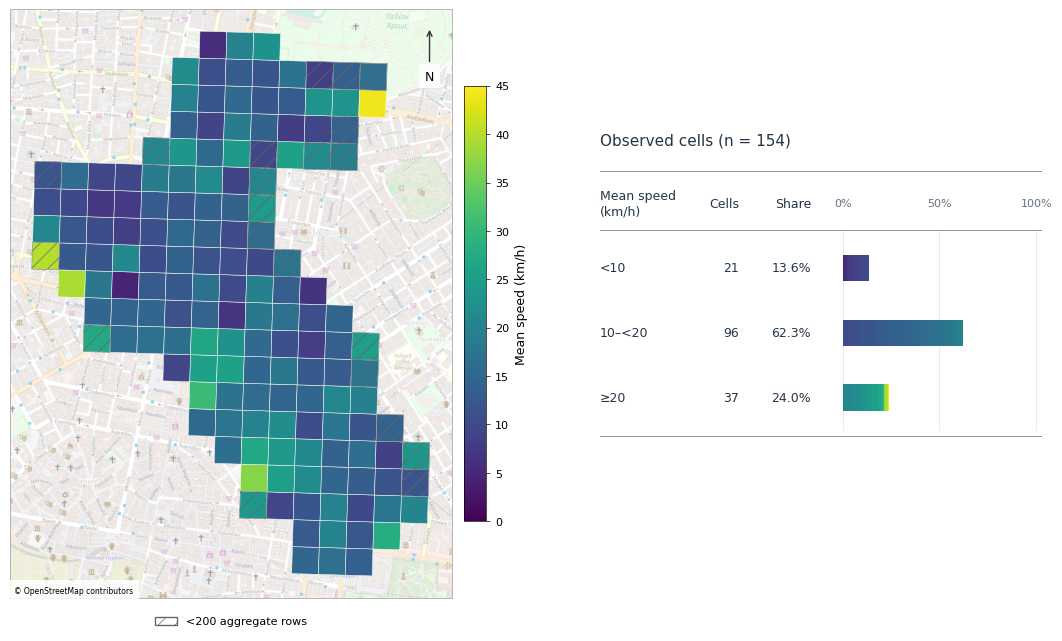

Đã cập nhật bản đồ và bảng: 154 ô.
Bản đồ và thanh dùng chung thang màu tốc độ 0–45 km/h.
Độ dài thanh = tỷ lệ ô; mỗi đoạn màu tương ứng một ô.
Đã ghi đè fig_rq1_map_speed.png và fig_rq1_map_speed.pdf.


In [ ]:
# RQ1: continuous speed map + cell-coloured summary bars.
# Run after the RQ1 setup/recovery and SQL summary cells.

from pathlib import Path
import inspect
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
from pyproj import CRS, Transformer
from IPython.display import display

RQ1_SPEED_MAP_COMPLETE = False

# ---------- 1. Verify the notebook state ----------
required = ["rq1_con", "rq1_manifest", "REPORT_DIR", "RQ1_READY"]
missing = [name for name in required if name not in globals()]
if missing or globals().get("RQ1_READY") is not True:
    raise RuntimeError(
        f"Chạy ô khởi tạo/khôi phục RQ1 trước. Thiếu: {missing}"
    )

try:
    import contextily as ctx
except ImportError as exc:
    raise RuntimeError(
        "Thiếu contextily. Chạy lại ô chuẩn bị thư viện của notebook."
    ) from exc

if "timeout" not in inspect.signature(ctx.bounds2img).parameters:
    raise RuntimeError(
        "Chạy lại ô chuẩn bị thư viện để cập nhật contextily."
    )

report_dir = Path(REPORT_DIR)
source = report_dir / "table_rq1_q1_cells.csv"
if not source.exists():
    raise FileNotFoundError(
        f"Chưa có {source.name}. Chạy ô SQL tổng hợp RQ1 trước."
    )

# ---------- 2. Read and validate the cell summary ----------
columns = [
    "cell", "grid_x", "grid_y", "lat", "lon",
    "records", "mean_speed_kmh",
]
cells = pd.read_csv(source, dtype={"cell": "string"})
missing_columns = set(columns) - set(cells.columns)
if missing_columns:
    raise ValueError(f"CSV thiếu cột: {sorted(missing_columns)}")

cells = cells[columns].sort_values("cell").reset_index(drop=True)

if (
    cells.empty
    or cells["cell"].isna().any()
    or cells["cell"].duplicated().any()
):
    raise ValueError("Bảng ô rỗng, thiếu mã ô hoặc có mã ô trùng.")

numeric_columns = columns[1:]
cells[numeric_columns] = cells[numeric_columns].apply(
    pd.to_numeric, errors="raise"
)
if not np.isfinite(
    cells[numeric_columns].to_numpy(dtype=float)
).all():
    raise ValueError("Bảng ô có giá trị thiếu hoặc không hữu hạn.")

integer_columns = ["grid_x", "grid_y", "records"]
values = cells[integer_columns].to_numpy(dtype=float)
if not np.equal(values, np.floor(values)).all():
    raise ValueError("Chỉ số lưới và số dòng phải là số nguyên.")
if (cells["records"] <= 0).any() or (cells["mean_speed_kmh"] < 0).any():
    raise ValueError("Số dòng hoặc tốc độ không hợp lệ.")

# Check the CSV against the current panel to avoid plotting stale results.
invalid = rq1_con.execute("""
    SELECT COUNT(*)
    FROM rq1_panel
    WHERE cell IS NULL OR speed IS NULL
       OR NOT isfinite(speed) OR speed < 0
       OR grid_x IS NULL OR grid_y IS NULL
       OR NOT isfinite(grid_x) OR NOT isfinite(grid_y)
       OR lat IS NULL OR lon IS NULL
       OR NOT isfinite(lat) OR NOT isfinite(lon)
""").fetchone()[0]

if invalid:
    raise ValueError("RQ1 panel có giá trị không hợp lệ.")

current = rq1_con.execute("""
    SELECT cell,
           MIN(grid_x) AS grid_x,
           MIN(grid_y) AS grid_y,
           MIN(lat) AS lat,
           MIN(lon) AS lon,
           COUNT(*) AS records,
           AVG(speed) AS mean_speed_kmh,
           COUNT(DISTINCT grid_x) AS nx,
           COUNT(DISTINCT grid_y) AS ny,
           COUNT(DISTINCT lat) AS nlat,
           COUNT(DISTINCT lon) AS nlon
    FROM rq1_panel
    GROUP BY cell
    ORDER BY cell
""").df()

if not current[["nx", "ny", "nlat", "nlon"]].eq(1).all().all():
    raise ValueError("Có ô mang tọa độ không nhất quán.")

current["cell"] = current["cell"].astype("string")
current = current.sort_values("cell").reset_index(drop=True)

if cells["cell"].tolist() != current["cell"].tolist():
    raise ValueError(
        "CSV không khớp RQ1 hiện tại. Chạy lại ô SQL tổng hợp."
    )

for column in integer_columns:
    if not np.array_equal(cells[column], current[column]):
        raise ValueError(
            f"CSV lệch cột {column}. Chạy lại ô SQL tổng hợp."
        )

for column in ["lat", "lon", "mean_speed_kmh"]:
    if not np.allclose(
        cells[column], current[column], rtol=1e-10, atol=1e-8
    ):
        raise ValueError(
            f"CSV lệch cột {column}. Chạy lại ô SQL tổng hợp."
        )

# Preserve full precision when assigning speed groups.
cells["mean_speed_kmh"] = current["mean_speed_kmh"].to_numpy()
speed = cells["mean_speed_kmh"].to_numpy(dtype=float)
n_cells = len(cells)

# ---------- 3. Calculate the three summary groups ----------
group_labels = ["<10", "10–<20", "≥20"]
group_id = np.select(
    [speed < 10, speed < 20],
    [0, 1],
    default=2,
)
counts = np.bincount(group_id, minlength=3)
percentages = counts / n_cells * 100

rq1_speed_group_summary = pd.DataFrame({
    "mean_speed_group_kmh": group_labels,
    "cells": counts,
    "share_pct": percentages,
})

assert counts.sum() == n_cells
assert np.isclose(percentages.sum(), 100)

# ---------- 4. Reconstruct the verified grid ----------
size = float(rq1_manifest["grid_size_m"])
origin_x = float(rq1_manifest["grid_origin_x_m"])
origin_y = float(rq1_manifest["grid_origin_y_m"])
grid_crs = CRS.from_user_input(rq1_manifest["grid_crs"])
support_threshold = int(
    rq1_manifest.get("descriptive_cell_threshold_rows", 200)
)

if size != 100 or grid_crs != CRS.from_epsg(32634):
    raise ValueError("Cần lưới 100 m trong EPSG:32634.")
if (
    not np.isfinite([origin_x, origin_y]).all()
    or support_threshold < 1
):
    raise ValueError("Thông số lưới hoặc ngưỡng số dòng không hợp lệ.")

encoded = (
    cells["grid_x"].astype("int64").astype(str)
    + "_"
    + cells["grid_y"].astype("int64").astype(str)
)
if not cells["cell"].eq(encoded).all():
    raise ValueError("Mã ô không khớp chỉ số lưới.")

x = origin_x + cells["grid_x"].to_numpy(dtype=float) * size
y = origin_y + cells["grid_y"].to_numpy(dtype=float) * size

to_geo = Transformer.from_crs(
    grid_crs, "EPSG:4326", always_xy=True
)
lon, lat = to_geo.transform(x + size / 2, y + size / 2)
if not (
    np.allclose(lon, cells["lon"], rtol=0, atol=1e-6)
    and np.allclose(lat, cells["lat"], rtol=0, atol=1e-6)
):
    raise ValueError("Tâm ô không khớp hệ tọa độ đã cấu hình.")

to_web = Transformer.from_crs(
    grid_crs, "EPSG:3857", always_xy=True
)
mx, my = to_web.transform(
    x[:, None] + np.array([0, size, size, 0]),
    y[:, None] + np.array([0, 0, size, size]),
)
polygons = np.stack([mx, my], axis=-1)
low_support = cells["records"].to_numpy() < support_threshold

padding = 0.04 * max(np.ptp(mx), np.ptp(my))
bounds = (
    mx.min() - padding,
    my.min() - padding,
    mx.max() + padding,
    my.max() + padding,
)

# ---------- 5. Load the street background ----------
# Do not replace existing output files if the background fails.
try:
    basemap, extent = ctx.bounds2img(
        *bounds,
        zoom=16,
        source=ctx.providers.OpenStreetMap.Mapnik,
        use_cache=True,
        headers={"User-Agent": "pNEUMA-Research-Notebook/1.0"},
        n_connections=1,
        max_retries=0,
        timeout=20,
    )
    if basemap.size == 0 or not np.isfinite(extent).all():
        raise ValueError("Nền đường trả về không hợp lệ.")
except Exception as exc:
    raise RuntimeError(
        "Chưa tải được nền đường; các file hình hiện có chưa bị thay đổi. "
        "Kiểm tra kết nối rồi chạy lại chính ô này."
    ) from exc

# ---------- 6. One shared colour scale for map and bars ----------
speed_cmap = plt.get_cmap("viridis")
norm = Normalize(vmin=0, vmax=45)
colorbar_extend = "max" if speed.max() > 45 else "neither"
ink = "#263445"

style = {
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "hatch.linewidth": 0.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

with plt.rc_context(style):
    fig = plt.figure(figsize=(11.2, 6.3), layout="constrained")
    grid = fig.add_gridspec(
        1, 2, width_ratios=[1.25, 1.1], wspace=0.12
    )
    ax_map = fig.add_subplot(grid[0, 0])
    ax_table = fig.add_subplot(grid[0, 1])

    try:
        # ----- Map -----
        ax_map.imshow(
            basemap, extent=extent, alpha=0.40, zorder=0
        )
        layer = PolyCollection(
            polygons,
            array=speed,
            cmap=speed_cmap,
            norm=norm,
            edgecolors="white",
            linewidths=0.35,
            zorder=2,
        )
        ax_map.add_collection(layer)

        if low_support.any():
            ax_map.add_collection(PolyCollection(
                polygons[low_support],
                facecolors="none",
                edgecolors="#666666",
                linewidths=0.35,
                hatch="//",
                zorder=3,
            ))

        ax_map.set_xlim(bounds[0], bounds[2])
        ax_map.set_ylim(bounds[1], bounds[3])
        ax_map.set_aspect("equal")
        ax_map.set_xticks([])
        ax_map.set_yticks([])

        for spine in ax_map.spines.values():
            spine.set_color("#AAAAAA")
            spine.set_linewidth(0.6)

        ax_map.annotate(
            "N",
            xy=(0.95, 0.97),
            xytext=(0.95, 0.88),
            xycoords="axes fraction",
            ha="center",
            fontsize=9,
            arrowprops={
                "arrowstyle": "->",
                "color": "#333333",
            },
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
            },
        )
        ax_map.text(
            0.01, 0.008,
            "© OpenStreetMap contributors",
            transform=ax_map.transAxes,
            fontsize=5.5,
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
            },
            zorder=5,
        )
        ax_map.legend(
            handles=[Patch(
                facecolor="white",
                edgecolor="#666666",
                hatch="//",
                label=f"<{support_threshold:,} aggregate rows",
            )],
            loc="upper center",
            bbox_to_anchor=(0.5, -0.015),
            frameon=False,
            fontsize=8,
        )

        colorbar = fig.colorbar(
            layer,
            ax=ax_map,
            fraction=0.045,
            pad=0.025,
            shrink=0.74,
            extend=colorbar_extend,
        )
        colorbar.set_label("Mean speed (km/h)", fontsize=9)
        colorbar.set_ticks(np.arange(0, 46, 5))
        colorbar.ax.tick_params(
            labelsize=8, width=0.5, length=3
        )
        colorbar.outline.set_linewidth(0.5)

        # ----- Table with cell-coloured bars -----
        ax_table.set_xlim(0, 1)
        ax_table.set_ylim(0, 1)
        ax_table.axis("off")

        ax_table.text(
            0.01, 0.77,
            f"Observed cells (n = {n_cells:,})",
            fontsize=11,
            color=ink,
        )
        ax_table.text(
            0.01, 0.67, "Mean speed\n(km/h)",
            va="center", color=ink,
        )
        ax_table.text(
            0.32, 0.67, "Cells",
            ha="right", va="center", color=ink,
        )
        ax_table.text(
            0.48, 0.67, "Share",
            ha="right", va="center", color=ink,
        )

        bar_left, bar_right = 0.55, 0.98
        bar_span = bar_right - bar_left
        bar_height = 0.045
        # Each observed cell contributes the same bar width.
        cell_width = bar_span / n_cells

        for tick in [0, 50, 100]:
            xpos = bar_left + bar_span * tick / 100
            ax_table.text(
                xpos, 0.67, f"{tick}%",
                ha="center", va="center",
                fontsize=8, color="#667080",
            )
            ax_table.plot(
                [xpos, xpos], [0.285, 0.625],
                color="#E5E8EC",
                linewidth=0.6,
                zorder=0,
            )

        for ypos in [0.725, 0.625, 0.275]:
            ax_table.plot(
                [0.01, 0.99], [ypos, ypos],
                color="#8793A0", linewidth=0.7,
            )

        for group, ypos in enumerate([0.56, 0.45, 0.34]):
            group_speeds = np.sort(speed[group_id == group])
            count = int(counts[group])
            share = percentages[group]

            ax_table.text(
                0.01, ypos, group_labels[group],
                va="center", color=ink,
            )
            ax_table.text(
                0.32, ypos, f"{count:,}",
                ha="right", va="center", color=ink,
            )
            ax_table.text(
                0.48, ypos, f"{share:.1f}%",
                ha="right", va="center", color=ink,
            )

            if count == 0:
                continue

            # One rectangle per actual cell, sorted by its mean speed.
            # The colour mapping is identical to that of the map.
            left_edges = bar_left + np.arange(count) * cell_width
            right_edges = left_edges + cell_width
            bottom = np.full(count, ypos - bar_height / 2)
            top = np.full(count, ypos + bar_height / 2)

            segments = np.stack([
                np.column_stack([left_edges, bottom]),
                np.column_stack([right_edges, bottom]),
                np.column_stack([right_edges, top]),
                np.column_stack([left_edges, top]),
            ], axis=1)

            ax_table.add_collection(PolyCollection(
                segments,
                array=group_speeds,
                cmap=speed_cmap,
                norm=norm,
                edgecolors="none",
                linewidths=0,
                antialiaseds=False,
                zorder=2,
            ))

            # Verify that bar length equals the group's cell share.
            assert np.isclose(
                count * cell_width,
                bar_span * share / 100,
            )

        # ----- Export to the same two filenames -----
        staged = []
        try:
            for extension in ["png", "pdf"]:
                destination = (
                    report_dir / f"fig_rq1_map_speed.{extension}"
                )
                with tempfile.NamedTemporaryFile(
                    dir=report_dir,
                    suffix=f".{extension}",
                    delete=False,
                ) as handle:
                    temporary = Path(handle.name)

                staged.append((temporary, destination))
                fig.savefig(
                    temporary,
                    format=extension,
                    dpi=300,
                    bbox_inches="tight",
                    pad_inches=0.05,
                    facecolor="white",
                )
                if temporary.stat().st_size == 0:
                    raise RuntimeError("Xuất hình thất bại.")

            for temporary, destination in staged:
                os.replace(temporary, destination)
        finally:
            for temporary, _ in staged:
                if temporary.exists():
                    temporary.unlink()

        display(fig)
    finally:
        plt.close(fig)

RQ1_SPEED_MAP_COMPLETE = True
print(f"Đã cập nhật bản đồ và bảng: {n_cells:,} ô.")
print("Bản đồ và thanh dùng chung thang màu tốc độ 0–45 km/h.")
print("Độ dài thanh = tỷ lệ ô; mỗi đoạn màu tương ứng một ô.")
print("Đã ghi đè fig_rq1_map_speed.png và fig_rq1_map_speed.pdf.")

**Spatial distribution of mean speed.** Cell colours show mean speed
on a shared 0–45 km/h scale. The table reports cell counts and
percentages in three speed ranges. Bar length represents the percentage
of observed cells; equal-width segments represent individual cells,
ordered by increasing speed and coloured using the map's scale.
Means pool recording–cell–10-second rows across four recording dates,
with equal weight per row within each cell. Hatching marks cells with
fewer than 200 contributing rows; none are excluded. Recording coverage
varies between cells. The 20 km/h boundary is descriptive, not a
validated traffic-state threshold. Uncoloured areas have no retained
observations. Street context is present-day; observations are from 2018.
Percentages may not sum to 100% due to rounding.

### Mean speed by date and recording window
### Tốc độ trung bình theo ngày và khung giờ

So sánh trên cùng tập ô lưới có quan sát trong mọi tổ hợp
ngày–khung giờ được chọn. Cột cuối tổng hợp theo ngày;
hàng cuối tổng hợp theo khung giờ.

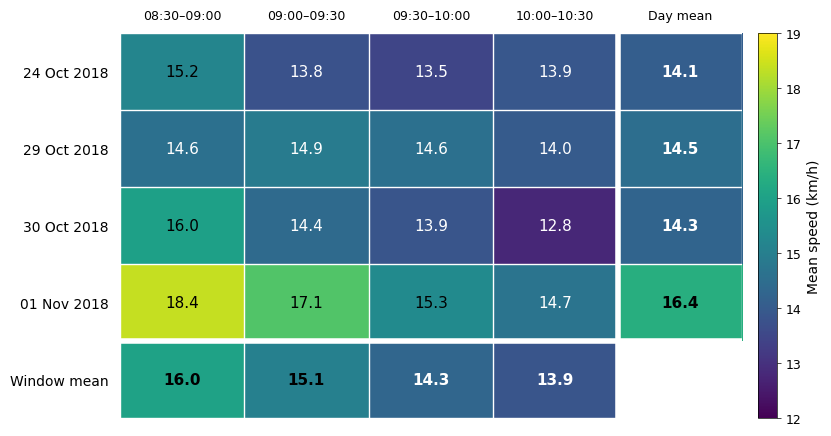

Đã cập nhật: 110 ô chung | 236,695 dòng | 4 ngày × 4 khung giờ.
Đã ghi đè cùng 2 CSV và fig_rq1_time_comparison.png/.pdf.


In [ ]:
# RQ1 — matched-cell time comparison, compact paper figure.
from pathlib import Path
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RQ1_TIME_COMPLETE = False

required = [
    "rq1_con", "RQ1_READY", "rq1_manifest",
    "REPORT_DIR", "atomic_csv",
]
missing = [name for name in required if name not in globals()]
if missing or globals().get("RQ1_READY") is not True:
    raise RuntimeError(
        f"Chạy ô khởi tạo/khôi phục RQ1 trước. Thiếu: {missing}"
    )

# Validate before computing means.
invalid = rq1_con.execute("""
    SELECT COUNT(*)
    FROM rq1_panel
    WHERE flight IS NULL OR cell IS NULL
       OR speed IS NULL OR NOT isfinite(speed) OR speed < 0
""").fetchone()[0]
if invalid:
    raise ValueError("RQ1 panel có mã hoặc tốc độ không hợp lệ.")

recording_cells = rq1_con.execute("""
    SELECT flight, cell,
           COUNT(*) AS records,
           AVG(speed) AS mean_speed_kmh
    FROM rq1_panel
    GROUP BY flight, cell
    ORDER BY flight, cell
""").df()

parts = recording_cells["flight"].str.extract(
    r"^(?P<date>\d{8})_d(?:10|[1-9])_"
    r"(?P<start>\d{4})_(?P<end>\d{4})$"
)
if recording_cells.empty or parts.isna().any().any():
    raise ValueError("Panel rỗng hoặc mã lần ghi hình không hợp lệ.")

pd.to_datetime(parts["date"], format="%Y%m%d", errors="raise")
for column in ["start", "end"]:
    hours = parts[column].str[:2].astype(int)
    minutes = parts[column].str[2:].astype(int)
    if (hours > 23).any() or (minutes > 59).any():
        raise ValueError("Giờ ghi hình không hợp lệ.")
if (parts["start"] >= parts["end"]).any():
    raise ValueError("Khung giờ phải có thời điểm bắt đầu trước kết thúc.")

recording_cells["date"] = parts["date"]
recording_cells["window"] = parts["start"] + "–" + parts["end"]

dates = sorted(map(str, rq1_manifest["recording_dates"]))
if sorted(recording_cells["date"].unique()) != dates:
    raise ValueError("Ngày ghi hình không khớp manifest.")

# Within each cell-period, aggregate rows receive equal weight.
recording_cells["speed_sum"] = (
    recording_cells["mean_speed_kmh"] * recording_cells["records"]
)
time_cells = recording_cells.groupby(
    ["date", "window", "cell"], as_index=False
).agg(
    records=("records", "sum"),
    speed_sum=("speed_sum", "sum"),
    recordings=("flight", "nunique"),
)
time_cells["mean_speed_kmh"] = (
    time_cells["speed_sum"] / time_cells["records"]
)
time_cells = time_cells.drop(columns="speed_sum")

# Retain scheduled windows present on every selected date.
availability = (
    time_cells.groupby(["date", "window"])
    .size()
    .unstack("window", fill_value=0)
    .reindex(index=dates, fill_value=0)
)
windows = sorted(
    availability.columns[availability.gt(0).all(axis=0)].tolist()
)
if not windows:
    raise ValueError("Không có khung giờ chung cho tất cả các ngày.")

# Retain the same cells in every selected date-window combination.
n_periods = len(dates) * len(windows)
candidates = time_cells.loc[time_cells["window"].isin(windows)]
period_counts = candidates.groupby("cell").size()
common_cells = sorted(
    period_counts.index[period_counts.eq(n_periods)].tolist()
)
if not common_cells:
    raise ValueError(
        "Không có ô được quan sát trong mọi tổ hợp ngày–khung giờ."
    )

time_cells["included_in_comparison"] = (
    time_cells["cell"].isin(common_cells)
    & time_cells["window"].isin(windows)
)
matched = time_cells.loc[
    time_cells["included_in_comparison"]
].copy()

if len(matched) != len(common_cells) * n_periods:
    raise ValueError("Tập ô–khung giờ so sánh chưa đầy đủ.")

# Equal weight across cells; equal weight across periods for margins.
date_cell = matched.groupby(
    ["date", "cell"], as_index=False
)["mean_speed_kmh"].mean()
window_cell = matched.groupby(
    ["window", "cell"], as_index=False
)["mean_speed_kmh"].mean()

matched_recordings = recording_cells.loc[
    recording_cells["cell"].isin(common_cells)
    & recording_cells["window"].isin(windows)
]

summary_rows = []
for kind, field, table, labels in [
    ("date", "date", date_cell, dates),
    ("window", "window", window_cell, windows),
]:
    for label in labels:
        speeds = table.loc[
            table[field].eq(label), "mean_speed_kmh"
        ]
        supporting = matched_recordings.loc[
            matched_recordings[field].eq(label)
        ]
        summary_rows.append({
            "comparison": kind,
            "period": label,
            "common_cells": len(speeds),
            "mean_speed_kmh": speeds.mean(),
            "median_speed_kmh": speeds.median(),
            "p25_cell_speed_kmh": speeds.quantile(0.25),
            "p75_cell_speed_kmh": speeds.quantile(0.75),
            "supporting_rows": int(supporting["records"].sum()),
            "supporting_recordings": supporting["flight"].nunique(),
        })

rq1_time_summary = pd.DataFrame(summary_rows)
matched_rows = int(matched["records"].sum())

period_speed = (
    matched.groupby(["date", "window"])["mean_speed_kmh"]
    .mean()
    .unstack("window")
    .reindex(index=dates, columns=windows)
)
values = period_speed.to_numpy(dtype=float)
if not np.isfinite(values).all():
    raise ValueError("Ma trận tốc độ có giá trị thiếu hoặc không hữu hạn.")

day_means = values.mean(axis=1)
window_means = values.mean(axis=0)

# Verify figure margins against the exported summaries.
for kind, expected in [
    ("date", day_means),
    ("window", window_means),
]:
    actual = rq1_time_summary.loc[
        rq1_time_summary["comparison"].eq(kind),
        "mean_speed_kmh",
    ].to_numpy()
    if not np.allclose(actual, expected, rtol=1e-10, atol=1e-10):
        raise ValueError("Trung bình trên hình không khớp bảng tổng hợp.")

# The bottom-right position is intentionally unused, not missing data.
figure_values = np.full(
    (len(dates) + 1, len(windows) + 1), np.nan
)
figure_values[:-1, :-1] = values
figure_values[:-1, -1] = day_means
figure_values[-1, :-1] = window_means

def period_label(value, kind):
    if kind == "date":
        return pd.to_datetime(
            value, format="%Y%m%d"
        ).strftime("%d %b %Y")
    start, end = value.split("–")
    return f"{start[:2]}:{start[2:]}–{end[:2]}:{end[2:]}"

report_dir = Path(REPORT_DIR)
report_dir.mkdir(parents=True, exist_ok=True)

style = {
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

with plt.rc_context(style):
    fig, ax = plt.subplots(figsize=(8.2, 4.25), layout="constrained")
    staged = []

    try:
        cmap = plt.get_cmap("viridis").copy()
        cmap.set_bad("white")

        # Current data produce a 12–19 km/h scale.
        vmin = float(np.floor(values.min()))
        vmax = max(vmin + 1, float(np.ceil(values.max())))

        im = ax.imshow(
            np.ma.masked_invalid(figure_values),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            aspect="auto",
            interpolation="nearest",
        )

        ax.set_xticks(np.arange(len(windows) + 1))
        ax.set_xticklabels(
            [period_label(w, "window") for w in windows]
            + ["Day mean"],
            fontsize=9,
        )
        ax.set_yticks(np.arange(len(dates) + 1))
        ax.set_yticklabels(
            [period_label(d, "date") for d in dates]
            + ["Window mean"],
            fontsize=10,
        )
        ax.xaxis.tick_top()
        ax.tick_params(axis="both", which="major", length=0, pad=8)

        ax.set_xticks(
            np.arange(-0.5, len(windows) + 1, 1), minor=True
        )
        ax.set_yticks(
            np.arange(-0.5, len(dates) + 1, 1), minor=True
        )
        ax.grid(which="minor", color="white", linewidth=1)
        ax.tick_params(
            which="minor",
            bottom=False, top=False, left=False, right=False,
        )

        # Separate the summaries from the interior comparisons.
        ax.axvline(len(windows) - 0.5, color="white", linewidth=4)
        ax.axhline(len(dates) - 0.5, color="white", linewidth=4)

        # Remove the outer box so the unused corner stays unobtrusive.
        for spine in ax.spines.values():
            spine.set_visible(False)

        for row in range(figure_values.shape[0]):
            for column in range(figure_values.shape[1]):
                value = figure_values[row, column]
                if not np.isfinite(value):
                    continue

                rgb = np.array(im.cmap(im.norm(value))[:3])
                linear_rgb = np.where(
                    rgb <= 0.04045,
                    rgb / 12.92,
                    ((rgb + 0.055) / 1.055) ** 2.4,
                )
                luminance = np.dot(
                    linear_rgb, [0.2126, 0.7152, 0.0722]
                )
                text_colour = "black" if luminance > 0.179 else "white"
                is_summary = (
                    row == len(dates) or column == len(windows)
                )

                ax.text(
                    column, row, f"{value:.1f}",
                    ha="center", va="center",
                    color=text_colour,
                    fontsize=11,
                    fontweight="semibold" if is_summary else "normal",
                )

        colorbar = fig.colorbar(
            im, ax=ax, fraction=0.045, pad=0.025
        )
        colorbar.set_label("Mean speed (km/h)", fontsize=10)
        colorbar.ax.tick_params(labelsize=9, length=3, width=0.5)
        colorbar.outline.set_linewidth(0.5)

        # Render both formats before replacing existing image files.
        for extension in ["png", "pdf"]:
            destination = (
                report_dir / f"fig_rq1_time_comparison.{extension}"
            )
            with tempfile.NamedTemporaryFile(
                dir=report_dir,
                suffix=f".{extension}",
                delete=False,
            ) as handle:
                temporary = Path(handle.name)

            staged.append((temporary, destination))
            fig.savefig(
                temporary,
                format=extension,
                dpi=300,
                facecolor="white",
                bbox_inches="tight",
                pad_inches=0.05,
            )
            if temporary.stat().st_size == 0:
                raise RuntimeError("Xuất hình thất bại.")

        for temporary, destination in staged:
            os.replace(temporary, destination)

        display(fig)

    finally:
        for temporary, _ in staged:
            if temporary.exists():
                temporary.unlink()
        plt.close(fig)

# Keep the existing summary outputs and filenames.
atomic_csv(
    time_cells,
    report_dir / "table_rq1_time_cell_period.csv",
)
atomic_csv(
    rq1_time_summary,
    report_dir / "table_rq1_time_comparison.csv",
)

RQ1_TIME_COMPLETE = True
print(
    f"Đã cập nhật: {len(common_cells):,} ô chung | "
    f"{matched_rows:,} dòng | "
    f"{len(dates)} ngày × {len(windows)} khung giờ."
)
print("Đã ghi đè cùng 2 CSV và fig_rq1_time_comparison.png/.pdf.")

**Hình X. Tốc độ trung bình theo ngày và khung giờ ghi hình.**
So sánh trên cùng 110 ô lưới 100 m, có quan sát trong tất cả
16 tổ hợp ngày–khung giờ, gồm 236.695 dòng tổng hợp.
Trong mỗi tổ hợp, tốc độ được lấy trung bình qua các ô với
trọng số bằng nhau. Cột cuối là trung bình qua các khung giờ;
hàng cuối là trung bình qua các ngày. Màu tối biểu thị tốc độ
thấp hơn trên thang 12–19 km/h. Các khung giờ là lịch ghi hình,
không hàm ý quan sát liên tục.

Trên cùng tập ô quan sát, tốc độ trung bình khác nhau theo ngày
và khung giờ. Khi lấy trung bình qua bốn ngày, tốc độ giảm từ
16,0 km/h ở khung 08:30–09:00 xuống 13,9 km/h ở khung
10:00–10:30. Ngày 01/11 có tốc độ trung bình cao nhất
(16,4 km/h), so với 14,1–14,5 km/h ở ba ngày còn lại.
Tuy nhiên, tốc độ không giảm liên tiếp trong mọi ngày:
ngày 24/10 và 29/10 có dao động tăng giảm giữa các khung.

Kết quả cho thấy cần phân biệt ngày và khung giờ khi mô tả
tốc độ giao thông trong RQ1. So sánh trên cùng tập ô hạn chế
ảnh hưởng của việc thay đổi vị trí quan sát, nhưng chưa kiểm
soát khác biệt về lượng và thời điểm ghi hình trong mỗi khung.
Do đó, kết quả mô tả sự khác biệt trong dữ liệu nghiên cứu,
chưa xác định nguyên nhân hoặc quy luật giờ cao điểm.

### Traffic characteristics and observed speed
### Đặc điểm giao thông và tốc độ quan sát

So sánh tốc độ trung vị theo số track, tỷ lệ điểm quan sát xe máy
và tỷ lệ điểm quan sát nhóm xe nặng. Ba biểu đồ dùng cùng thang
tốc độ; số ở cuối mỗi cột là tốc độ trung vị của nhóm.

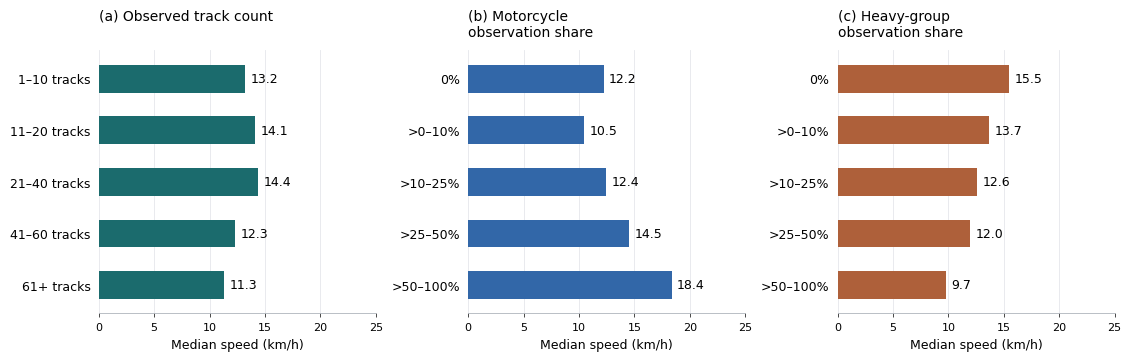

Đã cập nhật hình; mỗi phép so sánh sử dụng 316,008 dòng.
Đã ghi đè fig_rq1_traffic_groups.png và .pdf.


In [ ]:
# RQ1 — compact traffic-group comparisons.
# Run after the RQ1 setup/recovery cell.

from pathlib import Path
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RQ1_GROUP_FIGURE_COMPLETE = False

if (
    globals().get("RQ1_READY") is not True
    or globals().get("rq1_con") is None
    or "REPORT_DIR" not in globals()
):
    raise RuntimeError(
        "Chạy ô khởi tạo/khôi phục RQ1 trước, rồi chạy lại ô này."
    )

# Read the complete RQ1 panel, without filtering on future targets.
traffic = rq1_con.execute("""
    SELECT speed, n_veh, share_2w, share_heavy
    FROM rq1_panel
""").df()

if traffic.empty:
    raise ValueError("Bảng RQ1 rỗng.")

if not np.isfinite(traffic.to_numpy(dtype=float)).all():
    raise ValueError("Bảng RQ1 có giá trị thiếu hoặc không hữu hạn.")

if (
    traffic["speed"].lt(0).any()
    or traffic["n_veh"].lt(1).any()
    or traffic["n_veh"].mod(1).ne(0).any()
    or not traffic["share_2w"].between(0, 1).all()
    or not traffic["share_heavy"].between(0, 1).all()
):
    raise ValueError("Giá trị giao thông nằm ngoài phạm vi hợp lệ.")

# Preserve the existing group boundaries.
specifications = [
    {
        "column": "n_veh",
        "title": "(a) Observed track count",
        "colour": "#1B6B6D",
        "edges": [0, 10, 20, 40, 60, np.inf],
        "labels": [
            "1–10 tracks", "11–20 tracks", "21–40 tracks",
            "41–60 tracks", "61+ tracks",
        ],
    },
    {
        "column": "share_2w",
        "title": "(b) Motorcycle\nobservation share",
        "colour": "#3267A8",
        "edges": [-np.inf, 0, 0.10, 0.25, 0.50, 1.0],
        "labels": [
            "0%", ">0–10%", ">10–25%", ">25–50%", ">50–100%",
        ],
    },
    {
        "column": "share_heavy",
        "title": "(c) Heavy-group\nobservation share",
        "colour": "#AE603A",
        "edges": [-np.inf, 0, 0.10, 0.25, 0.50, 1.0],
        "labels": [
            "0%", ">0–10%", ">10–25%", ">25–50%", ">50–100%",
        ],
    },
]

tables = []
summary_parts = []

for spec in specifications:
    groups = pd.cut(
        traffic[spec["column"]],
        bins=spec["edges"],
        labels=spec["labels"],
        right=True,
    )
    if groups.isna().any():
        raise ValueError(
            f"Có dòng chưa được phân nhóm: {spec['column']}."
        )

    table = (
        traffic.groupby(groups, observed=False)["speed"]
        .agg(
            rows="size",
            median="median",
            p25=lambda s: s.quantile(0.25),
            p75=lambda s: s.quantile(0.75),
        )
        .reindex(spec["labels"])
    )

    if int(table["rows"].sum()) != len(traffic):
        raise ValueError(
            f"Tổng số dòng không khớp: {spec['column']}."
        )

    tables.append(table)
    saved = table.rename_axis("group").reset_index()
    saved.insert(0, "variable", spec["column"])
    summary_parts.append(saved)

# Keep counts and quartiles available for inspection in the notebook.
rq1_group_summary = pd.concat(summary_parts, ignore_index=True)

# Same zero-based axis in all three panels.
# Current data retain the original 0–25 km/h scale.
largest_median = max(float(table["median"].max()) for table in tables)
axis_max = max(25.0, float(np.ceil((largest_median + 3) / 5) * 5))
tick_step = 5 if axis_max <= 30 else float(np.ceil(axis_max / 25) * 5)

style = {
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "font.weight": "normal",
    "text.color": "black",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

report_dir = Path(REPORT_DIR)
report_dir.mkdir(parents=True, exist_ok=True)

with plt.rc_context(style):
    fig, axes = plt.subplots(
        1, 3,
        figsize=(11.2, 3.5),
        sharex=True,
        layout="constrained",
    )
    staged = []

    try:
        for ax, spec, table in zip(axes, specifications, tables):
            for ypos, (_, row) in enumerate(table.iterrows()):
                if row["rows"] == 0:
                    ax.text(
                        0.3, ypos, "No observations",
                        va="center", fontsize=9,
                        color="black", fontweight="normal",
                    )
                    continue

                median = float(row["median"])
                ax.barh(
                    ypos, median,
                    height=0.54,
                    color=spec["colour"],
                    edgecolor="none",
                    zorder=2,
                )
                ax.annotate(
                    f"{median:.1f}",
                    xy=(median, ypos),
                    xytext=(4, 0),
                    textcoords="offset points",
                    ha="left", va="center",
                    fontsize=9,
                    color="black",
                    fontweight="normal",
                )

            ax.set_yticks(np.arange(len(spec["labels"])))
            ax.set_yticklabels(spec["labels"], fontsize=9)
            ax.set_ylim(len(spec["labels"]) - 0.45, -0.55)

            ax.set_xlim(0, axis_max)
            ax.set_xticks(np.arange(0, axis_max + 0.01, tick_step))
            ax.set_xlabel("Median speed (km/h)", fontsize=9)

            # Same two-line title height across panels.
            title = spec["title"]
            if "\n" not in title:
                title += "\n"
            ax.set_title(
                title,
                loc="left",
                fontsize=10,
                fontweight="normal",
                color="black",
                pad=10,
            )

            ax.grid(
                axis="x",
                color="#E5E7EB",
                linewidth=0.6,
                zorder=0,
            )
            ax.set_axisbelow(True)
            ax.tick_params(axis="y", length=0, pad=6)
            ax.tick_params(axis="x", labelsize=8, length=3, width=0.5)

            for side in ["top", "right", "left"]:
                ax.spines[side].set_visible(False)
            ax.spines["bottom"].set_color("#AEB4BC")
            ax.spines["bottom"].set_linewidth(0.6)

        # Render both formats before replacing the existing image files.
        for extension in ["png", "pdf"]:
            destination = (
                report_dir / f"fig_rq1_traffic_groups.{extension}"
            )
            with tempfile.NamedTemporaryFile(
                dir=report_dir,
                suffix=f".{extension}",
                delete=False,
            ) as handle:
                temporary = Path(handle.name)

            staged.append((temporary, destination))
            fig.savefig(
                temporary,
                format=extension,
                dpi=300,
                facecolor="white",
                bbox_inches="tight",
                pad_inches=0.05,
            )
            if temporary.stat().st_size == 0:
                raise RuntimeError("Xuất hình thất bại.")

        for temporary, destination in staged:
            os.replace(temporary, destination)

        display(fig)

    finally:
        for temporary, _ in staged:
            if temporary.exists():
                temporary.unlink()
        plt.close(fig)

RQ1_GROUP_FIGURE_COMPLETE = True
print(f"Đã cập nhật hình; mỗi phép so sánh sử dụng {len(traffic):,} dòng.")
print("Đã ghi đè fig_rq1_traffic_groups.png và .pdf.")

Hình X. Tốc độ trung vị theo đặc điểm giao thông:
(a) số track quan sát, (b) tỷ lệ điểm quan sát xe máy và
(c) tỷ lệ điểm quan sát nhóm xe nặng. Mỗi phép so sánh sử dụng
316.008 dòng tổng hợp lần ghi hình–ô lưới–khoảng 10 giây,
với trọng số bằng nhau giữa các dòng. Số cuối cột là tốc độ
trung vị (km/h); ba biểu đồ dùng cùng thang đo bắt đầu từ 0.
Nhóm 0% được tách riêng; các khoảng tỷ lệ còn lại không gồm
cận dưới và có gồm cận trên. Số track không phải mật độ giao
thông, và tỷ lệ điểm quan sát không phải tỷ lệ số xe.
Quy mô các nhóm khác nhau; hình thể hiện liên hệ mô tả trong
dữ liệu gộp, không thể hiện quan hệ nhân quả.

Tốc độ trung vị khác nhau giữa các nhóm đặc điểm giao thông.
Theo số track, tốc độ tăng từ 13,2 km/h ở nhóm 1–10 track
lên 14,4 km/h ở nhóm 21–40 track, rồi giảm xuống 11,3 km/h
ở nhóm từ 61 track trở lên. Như vậy, quan hệ giữa số track
và tốc độ không đơn điệu trên toàn bộ các nhóm.

Trong các nhóm có tỷ lệ điểm quan sát xe máy lớn hơn 0,
tốc độ trung vị tăng từ 10,5 lên 18,4 km/h khi chuyển từ
nhóm >0–10% sang nhóm >50–100%. Tuy nhiên, nhóm không có
điểm quan sát xe máy đạt 12,2 km/h, cao hơn nhóm >0–10%.
Đối với nhóm xe nặng, tốc độ trung vị giảm theo các nhóm
tỷ lệ tăng dần, từ 15,5 km/h ở nhóm 0% xuống 9,7 km/h
ở nhóm >50–100%.

Các kết quả bổ sung cho RQ1 bằng cách cho thấy tốc độ quan sát
có liên hệ với số track và thành phần điểm quan sát, với
dạng biến thiên khác nhau giữa các đặc điểm. Đây là so sánh
gộp, chưa kiểm soát vị trí, thời gian và các đặc điểm giao
thông khác; vì vậy, không thể kết luận xe máy làm tăng tốc độ
hay xe nặng làm giảm tốc độ.

Tốc độ trung vị khác nhau giữa các nhóm đặc điểm giao thông.
Theo số track, tốc độ tăng từ 13,2 km/h ở nhóm 1–10 track
lên 14,4 km/h ở nhóm 21–40 track, rồi giảm xuống 11,3 km/h
ở nhóm từ 61 track trở lên. Như vậy, quan hệ giữa số track
và tốc độ không đơn điệu trên toàn bộ các nhóm.

Trong các nhóm có tỷ lệ điểm quan sát xe máy lớn hơn 0,
tốc độ trung vị tăng từ 10,5 lên 18,4 km/h khi chuyển từ
nhóm >0–10% sang nhóm >50–100%. Tuy nhiên, nhóm không có
điểm quan sát xe máy đạt 12,2 km/h, cao hơn nhóm >0–10%.
Đối với nhóm xe nặng, tốc độ trung vị giảm theo các nhóm
tỷ lệ tăng dần, từ 15,5 km/h ở nhóm 0% xuống 9,7 km/h
ở nhóm >50–100%.

Các kết quả bổ sung cho RQ1 bằng cách cho thấy tốc độ quan sát
có liên hệ với số track và thành phần điểm quan sát, với
dạng biến thiên khác nhau giữa các đặc điểm. Đây là so sánh
gộp, chưa kiểm soát vị trí, thời gian và các đặc điểm giao
thông khác; vì vậy, không thể kết luận xe máy làm tăng tốc độ
hay xe nặng làm giảm tốc độ.

## RQ1 findings and limitations (Kết quả RQ1 và giới hạn)

### Phạm vi phân tích

Phân tích sử dụng 316.008 dòng tổng hợp từ 199 lần ghi hình,
thuộc bốn ngày và 154 ô lưới 100 m. Mỗi dòng tương ứng với
một lần ghi hình, một ô lưới và một khoảng 10 giây có quan sát.

Bản đồ và so sánh theo đặc điểm giao thông sử dụng toàn bộ
dữ liệu này. Riêng so sánh thời gian sử dụng cùng 110 ô có
quan sát trong tất cả các tổ hợp của bốn ngày và bốn khung giờ
chung, gồm 236.695 dòng, tương đương 74,9% dữ liệu.
Các quan sát ngoài tập so sánh thời gian vẫn được giữ trong
dữ liệu nguồn và các phân tích còn lại.

### 1. Tốc độ khác nhau giữa các ô quan sát

Trong 154 ô có quan sát, 21 ô (13,6%) có tốc độ trung bình
dưới 10 km/h; 96 ô (62,3%) từ 10 đến dưới 20 km/h;
37 ô (24,0%) từ 20 km/h trở lên. Nhóm 10–<20 km/h
chiếm tỷ lệ lớn nhất.

Bản đồ cho biết vị trí và mức tốc độ của từng ô; bảng bên cạnh
cho biết mức độ phổ biến của ba nhóm trong tập ô quan sát.
Các tỷ lệ này là tỷ lệ số ô, không phải tỷ lệ phương tiện
hoặc tỷ lệ thời gian giao thông chạy chậm. Mốc 20 km/h
được dùng để tổng hợp mô tả, không phải ngưỡng xác định
trạng thái giao thông.

### 2. Tốc độ khác nhau theo ngày và khung giờ

Trên cùng tập 110 ô, ngày 01/11 có tốc độ trung bình cao nhất
(16,4 km/h), còn ngày 24/10 thấp nhất (14,1 km/h).
Khi lấy trung bình qua bốn ngày, tốc độ giảm từ 16,0 km/h
ở khung 08:30–09:00 xuống 13,9 km/h ở khung 10:00–10:30.

Diễn biến từng ngày không hoàn toàn giống nhau: tốc độ giảm
liên tiếp qua các khung vào ngày 30/10 và 01/11, nhưng có
dao động tăng giảm vào ngày 24/10 và 29/10. Vì vậy,
xu hướng tổng hợp không nên được diễn giải thành quy luật
giảm tốc độ trong mọi ngày.

### 3. Tốc độ có liên hệ với đặc điểm giao thông

Theo số track quan sát, tốc độ trung vị tăng từ 13,2 km/h
ở nhóm 1–10 track lên 14,4 km/h ở nhóm 21–40 track,
rồi giảm xuống 11,3 km/h ở nhóm từ 61 track trở lên.
Quan hệ giữa các nhóm số track và tốc độ không đơn điệu.

Trong các nhóm có tỷ lệ điểm quan sát xe máy lớn hơn 0,
tốc độ trung vị tăng từ 10,5 km/h ở nhóm >0–10%
lên 18,4 km/h ở nhóm >50–100%. Nhóm 0% có trung vị
12,2 km/h, nên xu hướng tăng không áp dụng cho toàn bộ
các nhóm.

Đối với nhóm xe nặng, tốc độ trung vị giảm qua các nhóm
tỷ lệ tăng dần, từ 15,5 km/h ở nhóm 0% xuống 9,7 km/h
ở nhóm >50–100%.

Các giá trị trong phần này là trung vị, khác với tốc độ
trung bình dùng trong bản đồ và hình so sánh thời gian.

### Giới hạn khi diễn giải

- Lượng và thời điểm ghi hình khác nhau giữa các ô.
  Có 21 ô dưới 200 dòng tổng hợp, được đánh dấu gạch chéo
  và vẫn giữ lại. Đây là dấu hiệu ít dữ liệu hỗ trợ,
  không phải kiểm định độ tin cậy. Những ô này không đồng
  nghĩa với 21 ô có tốc độ trung bình dưới 10 km/h.

- So sánh thời gian dùng cùng ô và khung giờ, nhưng không
  bảo đảm thời lượng quan sát bằng nhau hoặc quan sát
  liên tục trong từng khung. Các khác biệt được báo cáo
  là mô tả, chưa được kiểm định ý nghĩa thống kê.

- Số track không phải mật độ giao thông. Tỷ lệ điểm quan sát
  theo loại xe không phải tỷ lệ số phương tiện. Quy mô
  các nhóm khác nhau; so sánh gộp chưa kiểm soát vị trí,
  thời gian và các đặc điểm giao thông khác.

- Kết quả áp dụng cho phạm vi quan sát của nghiên cứu,
  không đại diện toàn bộ giao thông Athens. Tốc độ thấp
  chưa đủ để khẳng định ùn tắc kéo dài, và các liên hệ
  quan sát được không chứng minh quan hệ nhân quả.

### Câu trả lời tổng hợp cho RQ1

Trong dữ liệu nghiên cứu, tốc độ giao thông khác nhau theo
vị trí, ngày và khung giờ, đồng thời có liên hệ với số track
và thành phần điểm quan sát phương tiện. Phần lớn ô thuộc
nhóm tốc độ trung bình 10–<20 km/h; trên tập ô chung,
các khung muộn hơn có tốc độ trung bình thấp hơn khi tổng
hợp qua bốn ngày. So sánh theo đặc điểm giao thông cho thấy
quan hệ không đơn điệu với số track, xu hướng tăng theo
các nhóm tỷ lệ xe máy dương và xu hướng giảm theo các nhóm
tỷ lệ xe nặng.

RQ1 cung cấp mô tả về nơi nào, thời điểm nào và nhóm quan sát
nào có tốc độ khác nhau. Hiệu quả dự báo tốc độ và cảnh báo
được đánh giá riêng trong RQ2 và RQ3.

<a id="handover"></a>

## Part IV · Handover to models (Phần IV · Bàn giao sang mô hình)

### Verified data handover (Dữ liệu bàn giao đã kiểm chứng)

Notebook 01 has exported the feature table and manifest for run
`pneuma_4days_100m_v1`. The counts below refer to the completed
execution reported in this notebook.

(Notebook 01 đã xuất bảng đặc trưng và manifest cho lần chạy
`pneuma_4days_100m_v1`. Các số lượng dưới đây thuộc lần thực thi
đã hoàn tất được báo cáo trong notebook.)

| Item / Nội dung | Result / Kết quả |
|---|---:|
| Selected raw CSV files / File CSV thô được chọn | 199 |
| Recording dates / Ngày ghi hình | 4 |
| Observed grid cells / Ô lưới có quan sát | 154 |
| Aggregate panel rows / Dòng bảng tổng hợp | 316,008 |
| Exported feature rows / Dòng đặc trưng đã xuất | 316,008 |
| Exported columns / Cột đã xuất | 22 |
| Rows with complete six-interval history / Dòng đủ sáu khoảng lịch sử | 267,516 |
| Rows with a +30 s speed target / Dòng có nhãn tốc độ +30 giây | 291,246 |
| Rows with a +60 s speed target / Dòng có nhãn tốc độ +60 giây | 280,603 |
| Rows with a complete future warning window / Dòng đủ cửa sổ cảnh báo tương lai | 261,215 |
| Quarantined source vehicle rows / Hàng phương tiện nguồn được cách ly | 1 |

Availability counts overlap and must not be added together.
They are not final training or test sample counts. The exported
table retains rows with missing historical features or future
labels. A complete future warning window alone does not establish
eligibility for onset warning.

(Các số lượng đủ dữ liệu có giao nhau và không được cộng lại.
Đây chưa phải số mẫu huấn luyện hoặc kiểm tra cuối cùng.
Bảng xuất giữ các dòng thiếu đặc trưng lịch sử hoặc nhãn tương lai.
Chỉ có đủ cửa sổ tương lai chưa đồng nghĩa với đủ điều kiện
làm mẫu cảnh báo khởi phát.)

### Files and verification (File và kiểm chứng)

The run's `data/processed` directory contains:

(Thư mục `data/processed` của lần chạy chứa:)

| File | Purpose / Vai trò |
|---|---|
| `pneuma.parquet` | Cleaned aggregate panel / Bảng đã làm sạch và tổng hợp |
| `feat.parquet` | Feature table and future labels / Bảng đặc trưng và nhãn tương lai |
| `manifest.json` | Metadata and verification checksums / Thông tin mô tả và mã kiểm tra tính toàn vẹn |

The independent temporal audit reported zero mismatches across
nine audited fields and all 316,008 rows. The export step also
completed its consistency and file-integrity checks. These results
apply to the reported execution; Notebook 02 must verify the files
again when loading them.

(Kiểm tra thời gian độc lập báo không có sai lệch ở chín biến
được kiểm tra trên toàn bộ 316.008 dòng. Bước xuất cũng hoàn tất
kiểm tra tính nhất quán và tính toàn vẹn file. Các kết quả này
áp dụng cho lần thực thi được báo cáo; Notebook 02 phải kiểm tra
lại file khi nạp dữ liệu.)

### Loading and sample eligibility (Nạp dữ liệu và điều kiện đủ mẫu)

Notebook 02 must use the same project root and run identifier,
load `feat.parquet`, and verify its integrity and schema against
the manifest before modelling. Spatial operations must use the
exported coordinate reference system, grid size and origin;
metric cell identifiers must not be interpreted as latitude
and longitude.

(Notebook 02 phải dùng cùng thư mục gốc và mã lần chạy, nạp
`feat.parquet`, rồi đối chiếu tính toàn vẹn và cấu trúc bảng
với manifest trước khi xây dựng mô hình. Các thao tác không gian
phải dùng hệ tọa độ, kích thước và gốc lưới đã xuất; không
diễn giải mã ô theo lưới mét thành kinh độ và vĩ độ.)

Define eligibility separately for each task and forecast horizon.
Missing targets must not be replaced with zero. Report the number
of eligible rows and the number assigned to each data partition.

(Xác định riêng điều kiện đủ mẫu cho từng nhiệm vụ và tầm dự báo.
Không thay nhãn thiếu bằng 0. Báo cáo số dòng đủ điều kiện và
số dòng thuộc từng tập dữ liệu.)

The 110-cell subset used for the RQ1 temporal comparison does not
define the modelling sample or the train/test split.

(Tập 110 ô dùng để so sánh thời gian trong RQ1 không xác định
mẫu mô hình hoặc cách chia huấn luyện–kiểm tra.)

### RQ2 · Speed forecasting (Dự báo tốc độ)

Compare Persistence, Ridge, Random Forest, LightGBM and
LTSF-Linear at +30 s and +60 s, with +60 s as the primary horizon.
Report MAE and RMSE, with MAE as the primary metric.

(So sánh Persistence, Ridge, Random Forest, LightGBM và
LTSF-Linear tại +30 giây và +60 giây, trong đó +60 giây là
tầm dự báo chính. Báo cáo MAE và RMSE, với MAE là chỉ số chính.)

Separate training and test data by recording using the predefined
leave-flights-out protocol. Do not randomly split aggregate rows
from the same recording across training and test sets. Validation
for model selection must also respect recording boundaries.

(Tách dữ liệu huấn luyện và kiểm tra theo lần ghi hình bằng
quy trình leave-flights-out đã xác định. Không chia ngẫu nhiên
các dòng thuộc cùng lần ghi hình sang cả tập huấn luyện và
kiểm tra. Tập xác thực dùng để chọn mô hình cũng phải tuân thủ
ranh giới lần ghi hình.)

Fit learned preprocessing steps only on the training partition.
Use validation data for model and hyperparameter selection,
and reserve test data for final evaluation. Inputs must use
only information available at the prediction time.

(Các bước tiền xử lý có học tham số chỉ được khớp trên tập
huấn luyện. Dùng tập xác thực để chọn mô hình và siêu tham số;
giữ tập kiểm tra cho đánh giá cuối cùng. Đầu vào chỉ được sử dụng
thông tin đã có tại thời điểm dự báo.)

Use the same eligible test rows for every model at a given horizon.
Run five training seeds on the same predefined split. Deterministic
baselines do not acquire meaningful seed variability through
repeated identical runs.

(Các mô hình tại cùng tầm dự báo phải dùng chung những dòng
kiểm tra đủ điều kiện. Chạy năm seed huấn luyện trên cùng cách
chia đã xác định. Việc chạy lặp lại một mô hình cơ sở tất định
không tạo ra biến thiên có ý nghĩa giữa các seed.)

### RQ3 · Low-speed onset warning (Cảnh báo khởi phát tốc độ thấp)

Distinguish the onset of low speed from an already low-speed state.
Eligible samples must have current speed at or above 10 km/h,
complete observations at +10, +20, +30, +40, +50 and +60 s,
and the required input features.

(Phân biệt khởi phát tốc độ thấp với trạng thái đã có tốc độ thấp.
Mẫu đủ điều kiện phải có tốc độ hiện tại từ 10 km/h trở lên,
đủ quan sát tại +10, +20, +30, +40, +50 và +60 giây,
đồng thời đáp ứng yêu cầu về đặc trưng đầu vào.)

A positive label indicates at least one future interval with
speed below 10 km/h within this window. A negative label requires
all six future intervals to be observed and none below 10 km/h.
An incomplete future window must not be treated as a negative label.

(Nhãn dương biểu thị ít nhất một khoảng tương lai có tốc độ
dưới 10 km/h trong cửa sổ này. Nhãn âm yêu cầu có đủ cả sáu
khoảng tương lai và không khoảng nào dưới 10 km/h. Không coi
cửa sổ tương lai thiếu dữ liệu là nhãn âm.)

Treat this threshold-based event as the operational warning
definition, not as independent confirmation of traffic congestion.

(Sự kiện theo ngưỡng này là định nghĩa vận hành của bài toán
cảnh báo, không phải bằng chứng độc lập xác nhận ùn tắc giao thông.)

Evaluate the contribution of vehicle-composition features through
ablation, using identical eligible test rows for the full and
ablated models. Define which composition features are removed,
including any derived versions, before evaluation.

(Đánh giá đóng góp của đặc trưng thành phần xe bằng thí nghiệm
loại bỏ đặc trưng, sử dụng cùng những dòng kiểm tra đủ điều kiện
cho mô hình đầy đủ và mô hình loại bỏ. Xác định trước những
đặc trưng thành phần bị loại, bao gồm các biến dẫn xuất tương ứng.)

Evaluate generalization to unseen cells using a clearly defined
split that also holds out test recordings. Test cells and recordings
must not enter model fitting or model selection. Report this
evaluation separately from the standard held-out-recording setting.

(Đánh giá khả năng khái quát sang ô chưa thấy bằng cách chia
được xác định rõ, đồng thời giữ riêng các lần ghi hình kiểm tra.
Các ô và lần ghi hình kiểm tra không được tham gia huấn luyện
hoặc chọn mô hình. Báo cáo đánh giá này riêng với thiết lập
chỉ giữ riêng lần ghi hình.)

### Completion status (Trạng thái hoàn thành)

The reported execution has completed data preparation, temporal
consistency checks, feature export and descriptive RQ1 analyses.
RQ1 describes observed differences and associations; it does not
establish causal effects or demonstrate predictive performance.

(Lần thực thi được báo cáo đã hoàn tất chuẩn bị dữ liệu, kiểm tra
tính nhất quán thời gian, xuất đặc trưng và các phân tích mô tả RQ1.
RQ1 mô tả khác biệt và liên hệ trong dữ liệu quan sát; chưa xác lập
tác động nhân quả hoặc chứng minh năng lực dự báo.)

The modelling requirements above define the next stage.
Training, model comparison, warning evaluation, composition ablation
and unseen-cell evaluation for RQ2–RQ3 remain to be completed.

(Các yêu cầu mô hình phía trên xác định giai đoạn tiếp theo.
Huấn luyện, so sánh mô hình, đánh giá cảnh báo, thí nghiệm loại bỏ
thành phần xe và đánh giá trên ô chưa thấy cho RQ2–RQ3 vẫn cần
thực hiện.)

## Reading and methodology references (Tài liệu về cách đọc và phương pháp)

- [Rule et al., 2019: computational research notebooks](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1007007) — narrative and reproducibility guidance. (Hướng dẫn diễn giải và tái lập.)
- [Annotated workflow examples accompanying the article](https://github.com/jupyter-guide/ten-rules-jupyter) — workflow-first organization. (Ví dụ tổ chức bắt đầu từ workflow.)
- [scikit-learn: common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html) — separation of fitting and evaluation. (Tách học và đánh giá.)